# V0 spatial calibration v15 — Step one + Step two A + Step two B + re-reco map

This notebook keeps the fast successful transverse workflow and adds a dedicated width-focused refinement.

**Step one** fixes the dominant radial distortion and the K0S mass scale versus mother pT.

**Step two A** freezes Step one and learns the smooth global $r\Delta\phi$ correction used for charge balance and transverse alignment.

**Step two B** freezes both successful solutions and adds only a zero-mean, sector-sensitive local $r\Delta\phi(r,\phi,z)$ correction:

- no additional radial motion;
- no $\Delta z$;
- robust fixed-core K0S width is the dominant objective;
- Step-two-A mass scale/flatness are protected by tolerance guards;
- charge balance and corrected-circle RMS are guards;
- Fourier modes through $n=12$ allow sector-scale structure without another generic DNN.

The final cells export the combined transverse correction as a standard sPHENIX-style ROOT distortion map for a real V0/cascade re-reconstruction test.


In [1]:
# ============================================================
# Imports, reproducibility, and CPU threads
# ============================================================

from pathlib import Path
import copy, json, math, os, random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from scipy.optimize import minimize
from scipy.stats import norm as scipy_norm

seed = 12345
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.set_float32_matmul_precision('high')

requested_cpu_threads = 12
available_cpu_threads = int(os.environ.get('SLURM_CPUS_PER_TASK', os.cpu_count() or requested_cpu_threads))
cpu_threads = max(1, min(requested_cpu_threads, available_cpu_threads))
torch.set_num_threads(cpu_threads)

try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

print('PyTorch CPU threads:', torch.get_num_threads())


PyTorch CPU threads: 12


/home/yoren/.local/lib/python3.10/site-packages/torch/__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  _C._set_float32_matmul_precision(precision)


In [2]:
# ============================================================
# Configuration
# ============================================================

training_profile = 'short'  # 'short' or 'long'

# Reuse the compact arrays already prepared by v11. This avoids rereading the
# 65M-row cluster CSV and repeating field interpolation.
prepared_tensor_cache_dir = Path(f'output/v0_spatial_calibration_v11_radial_{training_profile}/tensor_cache')

run_step_one_linear_scan = True
run_step_one_radial_fit = True
run_lambda_validation = False
run_step_two = True
run_step_two_b = True
export_rereco_root_map = True

profiles = {
    'short': {
        'description': 'fast wide radial-response test',
        'scan_candidates_per_pt_bin': 700,
        'fit_candidates_per_pt_bin': 1200,
        'validation_candidates_per_pt_bin': 800,
        'fit_epochs': 20,
        'step2_fit_candidates_per_pt_bin': 1800,
        'step2_validation_candidates_per_pt_bin': 1000,
        'step2_fit_epochs': 30,
        'step2_batch_size': 12000,
        'step2_validation_batch_size': 8000,
        'step2b_fit_candidates_per_pt_bin': 1800,
        'step2b_validation_candidates_per_pt_bin': 1000,
        'step2b_fit_epochs': 28,
        'step2b_batch_size': 12000,
        'step2b_validation_batch_size': 8000,
    },
    'long': {
        'description': 'higher-statistics radial calibration',
        'scan_candidates_per_pt_bin': 1800,
        'fit_candidates_per_pt_bin': 3500,
        'validation_candidates_per_pt_bin': 2000,
        'fit_epochs': 35,
        'step2_fit_candidates_per_pt_bin': 3500,
        'step2_validation_candidates_per_pt_bin': 2200,
        'step2_fit_epochs': 45,
        'step2_batch_size': 24000,
        'step2_validation_batch_size': 16000,
        'step2b_fit_candidates_per_pt_bin': 3500,
        'step2b_validation_candidates_per_pt_bin': 2200,
        'step2b_fit_epochs': 45,
        'step2b_batch_size': 24000,
        'step2b_validation_batch_size': 16000,
    },
}
if training_profile not in profiles:
    raise KeyError(f'Unknown training_profile={training_profile!r}; choose {list(profiles)}')

profile = profiles[training_profile]
step1_scan_candidates_per_pt_bin = profile['scan_candidates_per_pt_bin']
step1_fit_candidates_per_pt_bin = profile['fit_candidates_per_pt_bin']
step1_validation_candidates_per_pt_bin = profile['validation_candidates_per_pt_bin']
step1_fit_epochs = profile['fit_epochs']
step2_fit_candidates_per_pt_bin = profile['step2_fit_candidates_per_pt_bin']
step2_validation_candidates_per_pt_bin = profile['step2_validation_candidates_per_pt_bin']
step2_fit_epochs = profile['step2_fit_epochs']
step2_batch_size = profile['step2_batch_size']
step2_validation_batch_size = profile['step2_validation_batch_size']
step2b_fit_candidates_per_pt_bin = profile['step2b_fit_candidates_per_pt_bin']
step2b_validation_candidates_per_pt_bin = profile['step2b_validation_candidates_per_pt_bin']
step2b_fit_epochs = profile['step2b_fit_epochs']
step2b_batch_size = profile['step2b_batch_size']
step2b_validation_batch_size = profile['step2b_validation_batch_size']

work_dir = Path(f'output/v0_spatial_calibration_v15_step1_step2b_{training_profile}')
checkpoint_dir = work_dir / 'checkpoints'
work_dir.mkdir(parents=True, exist_ok=True)
checkpoint_dir.mkdir(parents=True, exist_ok=True)

training_parity = 0
validation_parity = 1 - training_parity

pdg_kshort_mass = 0.497611
pion_mass = 0.13957039
proton_mass = 0.9382720813

# Frozen K0S mass model.
min_k0s_mass, max_k0s_mass = 0.44, 0.56
pt_mass_scale_bin_edges = np.array([0.5, 0.8, 1.1, 1.4, 1.8, 2.2, 3.0], dtype=np.float32)
pt_mass_scale_minimum_effective_entries = 20.0
k0s_mass_fit_signal_fraction_min, k0s_mass_fit_signal_fraction_max = 0.02, 0.75
k0s_mass_fit_mean_min, k0s_mass_fit_mean_max = 0.486, 0.506
k0s_mass_fit_sigma_min_gev, k0s_mass_fit_sigma_max_gev = 0.003, 0.010
k0s_mass_core_nsigma = 2.0
minimum_signal_probability_for_physics = 0.0
k0s_mass_model_minimum_candidates_per_pt_bin = 300
maximum_allowed_sideband_signal_probability = 0.20
minimum_peak_minus_sideband_probability = 0.25

# Circle response.
field_evaluation_mode = 'linearized'
minimum_refit_scale, maximum_refit_scale = 0.75, 1.25
circle_robust_scale_cm = 0.25
circle_minimum_points = 20
circle_minimum_radius_cm = 20.0
circle_maximum_radius_cm = 5000.0
circle_ridge_fraction = 1.0e-8
circle_precompute_batch_size = 10_000

# Step one radial model.
step1_pivot_r_cm = 54.5
step1_radial_scale_cm = 15.5

# First: wide one-parameter stretch scan. ±10% corresponds to about ±1.55 cm
# at r=39 and r=70 cm.
step1_scan_min_fraction = -0.10
step1_scan_max_fraction = +0.10
step1_scan_points = 41

# Then: smooth radial map
#   u = (r-r0)/15.5
#   Delta r = a1*u + a2*u^2 + a3*u^3
# with Delta r(r0)=0 exactly.
step1_coefficient_bounds_cm = np.array([2.5, 2.0, 2.0], dtype=np.float32)
step1_max_abs_delta_r_cm = 3.0
step1_learning_rate = 1.0e-2
step1_validation_interval = 2
step1_patience = 4
step1_minimum_improvement = 1.0e-3

# Physics hierarchy: mass-vs-pT is the main constraint.
step1_mass_scale_gev = 0.001
step1_pt_mass_weight = 1.00
step1_flatness_weight = 0.60
step1_inclusive_mass_weight = 0.10
step1_width_weight = 0.005
step1_width_guard_weight = 0.05
step1_max_preferred_width_ratio = 1.08
step1_circle_rms_guard_weight = 0.02
step1_max_preferred_circle_rms_ratio = 1.08

# Very weak map regularization: do not suppress a real cm-scale radial mode.
step1_amplitude_regularization_weight = 5.0e-4
step1_smoothness_regularization_weight = 5.0e-3
step1_endpoint_symmetry_weight = 5.0e-4
step1_amplitude_scale_cm = 1.5
step1_second_difference_scale_cm = 0.02
step1_endpoint_symmetry_scale_cm = 0.50

# Charge balance is QA only in Step one.
charge_balance_pt_minimum_gev, charge_balance_pt_maximum_gev = 0.20, 3.0
charge_balance_number_of_bins = 14
charge_balance_systematic_floor_fraction = 0.10
charge_balance_minimum_bin_effective_entries = 20.0

step1_validation_batch_size = 1000

# Step two: freeze Step one, then learn only rDeltaPhi plus a tiny optional radial fine term.
step2_allow_radial_fine_tuning = True
step2_direction_correction_strength = 1.0

# rDeltaPhi is a compact side-dependent smooth basis. The final field is clipped
# only as a safety bound; typical fitted values should be much smaller.
step2_max_abs_rdelta_phi_cm = 0.50
step2_rphi_coefficient_bound_cm = 0.20

# Optional radial fine correction around the frozen Step-one map.
step2_radial_fine_coefficient_bounds_cm = np.array([0.08, 0.08, 0.08], dtype=np.float32)
step2_max_abs_radial_fine_cm = 0.15

# Step-two response is incremental relative to the already-corrected Step-one track.
step2_minimum_additional_refit_scale = 0.90
step2_maximum_additional_refit_scale = 1.10

step2_learning_rate = 5.0e-3
step2_validation_interval = 2
step2_patience = 5
step2_minimum_improvement = 5.0e-4
step2_gradient_clip_norm = 2.0

# Main Step-two physics hierarchy: width and charge balance dominate; mass is a guard.
step2_mass_scale_gev = 0.0007
step2_width_weight = 1.00
step2_charge_balance_weight = 1.00
step2_pt_mass_weight = 0.60
step2_flatness_weight = 0.30
step2_inclusive_mass_weight = 0.10
step2_circle_rms_weight = 0.05
step2_circle_rms_guard_weight = 0.05
step2_max_preferred_circle_rms_ratio = 1.08
step2_rphi_regularization_weight = 0.01
step2_radial_anchor_weight = 0.10

step2_charge_systematic_floor_fraction = 0.10
step2_charge_minimum_bin_effective_entries = 40.0
step2_charge_pt_priority_power = 1.0
step2_charge_pt_priority_reference_gev = 1.0
step2_charge_maximum_priority = 3.0

# Used only for one-time Step-one reference preparation before Step two.
step2_reference_batch_size = 5000

# Step two B: width-only local rDeltaPhi refinement.
# Step one and Step two A are frozen. No new Delta r or Delta z is allowed.
step2b_harmonic_orders = tuple(range(1, 13))
step2b_rphi_coefficient_bound_cm = 0.10
step2b_max_abs_extra_rdelta_phi_cm = 0.35
step2b_minimum_additional_refit_scale = 0.97
step2b_maximum_additional_refit_scale = 1.03
step2b_direction_correction_strength = 1.0

step2b_learning_rate = 4.0e-3
step2b_validation_interval = 2
step2b_patience = 5
step2b_minimum_improvement = 2.0e-4
step2b_gradient_clip_norm = 2.0

# Width uses a fixed robust core defined from the frozen Step-two-A mass.
step2b_core_sigma_gev = 0.0070
step2b_width_weight = 10.0
step2b_charge_balance_weight = 0.30
step2b_mass_guard_weight = 1.00
step2b_flatness_guard_weight = 0.50
step2b_inclusive_mass_guard_weight = 0.50
step2b_circle_guard_weight = 0.20
step2b_amplitude_regularization_weight = 0.005
step2b_high_harmonic_regularization_weight = 0.010

# Let the already-good Step-two-A mass move only inside a small tolerance.
step2b_mass_shift_tolerance_gev = 0.00020
step2b_mass_absolute_tolerance_gev = 0.00030
step2b_flatness_tolerance_gev = 0.00025
step2b_inclusive_mass_tolerance_gev = 0.00020
step2b_mass_guard_scale_gev = 0.00020
step2b_max_preferred_circle_rms_ratio = 1.05

# One-time Step-two-A reference preparation.
step2b_reference_batch_size = 5000

# Final ROOT map for re-reconstruction.
rereco_map_phi_bins = 144
rereco_map_r_bins = 96
rereco_map_z_bins_per_side = 48
rereco_map_r_min_cm, rereco_map_r_max_cm = 30.0, 80.0
rereco_map_z_max_cm = 105.5
rereco_map_root_file = work_dir / 'v0_ml_transverse_distortion_map.root'

print('Profile:', training_profile, '-', profile['description'])
print('Prepared tensor cache:', prepared_tensor_cache_dir)
print('Work directory:', work_dir)
print('Radial pivot:', step1_pivot_r_cm, 'cm')
print('Wide scan endpoint |Delta r(39/70)|:', f'{step1_scan_max_fraction*step1_radial_scale_cm:.3f} cm')


Profile: short - fast wide radial-response test
Prepared tensor cache: output/v0_spatial_calibration_v11_radial_short/tensor_cache
Work directory: output/v0_spatial_calibration_v15_step1_step2b_short
Radial pivot: 54.5 cm
Wide scan endpoint |Delta r(39/70)|: 1.550 cm


## 1. Load the prepared tensors

The expensive CSV streaming and field interpolation are intentionally not repeated here. The compact cache contains the cleaned per-track clusters, the original momenta, and the full-field value/gradient at every retained cluster.

If the cache lives elsewhere, change only `prepared_tensor_cache_dir`.


In [3]:
# ============================================================
# Load prepared K0S / Lambda tensors
# ============================================================

def load_npz_dictionary(path):
    with np.load(path, allow_pickle=False) as input_file:
        return {key: input_file[key] for key in input_file.files}

kshort_npz_file = prepared_tensor_cache_dir / 'kshort_joint.npz'
if not kshort_npz_file.exists():
    raise FileNotFoundError(
        f'Prepared K0S tensor cache not found: {kshort_npz_file}\n'
        'Point prepared_tensor_cache_dir to the tensor_cache directory produced by the previous data-preparation notebook.'
    )

kshort_arrays = load_npz_dictionary(kshort_npz_file)

validation_arrays = {}
for channel in [1, 2]:
    path = prepared_tensor_cache_dir / f'channel{channel}_joint.npz'
    if path.exists():
        validation_arrays[channel] = load_npz_dictionary(path)

required_keys = {
    'candidate_id', 'event_parity', 'pair_pt', 'baseline_mass',
    'charge1', 'charge2', 'pt1', 'pt2', 'phi1', 'phi2', 'eta1', 'eta2',
    'side1', 'side2',
    'r1', 'phi_cluster1', 'z_cluster1', 'mask1',
    'r2', 'phi_cluster2', 'z_cluster2', 'mask2',
    'field_bx1', 'field_by1', 'field_bz1',
    'field_bx2', 'field_by2', 'field_bz2',
    'dbx_dx1', 'dbx_dy1', 'dbx_dz1', 'dby_dx1', 'dby_dy1', 'dby_dz1', 'dbz_dx1', 'dbz_dy1', 'dbz_dz1',
    'dbx_dx2', 'dbx_dy2', 'dbx_dz2', 'dby_dx2', 'dby_dy2', 'dby_dz2', 'dbz_dx2', 'dbz_dy2', 'dbz_dz2',
    'res_normal1', 'res_normal2', 'normal_projection_r1', 'normal_projection_r2', 'sigma_normal1', 'sigma_normal2',
}
missing = sorted(required_keys - set(kshort_arrays))
if missing:
    raise KeyError(f'Prepared K0S tensor cache is missing keys: {missing}')

print('K0S cached candidates:', f'{len(kshort_arrays["candidate_id"]):,}')
print('Lambda validation channels available:', sorted(validation_arrays))


K0S cached candidates: 41,643
Lambda validation channels available: [1, 2]


In [4]:
# ============================================================
# PyTorch datasets and compact helpers
# ============================================================

class CandidateDataset(Dataset):
    def __init__(self, arrays, indices):
        self.data = {}
        number_of_candidates = len(arrays['candidate_id'])
        for key, values in arrays.items():
            if isinstance(values, np.ndarray) and len(values) == number_of_candidates:
                self.data[key] = torch.from_numpy(values[indices])

    def __len__(self):
        return len(self.data['candidate_id'])

    def __getitem__(self, index):
        return {key: value[index] for key, value in self.data.items()}


def stratified_indices_by_pt(indices, pair_pt, bin_edges, candidates_per_bin, seed_value):
    """Select up to N candidates independently in every mother-pT bin."""
    indices = np.asarray(indices, dtype=np.int64)
    pair_pt = np.asarray(pair_pt)
    rng = np.random.default_rng(seed_value)
    selected = []

    for lower, upper in zip(bin_edges[:-1], bin_edges[1:]):
        in_bin = indices[(pair_pt[indices] >= lower) & (pair_pt[indices] < upper)]
        if candidates_per_bin is not None and len(in_bin) > candidates_per_bin:
            in_bin = rng.choice(in_bin, size=candidates_per_bin, replace=False)
        selected.append(np.asarray(in_bin, dtype=np.int64))

    if not selected or sum(len(x) for x in selected) == 0:
        raise RuntimeError('No candidates survive the pT-stratified selection.')
    return np.sort(np.concatenate(selected))


def pt_bin_counts(indices, pair_pt, bin_edges):
    rows = []
    for lower, upper in zip(bin_edges[:-1], bin_edges[1:]):
        count = int(np.count_nonzero((pair_pt[indices] >= lower) & (pair_pt[indices] < upper)))
        rows.append({'pt_low': float(lower), 'pt_high': float(upper), 'candidates': count})
    return pd.DataFrame(rows)


def peak_metrics(values, weights=None):
    values = np.asarray(values, dtype=float)
    finite = np.isfinite(values)
    if weights is None:
        weights = np.ones_like(values)
    weights = np.asarray(weights, dtype=float)
    finite &= np.isfinite(weights) & (weights > 0)
    values, weights = values[finite], weights[finite]

    if len(values) == 0 or weights.sum() <= 0:
        return {'mean': np.nan, 'width': np.nan, 'neff': 0.0}

    weight_sum = weights.sum()
    mean = np.sum(weights * values) / weight_sum
    variance = np.sum(weights * (values - mean) ** 2) / weight_sum
    neff = weight_sum ** 2 / max(np.sum(weights ** 2), 1.0e-12)
    return {'mean': float(mean), 'width': float(np.sqrt(max(variance, 0.0))), 'neff': float(neff)}


## 2. Freeze the K0S signal core

The signal probability is defined from the **uncorrected** mass and then frozen. The radial fit therefore cannot improve its objective by moving background into the signal peak.


Frozen K0S mass models:
{
  "global": {
    "label": "global",
    "signal_fraction": 0.7314903531411037,
    "mean": 0.4959894833046264,
    "sigma": 0.008152788461683035,
    "slope": -0.48457188997335954,
    "fit_nll": -57496.32798115036,
    "n_candidates": 20767,
    "mass_minimum": 0.44,
    "mass_maximum": 0.56
  },
  "pt_bins": [
    {
      "pt_low": 0.5,
      "pt_high": 0.800000011920929,
      "model": {
        "label": "0.5-0.8",
        "signal_fraction": 0.75,
        "mean": 0.4940278790052042,
        "sigma": 0.00560463117359196,
        "slope": -0.3470267404288901,
        "fit_nll": -5547.583014130614,
        "n_candidates": 1803,
        "mass_minimum": 0.44,
        "mass_maximum": 0.56
      }
    },
    {
      "pt_low": 0.800000011920929,
      "pt_high": 1.100000023841858,
      "model": {
        "label": "0.8-1.1",
        "signal_fraction": 0.75,
        "mean": 0.4951613733428885,
        "sigma": 0.00597942254726611,
        "slope": -0.27821250501347

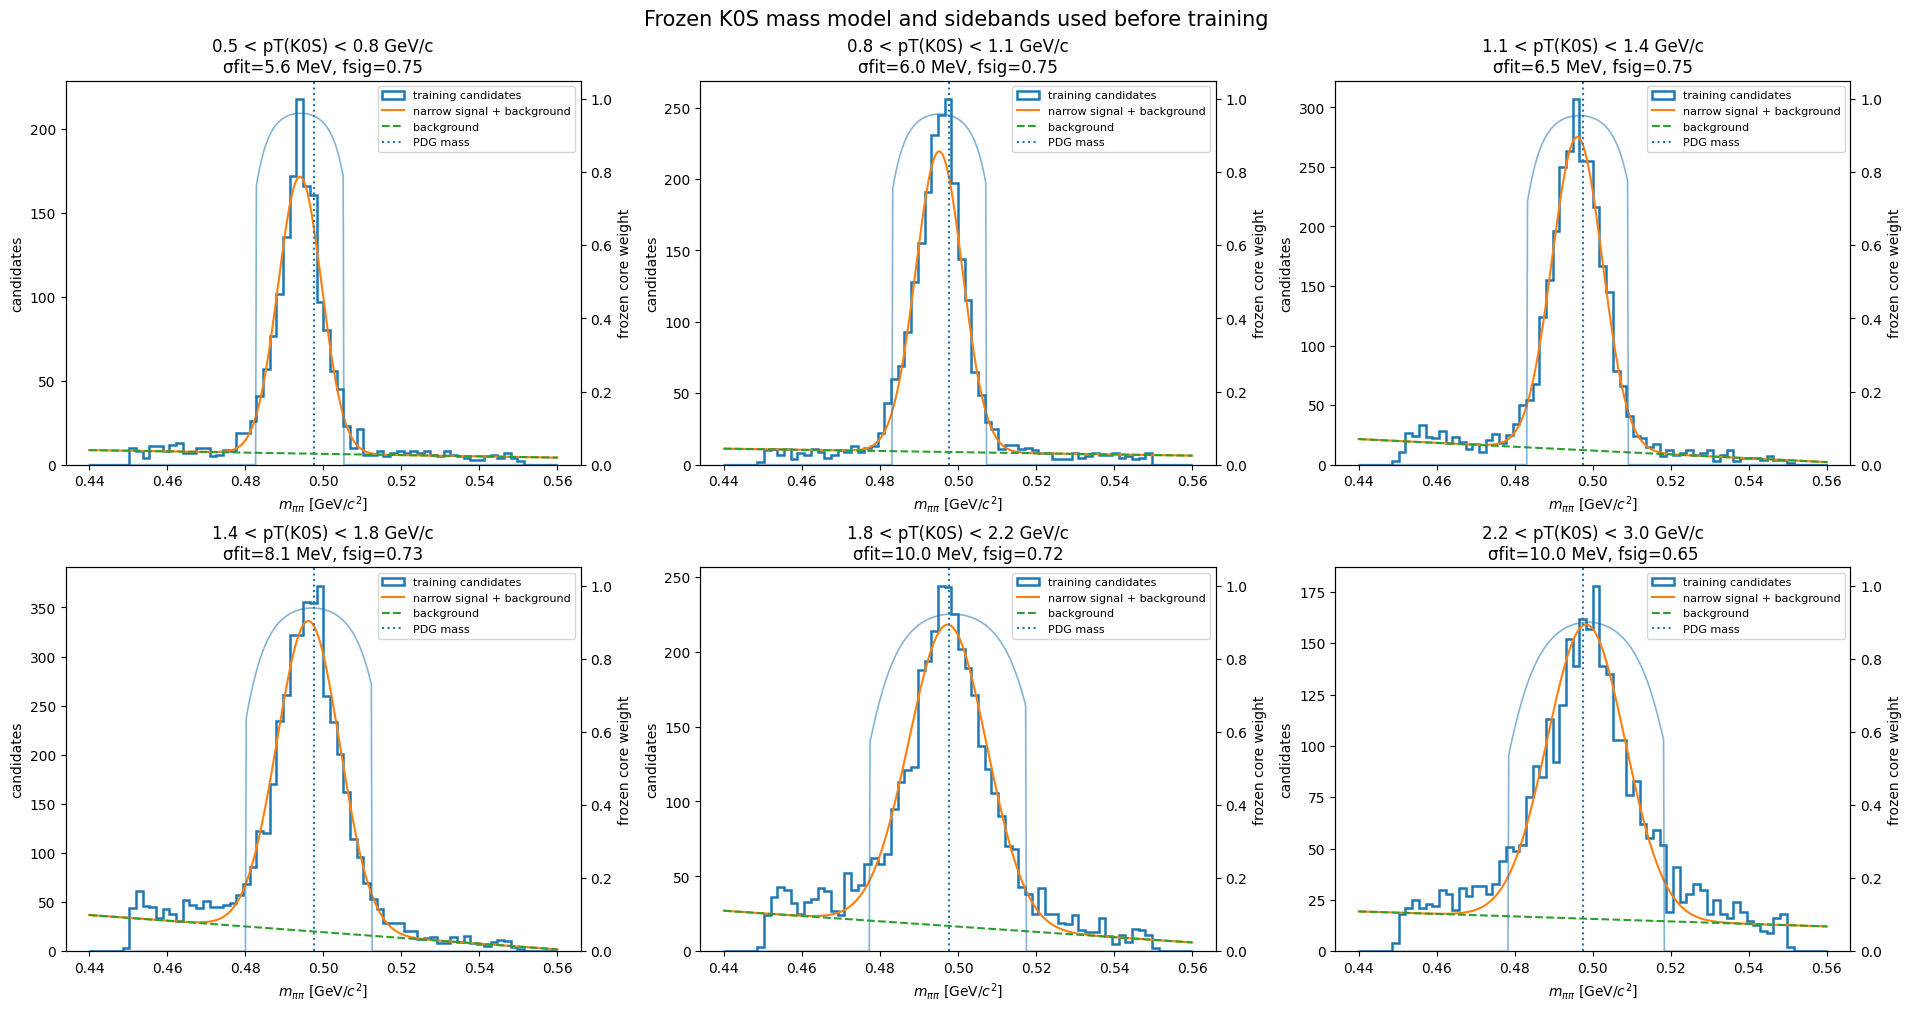

In [5]:
# ============================================================
# Frozen narrow K0S mass model: shared mass + charge gate
# ============================================================
#
# The same frozen baseline-mass core gates BOTH the mass and charge-balance losses.
# Nothing is recomputed from corrected mass, so the network cannot move background
# into the peak to gain charge-balance weight.

from scipy.stats import norm as scipy_norm


def _normalized_linear_background(mass, slope, low=min_k0s_mass, high=max_k0s_mass):
    mass = np.asarray(mass, dtype=np.float64)
    center = 0.5 * (low + high)
    half_width = 0.5 * (high - low)
    u = (mass - center) / max(half_width, 1.0e-12)
    density = np.clip(1.0 + slope * u, 1.0e-8, None)
    return density / (high - low)


def fixed_mass_components(mass_values, model):
    mass_values = np.asarray(mass_values, dtype=np.float64)
    low = model['mass_minimum']
    high = model['mass_maximum']
    signal = scipy_norm.pdf(mass_values, loc=model['mean'], scale=model['sigma'])
    norm_window = scipy_norm.cdf(high, loc=model['mean'], scale=model['sigma']) - scipy_norm.cdf(low, loc=model['mean'], scale=model['sigma'])
    signal = signal / max(norm_window, 1.0e-12)
    background = _normalized_linear_background(mass_values, model['slope'], low, high)
    signal_weighted = model['signal_fraction'] * signal
    background_weighted = (1.0 - model['signal_fraction']) * background
    return signal_weighted, background_weighted


def fit_fixed_k0s_mass_model(mass_values, label='global'):
    mass_values = np.asarray(mass_values, dtype=np.float64)
    mass_values = mass_values[np.isfinite(mass_values) & (mass_values >= min_k0s_mass) & (mass_values <= max_k0s_mass)]

    if mass_values.size < 100:
        raise RuntimeError(f'Not enough K0S candidates to fit mass model {label}: {mass_values.size}')

    def nll(theta):
        fraction, mean, sigma, slope = theta
        model = {
            'signal_fraction': fraction,
            'mean': mean,
            'sigma': sigma,
            'slope': slope,
            'mass_minimum': min_k0s_mass,
            'mass_maximum': max_k0s_mass,
        }
        signal_weighted, background_weighted = fixed_mass_components(mass_values, model)
        return -np.log(np.clip(signal_weighted + background_weighted, 1.0e-15, None)).sum()

    initial = np.array([0.45, pdg_kshort_mass, 0.008, 0.0], dtype=np.float64)
    fit = minimize(
        nll,
        initial,
        method='L-BFGS-B',
        bounds=[
            (k0s_mass_fit_signal_fraction_min, k0s_mass_fit_signal_fraction_max),
            (k0s_mass_fit_mean_min, k0s_mass_fit_mean_max),
            (k0s_mass_fit_sigma_min_gev, k0s_mass_fit_sigma_max_gev),
            (-0.90, 0.90),
        ],
    )

    if not fit.success:
        raise RuntimeError(f'K0S mass fit failed for {label}: {fit.message}')

    fraction, mean, sigma, slope = fit.x
    return {
        'label': label,
        'signal_fraction': float(fraction),
        'mean': float(mean),
        'sigma': float(sigma),
        'slope': float(slope),
        'fit_nll': float(fit.fun),
        'n_candidates': int(mass_values.size),
        'mass_minimum': float(min_k0s_mass),
        'mass_maximum': float(max_k0s_mass),
    }


def fixed_signal_probability(mass_values, model):
    signal_weighted, background_weighted = fixed_mass_components(mass_values, model)
    probability = signal_weighted / np.clip(signal_weighted + background_weighted, 1.0e-15, None)
    return np.clip(probability, minimum_signal_probability_for_physics, 1.0).astype(np.float32)


training_mass_mask = kshort_arrays['event_parity'].astype(np.int64) == training_parity
fixed_mass_models = {'global': fit_fixed_k0s_mass_model(kshort_arrays['baseline_mass'][training_mass_mask], 'global'), 'pt_bins': []}

for lower, upper in zip(pt_mass_scale_bin_edges[:-1], pt_mass_scale_bin_edges[1:]):
    selected = training_mass_mask & (kshort_arrays['pair_pt'] >= lower) & (kshort_arrays['pair_pt'] < upper)
    if np.count_nonzero(selected) >= k0s_mass_model_minimum_candidates_per_pt_bin:
        model = fit_fixed_k0s_mass_model(kshort_arrays['baseline_mass'][selected], f'{lower:.1f}-{upper:.1f}')
    else:
        model = dict(fixed_mass_models['global'])
        model['label'] = f'{lower:.1f}-{upper:.1f} fallback-global'
        model['n_candidates'] = int(np.count_nonzero(selected))
    fixed_mass_models['pt_bins'].append({'pt_low': float(lower), 'pt_high': float(upper), 'model': model})

# Backward-compatible name used in checkpoint metadata later.
fixed_mass_model = fixed_mass_models['global']


def assign_frozen_mass_weights(mass_values, pair_pt):
    mass_values = np.asarray(mass_values, dtype=np.float64)
    pair_pt = np.asarray(pair_pt, dtype=np.float64)
    probability = fixed_signal_probability(mass_values, fixed_mass_models['global'])
    core_weight = np.zeros(len(mass_values), dtype=np.float32)
    model_mean = np.full(len(mass_values), fixed_mass_models['global']['mean'], dtype=np.float32)
    model_sigma = np.full(len(mass_values), fixed_mass_models['global']['sigma'], dtype=np.float32)

    for item in fixed_mass_models['pt_bins']:
        lower = item['pt_low']
        upper = item['pt_high']
        model = item['model']
        selected = (pair_pt >= lower) & (pair_pt < upper)
        if not np.any(selected):
            continue
        probability[selected] = fixed_signal_probability(mass_values[selected], model)
        model_mean[selected] = model['mean']
        model_sigma[selected] = model['sigma']

    core = np.abs(mass_values - model_mean) <= k0s_mass_core_nsigma * model_sigma
    core_weight[core] = probability[core]
    return probability.astype(np.float32), core_weight, model_mean, model_sigma


(
    kshort_arrays['signal_probability'],
    kshort_arrays['mass_core_weight'],
    kshort_arrays['mass_model_mean'],
    kshort_arrays['mass_model_sigma'],
) = assign_frozen_mass_weights(kshort_arrays['baseline_mass'], kshort_arrays['pair_pt'])

# Fail fast before expensive training if the fit still labels sidebands as signal.
train_mass = kshort_arrays['baseline_mass'][training_mass_mask]
train_probability = kshort_arrays['signal_probability'][training_mass_mask]
global_mean = fixed_mass_models['global']['mean']
global_sigma = fixed_mass_models['global']['sigma']
peak_selection = np.abs(train_mass - global_mean) < 1.5 * global_sigma
sideband_selection = np.abs(train_mass - global_mean) > max(3.0 * global_sigma, 0.025)

peak_probability = float(np.mean(train_probability[peak_selection])) if np.any(peak_selection) else np.nan
sideband_probability = float(np.mean(train_probability[sideband_selection])) if np.any(sideband_selection) else np.nan

print('Frozen K0S mass models:')
print(json.dumps(fixed_mass_models, indent=2))
print('Frozen signal probability: min/mean/max =', float(kshort_arrays['signal_probability'].min()), float(kshort_arrays['signal_probability'].mean()), float(kshort_arrays['signal_probability'].max()))
print('Peak mean P(signal) =', peak_probability)
print('Sideband mean P(signal) =', sideband_probability)
print('Mass-core candidates =', int(np.count_nonzero(kshort_arrays['mass_core_weight'] > 0)), '/', len(kshort_arrays['mass_core_weight']))

if np.isfinite(sideband_probability) and sideband_probability > maximum_allowed_sideband_signal_probability:
    raise RuntimeError(f'Unsafe K0S mass model: sideband P(signal)={sideband_probability:.3f} > {maximum_allowed_sideband_signal_probability:.3f}')
if np.isfinite(peak_probability) and np.isfinite(sideband_probability) and peak_probability - sideband_probability < minimum_peak_minus_sideband_probability:
    raise RuntimeError(f'Unsafe K0S mass model: peak-sideband probability separation is only {peak_probability-sideband_probability:.3f}')

# Save a local weighted copy without modifying the prepared source cache.
np.savez_compressed(work_dir / 'kshort_joint_with_frozen_weights.npz', **kshort_arrays)

# QA: raw mass spectrum plus narrow fitted model in every mother-pT bin.
figure, axes = plt.subplots(2, 3, figsize=(19, 10), constrained_layout=True)
axes = axes.ravel()

for axis, item in zip(axes, fixed_mass_models['pt_bins']):
    lower = item['pt_low']
    upper = item['pt_high']
    model = item['model']
    selected = training_mass_mask & (kshort_arrays['pair_pt'] >= lower) & (kshort_arrays['pair_pt'] < upper)
    values = kshort_arrays['baseline_mass'][selected]
    counts, edges, _ = axis.hist(values, bins=70, range=(min_k0s_mass, max_k0s_mass), histtype='step', linewidth=1.8, label='training candidates')
    grid = np.linspace(min_k0s_mass, max_k0s_mass, 600)
    signal_weighted, background_weighted = fixed_mass_components(grid, model)
    bin_width = edges[1] - edges[0]
    normalization = len(values) * bin_width
    axis.plot(grid, normalization * (signal_weighted + background_weighted), label='narrow signal + background')
    axis.plot(grid, normalization * background_weighted, linestyle='--', label='background')
    probability_grid = fixed_signal_probability(grid, model)
    core_grid = np.abs(grid - model['mean']) <= k0s_mass_core_nsigma * model['sigma']
    axis2 = axis.twinx()
    axis2.plot(grid, probability_grid * core_grid, alpha=0.55, linewidth=1.2, label='charge/mass core weight')
    axis2.set_ylim(0.0, 1.05)
    axis2.set_ylabel('frozen core weight')
    axis.axvline(pdg_kshort_mass, linestyle=':', linewidth=1.5, label='PDG mass')
    axis.set_title(f'{lower:.1f} < pT(K0S) < {upper:.1f} GeV/c\nσfit={1000*model["sigma"]:.1f} MeV, fsig={model["signal_fraction"]:.2f}')
    axis.set_xlabel(r'$m_{\pi\pi}$ [GeV/$c^2$]')
    axis.set_ylabel('candidates')
    axis.legend(fontsize=8)

figure.suptitle('Frozen K0S mass model and sidebands used before training', fontsize=15)
plt.show()


## 3. Global transverse circle response

This is the key change.

The response no longer estimates curvature from local tangent differences. Each track uses one robust global algebraic circle fit in \(x-y\). The raw circle radius and raw effective \(|B_z|\) are precomputed once. For each proposed radial map only the corrected circle is refit.

The full-field gradient already stored in the tensor cache is used to update the field at the corrected cluster coordinates. Because step one is radial-only, \(\phi\), \(z\), and the original momentum direction are left unchanged.


In [6]:
# ============================================================
# Global robust circle fit + full-field radial response
# ============================================================

def raw_position_from_cylindrical(r, phi, z):
    return torch.stack([r * torch.cos(phi), r * torch.sin(phi), z], dim=-1)


def corrected_field_from_raw(raw_position, corrected_position, raw_field, raw_gradient):
    if field_evaluation_mode != 'linearized':
        raise ValueError('Step one uses the cached linearized full-field response only.')
    return raw_field + torch.einsum('...ij,...j->...i', raw_gradient, corrected_position - raw_position)


def _circle_solve_xy(x, y, weight):
    weight_sum = torch.clamp(weight.sum(dim=1), min=1.0)
    x_mean = (weight * x).sum(dim=1) / weight_sum
    y_mean = (weight * y).sum(dim=1) / weight_sum

    u = x - x_mean[:, None]
    v = y - y_mean[:, None]
    q = u * u + v * v

    m00 = (weight * u * u).sum(dim=1)
    m01 = (weight * u * v).sum(dim=1)
    m02 = (weight * u).sum(dim=1)
    m11 = (weight * v * v).sum(dim=1)
    m12 = (weight * v).sum(dim=1)
    m22 = weight_sum

    b0 = -(weight * u * q).sum(dim=1)
    b1 = -(weight * v * q).sum(dim=1)
    b2 = -(weight * q).sum(dim=1)

    matrix = torch.stack([
        torch.stack([m00, m01, m02], dim=1),
        torch.stack([m01, m11, m12], dim=1),
        torch.stack([m02, m12, m22], dim=1),
    ], dim=1)
    vector = torch.stack([b0, b1, b2], dim=1)

    diagonal_scale = torch.clamp(torch.diagonal(matrix, dim1=1, dim2=2).mean(dim=1), min=1.0)
    eye = torch.eye(3, dtype=matrix.dtype, device=matrix.device)[None, :, :]
    parameters = torch.linalg.solve(matrix + circle_ridge_fraction * diagonal_scale[:, None, None] * eye, vector)

    d, e, f = parameters[:, 0], parameters[:, 1], parameters[:, 2]
    center_x = x_mean - 0.5 * d
    center_y = y_mean - 0.5 * e
    radius2 = 0.25 * (d * d + e * e) - f
    radius = torch.sqrt(torch.clamp(radius2, min=1.0e-8))

    point_radius = torch.sqrt(torch.clamp((x - center_x[:, None]) ** 2 + (y - center_y[:, None]) ** 2, min=1.0e-10))
    residual = point_radius - radius[:, None]
    return radius, center_x, center_y, residual


def fit_circle_xy(position, mask):
    x, y = position[..., 0], position[..., 1]
    weight = mask

    radius, center_x, center_y, residual = _circle_solve_xy(x, y, weight)

    # One robust reweighting pass suppresses an occasional bad cluster without
    # turning the fit into a slow iterative minimization.
    robust_weight = 1.0 / torch.sqrt(1.0 + (residual / circle_robust_scale_cm) ** 2)
    radius, center_x, center_y, residual = _circle_solve_xy(x, y, weight * robust_weight)

    rms = torch.sqrt(
        torch.sum(weight * residual ** 2, dim=1)
        / torch.clamp(weight.sum(dim=1), min=1.0)
    )

    number_of_points = weight.sum(dim=1)
    valid = (
        (number_of_points >= circle_minimum_points)
        & torch.isfinite(radius)
        & torch.isfinite(rms)
        & (radius >= circle_minimum_radius_cm)
        & (radius <= circle_maximum_radius_cm)
    )
    return radius, rms, valid


def effective_abs_bz(position, field, mask):
    segment = position[:, 1:, :2] - position[:, :-1, :2]
    ds_xy = torch.sqrt(torch.clamp(torch.sum(segment * segment, dim=-1), min=1.0e-10))
    segment_mask = mask[:, 1:] * mask[:, :-1]
    bz_mid = 0.5 * (field[:, 1:, 2] + field[:, :-1, 2])
    weight = segment_mask * ds_xy
    return torch.sum(weight * torch.abs(bz_mid), dim=1) / torch.clamp(weight.sum(dim=1), min=1.0e-8)


def track_field_tensors(batch, suffix):
    field = torch.stack([batch[f'field_bx{suffix}'], batch[f'field_by{suffix}'], batch[f'field_bz{suffix}']], dim=-1)
    gradient = torch.stack([
        batch[f'dbx_dx{suffix}'], batch[f'dbx_dy{suffix}'], batch[f'dbx_dz{suffix}'],
        batch[f'dby_dx{suffix}'], batch[f'dby_dy{suffix}'], batch[f'dby_dz{suffix}'],
        batch[f'dbz_dx{suffix}'], batch[f'dbz_dy{suffix}'], batch[f'dbz_dz{suffix}'],
    ], dim=-1)
    return field, gradient.reshape(*gradient.shape[:-1], 3, 3)


def precompute_raw_circle_quantities(arrays, suffix, batch_size=circle_precompute_batch_size):
    number = len(arrays['candidate_id'])
    radius_out = np.zeros(number, dtype=np.float32)
    bz_out = np.zeros(number, dtype=np.float32)
    rms_out = np.zeros(number, dtype=np.float32)
    valid_out = np.zeros(number, dtype=np.uint8)

    for start in range(0, number, batch_size):
        stop = min(start + batch_size, number)
        r = torch.from_numpy(arrays[f'r{suffix}'][start:stop])
        phi = torch.from_numpy(arrays[f'phi_cluster{suffix}'][start:stop])
        z = torch.from_numpy(arrays[f'z_cluster{suffix}'][start:stop])
        mask = torch.from_numpy(arrays[f'mask{suffix}'][start:stop])

        field = torch.stack([
            torch.from_numpy(arrays[f'field_bx{suffix}'][start:stop]),
            torch.from_numpy(arrays[f'field_by{suffix}'][start:stop]),
            torch.from_numpy(arrays[f'field_bz{suffix}'][start:stop]),
        ], dim=-1)

        position = raw_position_from_cylindrical(r, phi, z)
        with torch.no_grad():
            radius, rms, valid = fit_circle_xy(position, mask)
            bz = effective_abs_bz(position, field, mask)

        radius_out[start:stop] = radius.numpy().astype(np.float32)
        bz_out[start:stop] = bz.numpy().astype(np.float32)
        rms_out[start:stop] = rms.numpy().astype(np.float32)
        valid_out[start:stop] = valid.numpy().astype(np.uint8)

    arrays[f'raw_circle_radius{suffix}'] = radius_out
    arrays[f'raw_effective_abs_bz{suffix}'] = bz_out
    arrays[f'raw_circle_rms{suffix}'] = rms_out
    arrays[f'raw_circle_valid{suffix}'] = valid_out


for suffix in ['1', '2']:
    if f'raw_circle_radius{suffix}' not in kshort_arrays:
        print(f'Precomputing raw circle quantities for daughter {suffix} ...')
        precompute_raw_circle_quantities(kshort_arrays, suffix)

for channel, channel_arrays in validation_arrays.items():
    for suffix in ['1', '2']:
        if f'raw_circle_radius{suffix}' not in channel_arrays:
            print(f'Precomputing raw circle quantities for validation channel {channel}, daughter {suffix} ...')
            precompute_raw_circle_quantities(channel_arrays, suffix)

raw_circle_candidate_valid = kshort_arrays['raw_circle_valid1'].astype(bool) & kshort_arrays['raw_circle_valid2'].astype(bool)
print('Candidates with valid raw global circles:', int(raw_circle_candidate_valid.sum()), '/', len(raw_circle_candidate_valid))


def refit_track_circle(model, r, phi, z, mask, original_pt, original_phi, original_eta, raw_field, raw_gradient, raw_radius, raw_bz, raw_rms, raw_valid):
    raw_position = raw_position_from_cylindrical(r, phi, z)
    delta_r = model(r)

    corrected_r = r - delta_r * mask
    corrected_position = raw_position_from_cylindrical(corrected_r, phi, z)
    corrected_field = corrected_field_from_raw(raw_position, corrected_position, raw_field, raw_gradient)

    corrected_radius, corrected_rms, corrected_valid = fit_circle_xy(corrected_position, mask)
    corrected_bz = effective_abs_bz(corrected_position, corrected_field, mask)

    relative_scale = (corrected_radius * corrected_bz) / torch.clamp(raw_radius * raw_bz, min=1.0e-6)
    valid_scale = raw_valid.to(torch.bool) & corrected_valid & torch.isfinite(relative_scale)
    relative_scale = torch.where(valid_scale, relative_scale, torch.ones_like(relative_scale))
    relative_scale = torch.clamp(relative_scale, min=minimum_refit_scale, max=maximum_refit_scale)

    original_momentum = torch.stack([
        original_pt * torch.cos(original_phi),
        original_pt * torch.sin(original_phi),
        original_pt * torch.sinh(original_eta),
    ], dim=1)
    corrected_momentum = original_momentum * relative_scale[:, None]
    corrected_pt = original_pt * relative_scale

    return {
        'momentum': corrected_momentum,
        'pt': corrected_pt,
        'momentum_scale': relative_scale,
        'circle_valid': valid_scale,
        'raw_circle_radius': raw_radius,
        'corrected_circle_radius': corrected_radius,
        'raw_circle_rms': raw_rms,
        'corrected_circle_rms': corrected_rms,
        'raw_effective_abs_bz': raw_bz,
        'corrected_effective_abs_bz': corrected_bz,
        'delta_r': delta_r,
    }


def invariant_mass(momentum1, momentum2, mass1, mass2):
    energy1 = torch.sqrt(torch.sum(momentum1 ** 2, dim=1) + mass1 ** 2)
    energy2 = torch.sqrt(torch.sum(momentum2 ** 2, dim=1) + mass2 ** 2)
    total = momentum1 + momentum2
    return torch.sqrt(torch.clamp((energy1 + energy2) ** 2 - torch.sum(total ** 2, dim=1), min=0.0))


def correct_batch(model, batch, channel=0):
    field1, gradient1 = track_field_tensors(batch, '1')
    field2, gradient2 = track_field_tensors(batch, '2')

    first = refit_track_circle(
        model, batch['r1'], batch['phi_cluster1'], batch['z_cluster1'], batch['mask1'],
        batch['pt1'], batch['phi1'], batch['eta1'], field1, gradient1,
        batch['raw_circle_radius1'], batch['raw_effective_abs_bz1'], batch['raw_circle_rms1'], batch['raw_circle_valid1'],
    )
    second = refit_track_circle(
        model, batch['r2'], batch['phi_cluster2'], batch['z_cluster2'], batch['mask2'],
        batch['pt2'], batch['phi2'], batch['eta2'], field2, gradient2,
        batch['raw_circle_radius2'], batch['raw_effective_abs_bz2'], batch['raw_circle_rms2'], batch['raw_circle_valid2'],
    )

    if channel == 0:
        mass1 = torch.full_like(batch['charge1'], pion_mass)
        mass2 = torch.full_like(batch['charge2'], pion_mass)
    elif channel == 1:
        mass1 = torch.where(batch['charge1'] > 0, torch.full_like(batch['charge1'], proton_mass), torch.full_like(batch['charge1'], pion_mass))
        mass2 = torch.where(batch['charge2'] > 0, torch.full_like(batch['charge2'], proton_mass), torch.full_like(batch['charge2'], pion_mass))
    else:
        mass1 = torch.where(batch['charge1'] < 0, torch.full_like(batch['charge1'], proton_mass), torch.full_like(batch['charge1'], pion_mass))
        mass2 = torch.where(batch['charge2'] < 0, torch.full_like(batch['charge2'], proton_mass), torch.full_like(batch['charge2'], pion_mass))

    return first, second, invariant_mass(first['momentum'], second['momentum'], mass1, mass2)


Precomputing raw circle quantities for daughter 1 ...
Precomputing raw circle quantities for daughter 2 ...
Precomputing raw circle quantities for validation channel 1, daughter 1 ...
Precomputing raw circle quantities for validation channel 1, daughter 2 ...
Precomputing raw circle quantities for validation channel 2, daughter 1 ...
Precomputing raw circle quantities for validation channel 2, daughter 2 ...
Candidates with valid raw global circles: 41643 / 41643


## 4. Step one radial models and objective

The linear scan has one parameter and directly tests the physical stretch hypothesis.

The refinement remains intentionally tiny: three smooth radial coefficients,

\[
\Delta r(u)=a_1u+a_2u^2+a_3u^3,\qquad
u=\frac{r-54.5}{15.5}.
\]

The center is fixed at zero, so the model cannot use a free global radial offset. Mass-vs-\(p_T\) dominates the loss; width, residuals, map amplitude, smoothness, and endpoint symmetry are guards.


In [7]:
# ============================================================
# Step one models, losses, and evaluation helpers
# ============================================================

class LinearStretchModel(nn.Module):
    def __init__(self, stretch_fraction=0.0):
        super().__init__()
        self.stretch_fraction = nn.Parameter(torch.tensor(float(stretch_fraction), dtype=torch.float32))

    def forward(self, r):
        return -self.stretch_fraction * (r - step1_pivot_r_cm)

    def set_stretch(self, value):
        with torch.no_grad():
            self.stretch_fraction.fill_(float(value))

    def value(self):
        return float(self.stretch_fraction.detach())


class SmoothRadialModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.raw_coefficients = nn.Parameter(torch.zeros(3, dtype=torch.float32))
        self.register_buffer('coefficient_bounds', torch.tensor(step1_coefficient_bounds_cm, dtype=torch.float32))

    def coefficients(self):
        return self.coefficient_bounds * torch.tanh(self.raw_coefficients)

    def forward(self, r):
        u = (r - step1_pivot_r_cm) / step1_radial_scale_cm
        a1, a2, a3 = self.coefficients()
        delta_r = a1 * u + a2 * u ** 2 + a3 * u ** 3
        return torch.clamp(delta_r, -step1_max_abs_delta_r_cm, step1_max_abs_delta_r_cm)

    def initialize_from_stretch(self, stretch_fraction):
        target_a1 = -float(stretch_fraction) * step1_radial_scale_cm
        fraction = np.clip(target_a1 / float(step1_coefficient_bounds_cm[0]), -0.999, 0.999)
        raw = np.arctanh(fraction)
        with torch.no_grad():
            self.raw_coefficients.zero_()
            self.raw_coefficients[0] = float(raw)


def torch_weighted_mean_variance(values, weights):
    weight_sum = torch.clamp(weights.sum(), min=1.0e-8)
    mean = torch.sum(weights * values) / weight_sum
    variance = torch.sum(weights * (values - mean) ** 2) / weight_sum
    neff = weight_sum ** 2 / torch.clamp(torch.sum(weights ** 2), min=1.0e-8)
    return mean, variance, neff


def step1_mass_terms(corrected_mass, batch):
    weights_all = batch['pair_weight'] * batch['mass_core_weight']
    mass_errors = []
    active_weights = []
    width_losses = []
    width_guards = []

    for lower, upper in zip(pt_mass_scale_bin_edges[:-1], pt_mass_scale_bin_edges[1:]):
        selected = (batch['pair_pt'] >= float(lower)) & (batch['pair_pt'] < float(upper))
        weights = weights_all * selected.to(weights_all.dtype)

        corrected_mean, corrected_variance, neff = torch_weighted_mean_variance(corrected_mass, weights)
        _, baseline_variance, _ = torch_weighted_mean_variance(batch['baseline_mass'], weights)

        active = (neff >= pt_mass_scale_minimum_effective_entries).to(corrected_mass.dtype)
        error = (corrected_mean - pdg_kshort_mass) / step1_mass_scale_gev
        width_ratio = torch.sqrt(torch.clamp(corrected_variance / torch.clamp(baseline_variance, min=1.0e-8), min=0.0))

        mass_errors.append(error)
        active_weights.append(active)
        width_losses.append(width_ratio ** 2)
        width_guards.append((torch.relu(width_ratio - step1_max_preferred_width_ratio) / 0.05) ** 2)

    mass_errors = torch.stack(mass_errors)
    active_weights = torch.stack(active_weights)
    width_losses = torch.stack(width_losses)
    width_guards = torch.stack(width_guards)

    normalization = torch.clamp(active_weights.sum(), min=1.0)
    pt_mass = torch.sum(active_weights * mass_errors ** 2) / normalization
    mean_error = torch.sum(active_weights * mass_errors) / normalization
    flatness = torch.sum(active_weights * (mass_errors - mean_error) ** 2) / normalization
    width = torch.sum(active_weights * width_losses) / normalization
    width_guard = torch.sum(active_weights * width_guards) / normalization

    inclusive_mean, _, _ = torch_weighted_mean_variance(corrected_mass, weights_all)
    inclusive_mass = ((inclusive_mean - pdg_kshort_mass) / step1_mass_scale_gev) ** 2

    return pt_mass, flatness, inclusive_mass, width, width_guard


def step1_circle_rms_guard(first, second):
    guards = []
    for track in [first, second]:
        ratio = track['corrected_circle_rms'] / torch.clamp(track['raw_circle_rms'], min=1.0e-6)
        valid = track['circle_valid'].to(ratio.dtype)
        excess = torch.relu(ratio - step1_max_preferred_circle_rms_ratio) / 0.08
        guards.append(torch.sum(valid * excess ** 2) / torch.clamp(valid.sum(), min=1.0))
    return 0.5 * (guards[0] + guards[1])


def step1_map_regularization(model):
    radius = torch.linspace(31.0, 76.0, 181)
    delta = model(radius)

    amplitude = torch.mean((delta / step1_amplitude_scale_cm) ** 2)
    second_difference = delta[2:] - 2.0 * delta[1:-1] + delta[:-2]
    smoothness = torch.mean((second_difference / step1_second_difference_scale_cm) ** 2)

    endpoint = model(torch.tensor([39.0, 70.0]))
    endpoint_symmetry = ((endpoint[0] + endpoint[1]) / step1_endpoint_symmetry_scale_cm) ** 2
    return amplitude, smoothness, endpoint_symmetry


def step1_batch_loss(model, batch):
    first, second, corrected_mass = correct_batch(model, batch, channel=0)
    pt_mass, flatness, inclusive_mass, width, width_guard = step1_mass_terms(corrected_mass, batch)
    circle_rms_guard = step1_circle_rms_guard(first, second)
    amplitude, smoothness, endpoint_symmetry = step1_map_regularization(model)

    total = (
        step1_pt_mass_weight * pt_mass
        + step1_flatness_weight * flatness
        + step1_inclusive_mass_weight * inclusive_mass
        + step1_width_weight * width
        + step1_width_guard_weight * width_guard
        + step1_circle_rms_guard_weight * circle_rms_guard
        + step1_amplitude_regularization_weight * amplitude
        + step1_smoothness_regularization_weight * smoothness
        + step1_endpoint_symmetry_weight * endpoint_symmetry
    )

    terms = {
        'pt_mass': pt_mass,
        'flatness': flatness,
        'inclusive_mass': inclusive_mass,
        'width': width,
        'width_guard': width_guard,
        'circle_rms_guard': circle_rms_guard,
        'amplitude': amplitude,
        'smoothness': smoothness,
        'endpoint_symmetry': endpoint_symmetry,
    }
    return total, terms


def evaluate_step1(model, arrays, indices, channel=0, batch_size=None):
    batch_size = batch_size or step1_validation_batch_size
    loader = DataLoader(CandidateDataset(arrays, indices), batch_size=min(batch_size, len(indices)), shuffle=False, num_workers=0)

    keys = [
        'mass_before', 'mass_after', 'pair_pt', 'pair_weight', 'signal_probability', 'mass_core_weight',
        'pt_positive_before', 'pt_negative_before', 'pt_positive_after', 'pt_negative_after',
        'momentum_scale1', 'momentum_scale2',
        'circle_rms_ratio1', 'circle_rms_ratio2',
        'circle_radius_ratio1', 'circle_radius_ratio2',
        'circle_valid1', 'circle_valid2',
    ]
    collected = {key: [] for key in keys}

    model.eval()
    with torch.no_grad():
        for batch in loader:
            first, second, mass_after = correct_batch(model, batch, channel=channel)

            positive_before = torch.where(batch['charge1'] > 0, batch['pt1'], batch['pt2'])
            negative_before = torch.where(batch['charge1'] < 0, batch['pt1'], batch['pt2'])
            positive_after = torch.where(batch['charge1'] > 0, first['pt'], second['pt'])
            negative_after = torch.where(batch['charge1'] < 0, first['pt'], second['pt'])

            values = {
                'mass_before': batch['baseline_mass'],
                'mass_after': mass_after,
                'pair_pt': batch['pair_pt'],
                'pair_weight': batch['pair_weight'],
                'signal_probability': batch.get('signal_probability', torch.ones_like(batch['pair_weight'])),
                'mass_core_weight': batch.get('mass_core_weight', torch.ones_like(batch['pair_weight'])),
                'pt_positive_before': positive_before,
                'pt_negative_before': negative_before,
                'pt_positive_after': positive_after,
                'pt_negative_after': negative_after,
                'momentum_scale1': first['momentum_scale'],
                'momentum_scale2': second['momentum_scale'],
                'circle_rms_ratio1': first['corrected_circle_rms'] / torch.clamp(first['raw_circle_rms'], min=1.0e-6),
                'circle_rms_ratio2': second['corrected_circle_rms'] / torch.clamp(second['raw_circle_rms'], min=1.0e-6),
                'circle_radius_ratio1': first['corrected_circle_radius'] / torch.clamp(first['raw_circle_radius'], min=1.0e-6),
                'circle_radius_ratio2': second['corrected_circle_radius'] / torch.clamp(second['raw_circle_radius'], min=1.0e-6),
                'circle_valid1': first['circle_valid'].to(torch.float32),
                'circle_valid2': second['circle_valid'].to(torch.float32),
            }
            for key, value in values.items():
                collected[key].append(value.detach().cpu().numpy())

    return {key: np.concatenate(value) for key, value in collected.items()}


def mass_table_from_prediction(prediction):
    weights = prediction['pair_weight'] * prediction['mass_core_weight']
    rows = []

    for lower, upper in zip(pt_mass_scale_bin_edges[:-1], pt_mass_scale_bin_edges[1:]):
        selected = (prediction['pair_pt'] >= lower) & (prediction['pair_pt'] < upper)
        before = peak_metrics(prediction['mass_before'][selected], weights[selected])
        after = peak_metrics(prediction['mass_after'][selected], weights[selected])

        rows.append({
            'pt_low': float(lower),
            'pt_high': float(upper),
            'entries': int(selected.sum()),
            'neff': after['neff'],
            'mean_before': before['mean'],
            'mean_after': after['mean'],
            'mean_error_before_mev': 1000.0 * (before['mean'] - pdg_kshort_mass),
            'mean_error_after_mev': 1000.0 * (after['mean'] - pdg_kshort_mass),
            'width_before_mev': 1000.0 * before['width'],
            'width_after_mev': 1000.0 * after['width'],
            'width_ratio': after['width'] / max(before['width'], 1.0e-12),
        })

    return pd.DataFrame(rows)


def scan_objective(table):
    usable = table['neff'] >= pt_mass_scale_minimum_effective_entries
    if not np.any(usable):
        return np.inf

    error = table.loc[usable, 'mean_error_after_mev'].to_numpy() / (1000.0 * step1_mass_scale_gev)
    width_ratio = table.loc[usable, 'width_ratio'].to_numpy()
    mass_term = np.mean(error ** 2)
    flatness_term = np.var(error)
    width_term = np.mean(width_ratio ** 2)
    width_guard = np.mean(np.maximum(width_ratio - step1_max_preferred_width_ratio, 0.0) ** 2 / 0.05 ** 2)

    return float(
        step1_pt_mass_weight * mass_term
        + step1_flatness_weight * flatness_term
        + step1_width_weight * width_term
        + step1_width_guard_weight * width_guard
    )


def charge_balance_table(positive_pt, negative_pt, weights):
    edges = np.linspace(charge_balance_pt_minimum_gev, charge_balance_pt_maximum_gev, charge_balance_number_of_bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    plus, _ = np.histogram(positive_pt, bins=edges, weights=weights)
    minus, _ = np.histogram(negative_pt, bins=edges, weights=weights)
    plus2, _ = np.histogram(positive_pt, bins=edges, weights=weights ** 2)
    minus2, _ = np.histogram(negative_pt, bins=edges, weights=weights ** 2)

    neff_plus = plus ** 2 / np.maximum(plus2, 1.0e-12)
    neff_minus = minus ** 2 / np.maximum(minus2, 1.0e-12)
    ratio = plus / np.maximum(minus, 1.0e-12)
    sigma_log = np.sqrt(
        1.0 / np.maximum(neff_plus, 1.0)
        + 1.0 / np.maximum(neff_minus, 1.0)
        + charge_balance_systematic_floor_fraction ** 2
    )
    active = (
        (neff_plus >= charge_balance_minimum_bin_effective_entries)
        & (neff_minus >= charge_balance_minimum_bin_effective_entries)
    )

    return pd.DataFrame({
        'pt': centers,
        'ratio': ratio,
        'sigma_ratio': ratio * sigma_log,
        'active': active,
        'neff_plus': neff_plus,
        'neff_minus': neff_minus,
    })


In [8]:
# ============================================================
# Train / validation split and zero-map identity check
# ============================================================

raw_valid = kshort_arrays['raw_circle_valid1'].astype(bool) & kshort_arrays['raw_circle_valid2'].astype(bool)

training_indices = np.flatnonzero((kshort_arrays['event_parity'].astype(np.int64) == training_parity) & raw_valid)
validation_indices = np.flatnonzero((kshort_arrays['event_parity'].astype(np.int64) == validation_parity) & raw_valid)

scan_indices = stratified_indices_by_pt(
    training_indices, kshort_arrays['pair_pt'], pt_mass_scale_bin_edges,
    step1_scan_candidates_per_pt_bin, seed + 1100,
)
fit_indices = stratified_indices_by_pt(
    training_indices, kshort_arrays['pair_pt'], pt_mass_scale_bin_edges,
    step1_fit_candidates_per_pt_bin, seed + 1200,
)
validation_fit_indices = stratified_indices_by_pt(
    validation_indices, kshort_arrays['pair_pt'], pt_mass_scale_bin_edges,
    step1_validation_candidates_per_pt_bin, seed + 1300,
)

print('All training candidates:', len(training_indices))
print('All held-out candidates:', len(validation_indices))
print('Stratified scan candidates:', len(scan_indices))
print('Stratified fit candidates:', len(fit_indices))
print('Stratified early-validation candidates:', len(validation_fit_indices))
print('\nAll held-out candidates by pT bin:')
display(pt_bin_counts(validation_indices, kshort_arrays['pair_pt'], pt_mass_scale_bin_edges))
print('Scan candidates by pT bin:')
display(pt_bin_counts(scan_indices, kshort_arrays['pair_pt'], pt_mass_scale_bin_edges))

zero_model = LinearStretchModel(0.0)
zero_indices = validation_fit_indices[: min(2000, len(validation_fit_indices))]
zero_prediction = evaluate_step1(zero_model, kshort_arrays, zero_indices)
zero_mass_difference = np.max(np.abs(zero_prediction['mass_after'] - zero_prediction['mass_before']))
zero_scale_difference = max(
    np.max(np.abs(zero_prediction['momentum_scale1'] - 1.0)),
    np.max(np.abs(zero_prediction['momentum_scale2'] - 1.0)),
)

print('Zero-map maximum |mass_after-mass_before|:', zero_mass_difference)
print('Zero-map maximum |momentum_scale-1|:', zero_scale_difference)
if zero_mass_difference > 2.0e-5 or zero_scale_difference > 2.0e-5:
    raise RuntimeError('Global circle response fails the zero-map identity check.')


All training candidates: 20767
All held-out candidates: 20876
Stratified scan candidates: 4200
Stratified fit candidates: 7200
Stratified early-validation candidates: 4800

All held-out candidates by pT bin:


,pt_low,pt_high,candidates
0,0.5,0.8,1863
1,0.8,1.1,2527
2,1.1,1.4,3244
3,1.4,1.8,5140
4,1.8,2.2,4199
5,2.2,3.0,3138


Scan candidates by pT bin:


,pt_low,pt_high,candidates
0,0.5,0.8,700
1,0.8,1.1,700
2,1.1,1.4,700
3,1.4,1.8,700
4,1.8,2.2,700
5,2.2,3.0,700


Zero-map maximum |mass_after-mass_before|: 4.4107437e-06
Zero-map maximum |momentum_scale-1|: 0.0


## 5. Step one A — fast linear stretch scan

This scan is deliberately done before any multi-parameter fit. The important diagnostic is not only the best scalar objective: inspect the **mass-vs-\(p_T\) curves for several stretch values**.

If the radial hypothesis is relevant, the curves should rotate/flatten as the stretch changes rather than simply translate vertically.


scan s=-10.00% Dr(39)=-1.550 cm Dr(70)=+1.550 cm objective=1864.208
scan s=-9.50% Dr(39)=-1.472 cm Dr(70)=+1.472 cm objective=1695.879
scan s=-9.00% Dr(39)=-1.395 cm Dr(70)=+1.395 cm objective=1534.630
scan s=-8.50% Dr(39)=-1.318 cm Dr(70)=+1.318 cm objective=1380.771
scan s=-8.00% Dr(39)=-1.240 cm Dr(70)=+1.240 cm objective=1234.312
scan s=-7.50% Dr(39)=-1.163 cm Dr(70)=+1.163 cm objective=1095.442
scan s=-7.00% Dr(39)=-1.085 cm Dr(70)=+1.085 cm objective=964.244
scan s=-6.50% Dr(39)=-1.008 cm Dr(70)=+1.008 cm objective=840.929
scan s=-6.00% Dr(39)=-0.930 cm Dr(70)=+0.930 cm objective=725.584
scan s=-5.50% Dr(39)=-0.853 cm Dr(70)=+0.853 cm objective=618.286
scan s=-5.00% Dr(39)=-0.775 cm Dr(70)=+0.775 cm objective=519.212
scan s=-4.50% Dr(39)=-0.698 cm Dr(70)=+0.698 cm objective=428.476
scan s=-4.00% Dr(39)=-0.620 cm Dr(70)=+0.620 cm objective=346.153
scan s=-3.50% Dr(39)=-0.543 cm Dr(70)=+0.543 cm objective=272.354
scan s=-3.00% Dr(39)=-0.465 cm Dr(70)=+0.465 cm objective=207.227
sca

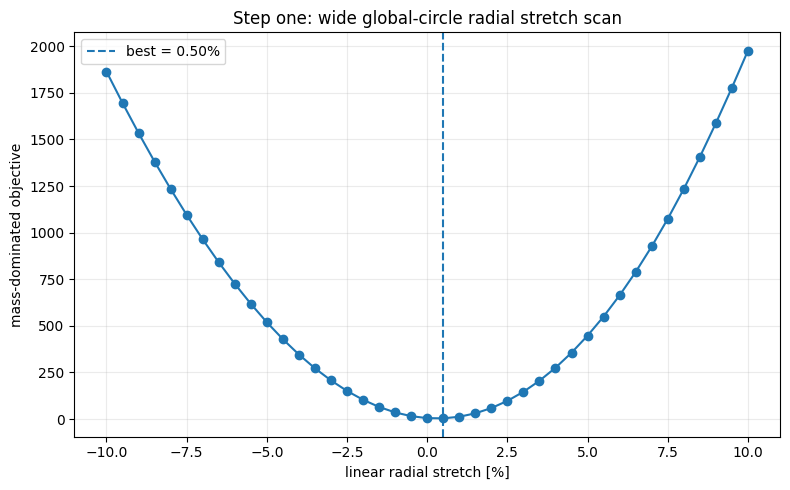

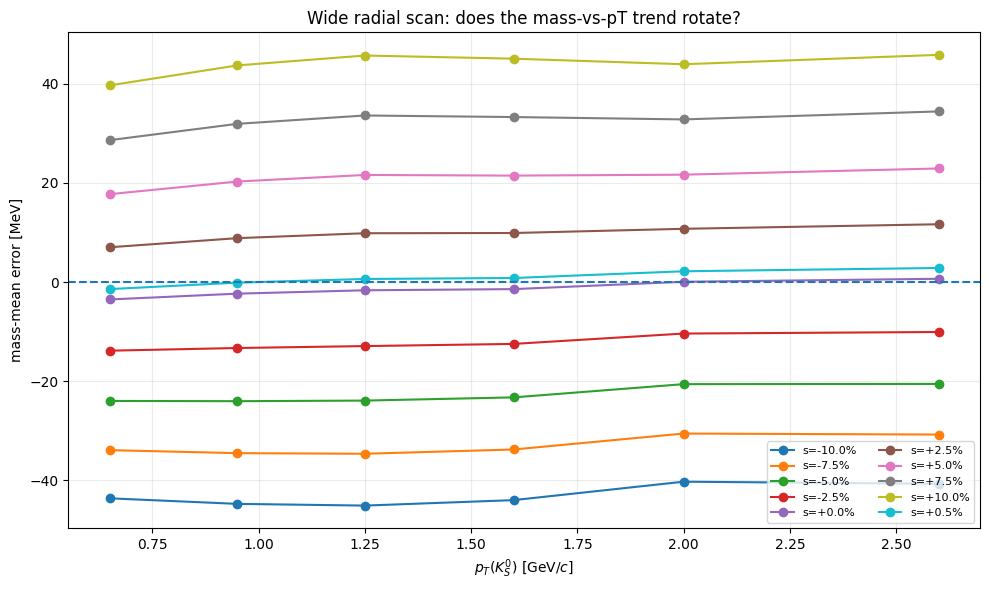

,stretch_fraction,delta_r_39_cm,delta_r_70_cm,objective,mean_abs_mass_error_mev,maximum_width_ratio
0,-0.100,-1.5500,1.5500,1864.207889,43.042828,1.759948
1,-0.095,-1.4725,1.4725,1695.878619,41.056244,1.703422
2,-0.090,-1.3950,1.3950,1534.629876,39.057777,1.646655
3,-0.085,-1.3175,1.3175,1380.771322,37.049777,1.589807
4,-0.080,-1.2400,1.2400,1234.312243,35.030644,1.533030
5,-0.075,-1.1625,1.1625,1095.442128,33.001387,1.475298
6,-0.070,-1.0850,1.0850,964.244256,30.961022,1.418018
7,-0.065,-1.0075,1.0075,840.928983,28.911063,1.362043
8,-0.060,-0.9300,0.9300,725.583751,26.851085,1.307378
9,-0.055,-0.8525,0.8525,618.286068,24.780100,1.254640


Best linear stretch used to initialize the smooth map: +0.500%
Corresponding endpoint map: Dr(39)=+0.077 cm, Dr(70)=-0.077 cm


In [9]:
# ============================================================
# Step one A: wide one-parameter radial stretch scan
# ============================================================

linear_model = LinearStretchModel(0.0)
scan_rows = []
scan_mass_rows = []

if run_step_one_linear_scan:
    scan_values = np.linspace(step1_scan_min_fraction, step1_scan_max_fraction, step1_scan_points)

    for stretch in scan_values:
        linear_model.set_stretch(stretch)
        prediction = evaluate_step1(linear_model, kshort_arrays, scan_indices)
        table = mass_table_from_prediction(prediction)

        scan_rows.append({
            'stretch_fraction': float(stretch),
            'delta_r_39_cm': float(-stretch * (39.0 - step1_pivot_r_cm)),
            'delta_r_70_cm': float(-stretch * (70.0 - step1_pivot_r_cm)),
            'objective': scan_objective(table),
            'mean_abs_mass_error_mev': float(np.nanmean(np.abs(table['mean_error_after_mev']))),
            'maximum_width_ratio': float(np.nanmax(table['width_ratio'])),
        })

        table = table.copy()
        table['stretch_fraction'] = float(stretch)
        scan_mass_rows.append(table)
        print(
            f'scan s={100*stretch:+.2f}% '
            f'Dr(39)={scan_rows[-1]["delta_r_39_cm"]:+.3f} cm '
            f'Dr(70)={scan_rows[-1]["delta_r_70_cm"]:+.3f} cm '
            f'objective={scan_rows[-1]["objective"]:.3f}'
        )

    step1_scan_table = pd.DataFrame(scan_rows)
    step1_scan_mass_table = pd.concat(scan_mass_rows, ignore_index=True)
    best_scan = step1_scan_table.loc[step1_scan_table['objective'].idxmin()]
    best_linear_stretch = float(best_scan['stretch_fraction'])

    step1_scan_table.to_csv(work_dir / 'step1_linear_scan.csv', index=False)
    step1_scan_mass_table.to_csv(work_dir / 'step1_linear_scan_mass_vs_pt.csv', index=False)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(100.0 * step1_scan_table['stretch_fraction'], step1_scan_table['objective'], marker='o')
    ax.axvline(100.0 * best_linear_stretch, linestyle='--', label=f'best = {100*best_linear_stretch:.2f}%')
    ax.set_xlabel('linear radial stretch [%]')
    ax.set_ylabel('mass-dominated objective')
    ax.set_title('Step one: wide global-circle radial stretch scan')
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.savefig(work_dir / 'step1_linear_scan.pdf')
    plt.show()

    # Directly inspect whether the pT trend rotates. Show a coarse ladder of
    # cm-scale stretches plus the numerical best point.
    pt_center = 0.5 * (pt_mass_scale_bin_edges[:-1] + pt_mass_scale_bin_edges[1:])
    requested_percent = [-10.0, -7.5, -5.0, -2.5, 0.0, 2.5, 5.0, 7.5, 10.0, 100.0 * best_linear_stretch]
    interesting = []
    for percent in requested_percent:
        nearest = float(scan_values[np.argmin(np.abs(100.0 * scan_values - percent))])
        if not any(np.isclose(nearest, x) for x in interesting):
            interesting.append(nearest)

    fig, ax = plt.subplots(figsize=(10, 6))
    for stretch in interesting:
        frame = step1_scan_mass_table[np.isclose(step1_scan_mass_table['stretch_fraction'], stretch)]
        ax.plot(pt_center, frame['mean_error_after_mev'], marker='o', label=f's={100*stretch:+.1f}%')

    ax.axhline(0.0, linestyle='--')
    ax.set_xlabel(r'$p_T(K_S^0)$ [GeV/$c$]')
    ax.set_ylabel('mass-mean error [MeV]')
    ax.set_title('Wide radial scan: does the mass-vs-pT trend rotate?')
    ax.grid(alpha=0.25)
    ax.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    plt.savefig(work_dir / 'step1_scan_mass_trends.pdf')
    plt.show()

    display(step1_scan_table)
else:
    best_linear_stretch = 0.0

print('Best linear stretch used to initialize the smooth map:', f'{100*best_linear_stretch:+.3f}%')
print('Corresponding endpoint map:',
      f'Dr(39)={-best_linear_stretch*(39.0-step1_pivot_r_cm):+.3f} cm,',
      f'Dr(70)={-best_linear_stretch*(70.0-step1_pivot_r_cm):+.3f} cm')


## 6. Step one B — smooth three-parameter radial refinement

The scan result initializes only the linear coefficient. PyTorch then allows a small quadratic/cubic deformation while keeping the map radial-only and pinned to zero at 54.5 cm.

This is still a tiny calibration model, not a generic DNN.


epoch 00: validation=3.224 a=[-0.053, +0.020, +0.020] cm
epoch 02: validation=2.216 a=[-0.068, -0.003, +0.015] cm
epoch 04: validation=2.505 a=[-0.075, -0.023, +0.018] cm
epoch 06: validation=1.590 a=[-0.061, -0.029, +0.037] cm
epoch 08: validation=1.491 a=[-0.052, -0.039, +0.053] cm
epoch 10: validation=1.065 a=[-0.056, -0.058, +0.060] cm
epoch 12: validation=1.067 a=[-0.061, -0.079, +0.066] cm
epoch 14: validation=0.774 a=[-0.056, -0.092, +0.079] cm
epoch 16: validation=0.523 a=[-0.047, -0.102, +0.095] cm
epoch 18: validation=0.465 a=[-0.043, -0.115, +0.107] cm
epoch 19: validation=0.410 a=[-0.044, -0.123, +0.111] cm


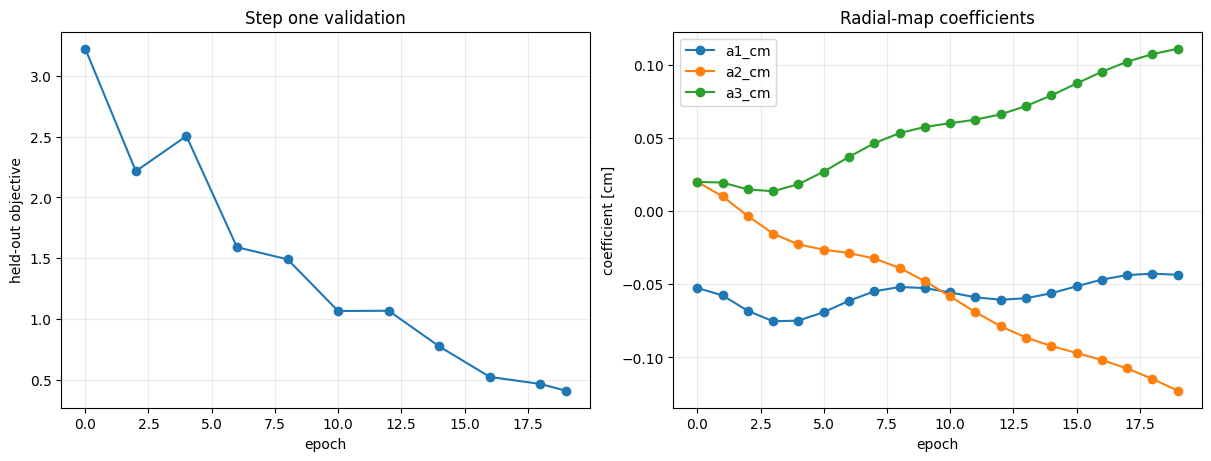

Best epoch: 19
Final coefficients [cm]: [-0.04352195 -0.12273978  0.11104864]
Final Delta r at [39, 54.5, 70] cm: [-0.19026648  0.         -0.05521309] cm


In [10]:
# ============================================================
# Step one B: smooth radial refinement
# ============================================================

step1_model = SmoothRadialModel()
step1_model.initialize_from_stretch(best_linear_stretch)

history = []
best_validation_score = np.inf
best_state = copy.deepcopy(step1_model.state_dict())
best_epoch = -1
stale_checks = 0

# One pT-balanced full batch gives the optimizer the actual mass trend in every
# update. With only three trainable parameters this is cleaner than noisy
# mini-batches whose low-pT bins may be empty.
fit_dataset = CandidateDataset(kshort_arrays, fit_indices)
fit_loader = DataLoader(fit_dataset, batch_size=len(fit_dataset), shuffle=False, num_workers=0)
fit_batch = next(iter(fit_loader))

if run_step_one_radial_fit:
    optimizer = torch.optim.Adam(step1_model.parameters(), lr=step1_learning_rate)

    for epoch in range(step1_fit_epochs):
        step1_model.train()
        optimizer.zero_grad(set_to_none=True)
        total, terms = step1_batch_loss(step1_model, fit_batch)
        total.backward()
        optimizer.step()

        do_validation = (epoch % step1_validation_interval == 0) or (epoch == step1_fit_epochs - 1)
        coefficients = step1_model.coefficients().detach().cpu().numpy()
        row = {'epoch': epoch, 'training_total': float(total.detach())}
        row.update({key: float(value.detach()) for key, value in terms.items()})
        row.update({f'a{i+1}_cm': float(coefficients[i]) for i in range(3)})

        if do_validation:
            validation_prediction = evaluate_step1(step1_model, kshort_arrays, validation_fit_indices)
            validation_table = mass_table_from_prediction(validation_prediction)
            validation_score = scan_objective(validation_table)
            row['validation_score'] = validation_score

            print(
                f'epoch {epoch:02d}: validation={validation_score:.3f} '
                f'a=[{coefficients[0]:+.3f}, {coefficients[1]:+.3f}, {coefficients[2]:+.3f}] cm'
            )

            if validation_score < best_validation_score - step1_minimum_improvement:
                best_validation_score = validation_score
                best_state = copy.deepcopy(step1_model.state_dict())
                best_epoch = epoch
                stale_checks = 0
            else:
                stale_checks += 1
                if stale_checks >= step1_patience:
                    history.append(row)
                    print('Early stop: held-out mass objective stopped improving.')
                    break
        else:
            row['validation_score'] = np.nan

        history.append(row)

    step1_model.load_state_dict(best_state)

step1_history = pd.DataFrame(history)
if not step1_history.empty:
    step1_history.to_csv(work_dir / 'step1_training_history.csv', index=False)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
    valid_history = step1_history[np.isfinite(step1_history['validation_score'])]
    axes[0].plot(valid_history['epoch'], valid_history['validation_score'], marker='o')
    axes[0].set_xlabel('epoch')
    axes[0].set_ylabel('held-out objective')
    axes[0].set_title('Step one validation')
    axes[0].grid(alpha=0.25)

    for name in ['a1_cm', 'a2_cm', 'a3_cm']:
        axes[1].plot(step1_history['epoch'], step1_history[name], marker='o', label=name)
    axes[1].set_xlabel('epoch')
    axes[1].set_ylabel('coefficient [cm]')
    axes[1].set_title('Radial-map coefficients')
    axes[1].grid(alpha=0.25)
    axes[1].legend()
    plt.show()

coefficients = step1_model.coefficients().detach().cpu().numpy()
print('Best epoch:', best_epoch)
print('Final coefficients [cm]:', coefficients)
with torch.no_grad():
    endpoint_map = step1_model(torch.tensor([39.0, 54.5, 70.0])).numpy()
print('Final Delta r at [39, 54.5, 70] cm:', endpoint_map, 'cm')


## 7. Held-out Step one QA

Final QA uses **all** held-out candidates, not the stratified optimization subset.

,pt_low,pt_high,entries,neff,mean_before,mean_after,mean_error_before_mev,mean_error_after_mev,width_before_mev,width_after_mev,width_ratio
0,0.5,0.8,1863,1469.024650,0.494213,0.496882,-3.397851,-0.729475,4.772690,5.142929,1.077575
1,0.8,1.1,2527,2026.508144,0.495487,0.497233,-2.124401,-0.378026,5.190659,6.026671,1.161061
2,1.1,1.4,3244,2501.473364,0.496174,0.497375,-1.436974,-0.236435,5.581441,6.569524,1.177030
3,1.4,1.8,5140,3901.665566,0.496212,0.497240,-1.398696,-0.371136,6.886876,7.834624,1.137617
4,1.8,2.2,4199,3155.119679,0.497102,0.497853,-0.508709,0.241644,8.673571,9.588904,1.105531
5,2.2,3.0,3138,2265.513568,0.498172,0.498257,0.560950,0.646116,9.221663,10.199274,1.106012


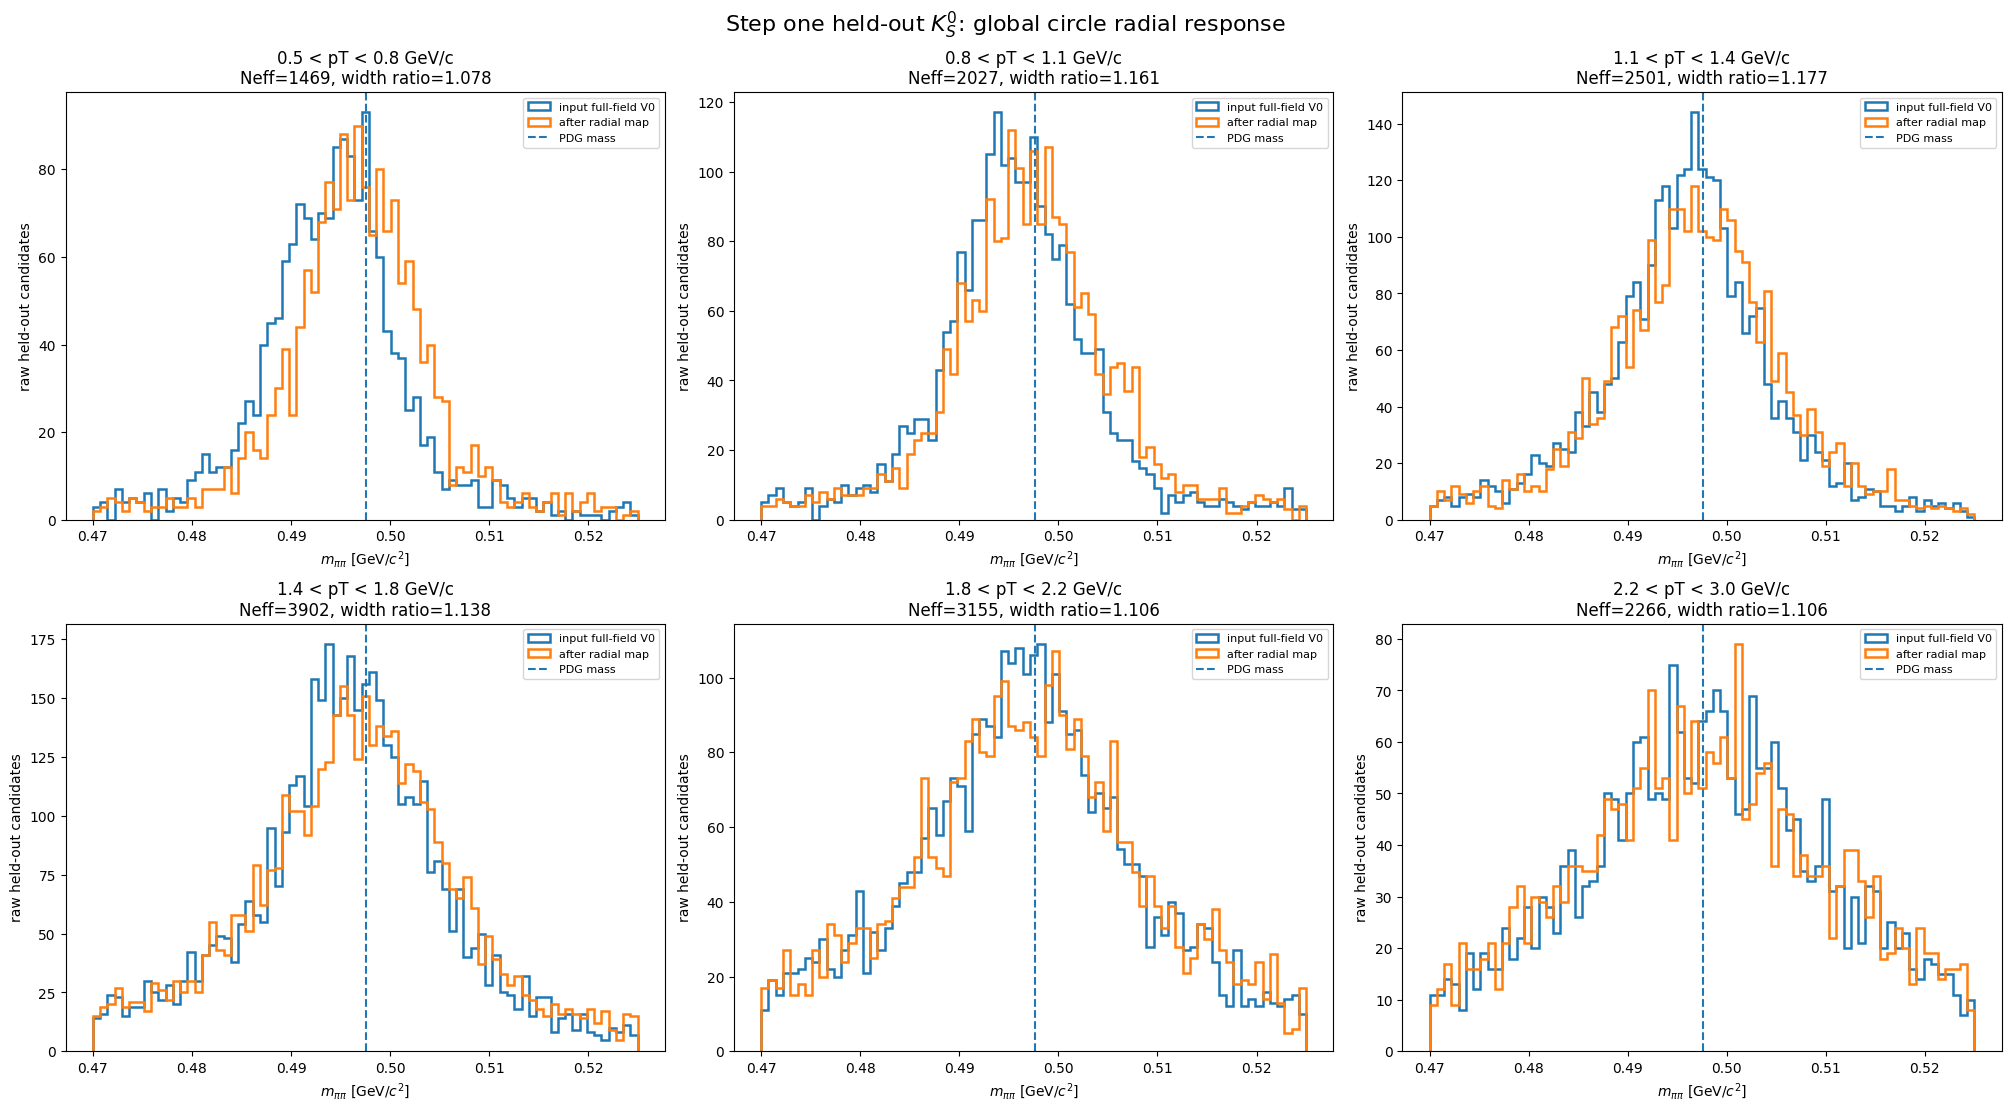

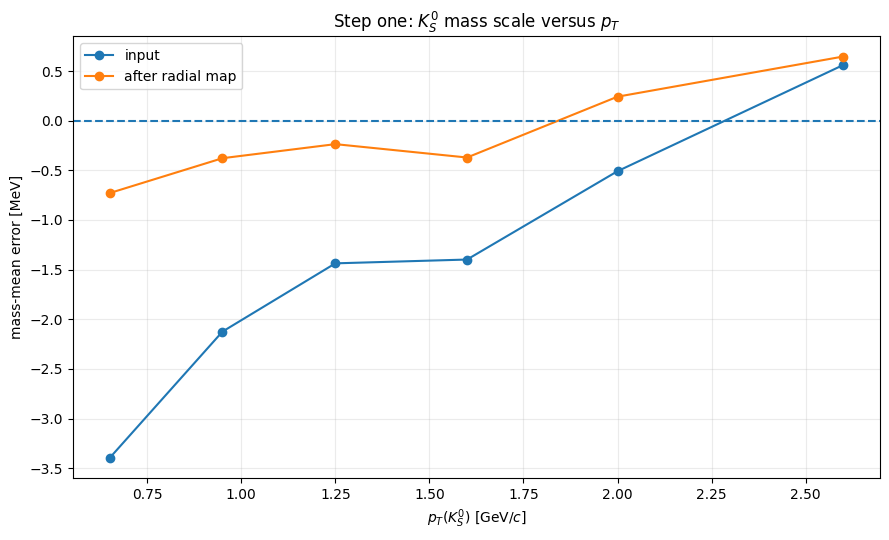

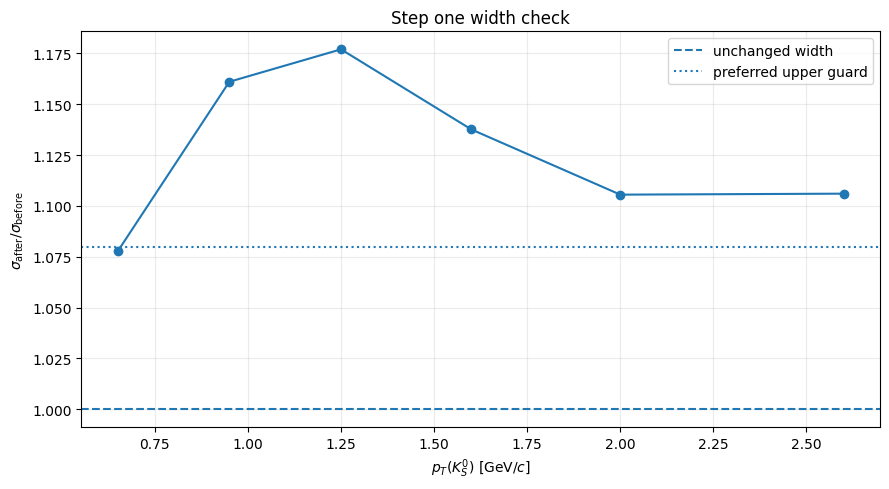

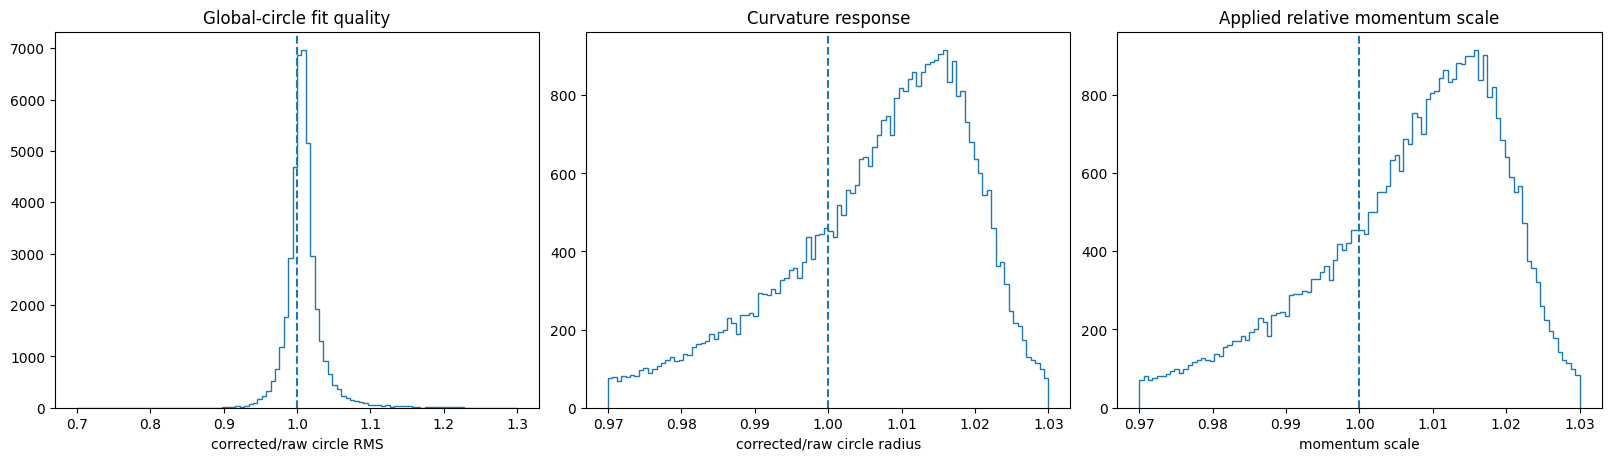

Median circle-RMS ratio: 1.0069677829742432
Median circle-radius ratio: 1.0088680982589722
Median momentum scale: 1.0089157819747925


In [11]:
# ============================================================
# Held-out mass / width / circle QA
# ============================================================

step1_validation = evaluate_step1(step1_model, kshort_arrays, validation_indices)
step1_mass_table = mass_table_from_prediction(step1_validation)
step1_mass_table.to_csv(work_dir / 'step1_kshort_mass_vs_pt.csv', index=False)
display(step1_mass_table)

# Raw K0S shapes.
figure, axes = plt.subplots(2, 3, figsize=(20, 11), constrained_layout=True)
axes = axes.ravel()

for axis, row in zip(axes, step1_mass_table.itertuples(index=False)):
    selected = (step1_validation['pair_pt'] >= row.pt_low) & (step1_validation['pair_pt'] < row.pt_high)
    axis.hist(step1_validation['mass_before'][selected], bins=75, range=(0.47, 0.525), histtype='step', linewidth=1.8, label='input full-field V0')
    axis.hist(step1_validation['mass_after'][selected], bins=75, range=(0.47, 0.525), histtype='step', linewidth=1.8, label='after radial map')
    axis.axvline(pdg_kshort_mass, linestyle='--', linewidth=1.5, label='PDG mass')
    axis.set_title(f'{row.pt_low:.1f} < pT < {row.pt_high:.1f} GeV/c\nNeff={row.neff:.0f}, width ratio={row.width_ratio:.3f}')
    axis.set_xlabel(r'$m_{\pi\pi}$ [GeV/$c^2$]')
    axis.set_ylabel('raw held-out candidates')
    axis.legend(fontsize=8)

figure.suptitle(r'Step one held-out $K_S^0$: global circle radial response', fontsize=16)
plt.savefig(work_dir / 'step1_kshort_mass_shapes.pdf')
plt.show()

pt_center = 0.5 * (step1_mass_table['pt_low'].to_numpy() + step1_mass_table['pt_high'].to_numpy())

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(pt_center, step1_mass_table['mean_error_before_mev'], marker='o', label='input')
ax.plot(pt_center, step1_mass_table['mean_error_after_mev'], marker='o', label='after radial map')
ax.axhline(0.0, linestyle='--')
ax.set_xlabel(r'$p_T(K_S^0)$ [GeV/$c$]')
ax.set_ylabel('mass-mean error [MeV]')
ax.set_title(r'Step one: $K_S^0$ mass scale versus $p_T$')
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.savefig(work_dir / 'step1_mass_scale_vs_pt.pdf')
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(pt_center, step1_mass_table['width_ratio'], marker='o')
ax.axhline(1.0, linestyle='--', label='unchanged width')
ax.axhline(step1_max_preferred_width_ratio, linestyle=':', label='preferred upper guard')
ax.set_xlabel(r'$p_T(K_S^0)$ [GeV/$c$]')
ax.set_ylabel(r'$\sigma_{\rm after}/\sigma_{\rm before}$')
ax.set_title('Step one width check')
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.savefig(work_dir / 'step1_width_ratio_vs_pt.pdf')
plt.show()

# Circle-fit diagnostics.
circle_rms_ratio = np.concatenate([step1_validation['circle_rms_ratio1'], step1_validation['circle_rms_ratio2']])
circle_radius_ratio = np.concatenate([step1_validation['circle_radius_ratio1'], step1_validation['circle_radius_ratio2']])
momentum_scale = np.concatenate([step1_validation['momentum_scale1'], step1_validation['momentum_scale2']])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
axes[0].hist(circle_rms_ratio[np.isfinite(circle_rms_ratio)], bins=100, range=(0.7, 1.3), histtype='step')
axes[0].axvline(1.0, linestyle='--')
axes[0].set_xlabel('corrected/raw circle RMS')
axes[0].set_title('Global-circle fit quality')

axes[1].hist(circle_radius_ratio[np.isfinite(circle_radius_ratio)], bins=100, range=(0.97, 1.03), histtype='step')
axes[1].axvline(1.0, linestyle='--')
axes[1].set_xlabel('corrected/raw circle radius')
axes[1].set_title('Curvature response')

axes[2].hist(momentum_scale[np.isfinite(momentum_scale)], bins=100, range=(0.97, 1.03), histtype='step')
axes[2].axvline(1.0, linestyle='--')
axes[2].set_xlabel('momentum scale')
axes[2].set_title('Applied relative momentum scale')

plt.savefig(work_dir / 'step1_circle_response_qa.pdf')
plt.show()

print('Median circle-RMS ratio:', float(np.nanmedian(circle_rms_ratio)))
print('Median circle-radius ratio:', float(np.nanmedian(circle_radius_ratio)))
print('Median momentum scale:', float(np.nanmedian(momentum_scale)))


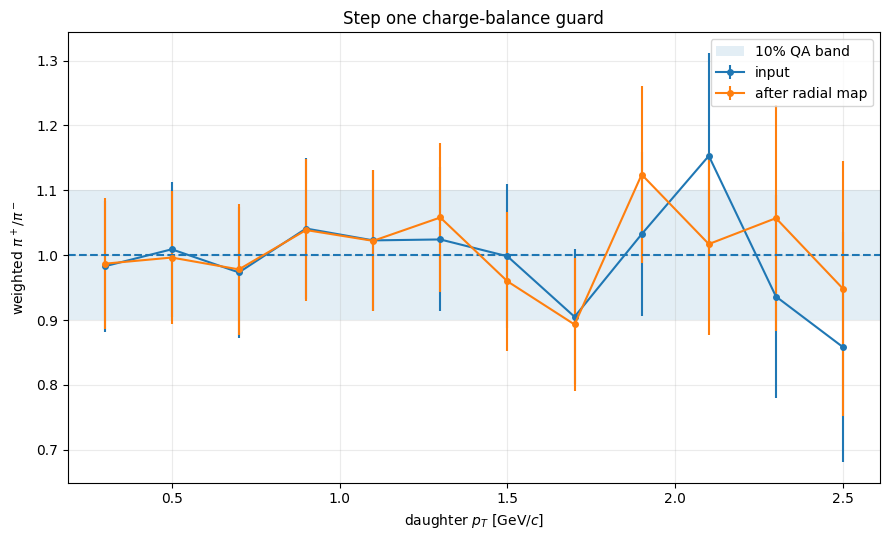

,daughter,tracks,median_corrected_over_raw_rms,p90_corrected_over_raw_rms,p99_corrected_over_raw_rms
0,1,20876,1.006759,1.035969,1.113291
1,2,20876,1.007142,1.031527,1.093042


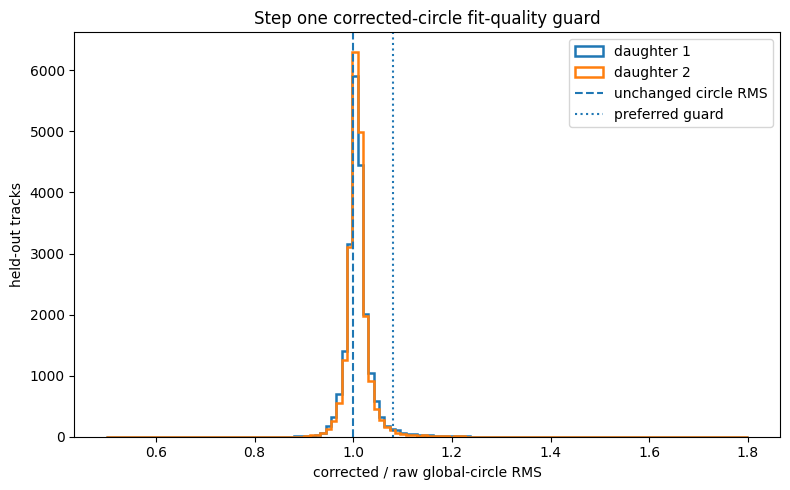

In [12]:
# ============================================================
# Charge balance and corrected-circle fit-quality guard
# ============================================================

charge_weight = step1_validation['pair_weight'] * step1_validation['signal_probability']
charge_before = charge_balance_table(step1_validation['pt_positive_before'], step1_validation['pt_negative_before'], charge_weight)
charge_after = charge_balance_table(step1_validation['pt_positive_after'], step1_validation['pt_negative_after'], charge_weight)
charge_before['state'] = 'before'
charge_after['state'] = 'after'
pd.concat([charge_before, charge_after], ignore_index=True).to_csv(work_dir / 'step1_charge_balance.csv', index=False)

fig, ax = plt.subplots(figsize=(9, 5.5))
for table, label in [(charge_before, 'input'), (charge_after, 'after radial map')]:
    selected = table['active'].to_numpy(bool)
    ax.errorbar(table.loc[selected, 'pt'], table.loc[selected, 'ratio'], yerr=table.loc[selected, 'sigma_ratio'], fmt='o-', ms=4, label=label)

ax.axhline(1.0, linestyle='--')
ax.axhspan(0.90, 1.10, alpha=0.12, label='10% QA band')
ax.set_xlabel(r'daughter $p_T$ [GeV/$c$]')
ax.set_ylabel(r'weighted $\pi^+/\pi^-$')
ax.set_title('Step one charge-balance guard')
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.savefig(work_dir / 'step1_charge_balance.pdf')
plt.show()

# A coherent detector distortion can be cm-scale while the refitted track
# residual remains small. Therefore do NOT subtract Delta r from the old local
# residuals. The meaningful guard is whether the corrected clusters still lie
# on a good newly fitted global circle.
circle_rows = []
for daughter in [1, 2]:
    ratio = step1_validation[f'circle_rms_ratio{daughter}']
    valid = np.isfinite(ratio)
    circle_rows.append({
        'daughter': daughter,
        'tracks': int(valid.sum()),
        'median_corrected_over_raw_rms': float(np.nanmedian(ratio[valid])),
        'p90_corrected_over_raw_rms': float(np.nanpercentile(ratio[valid], 90)),
        'p99_corrected_over_raw_rms': float(np.nanpercentile(ratio[valid], 99)),
    })

step1_circle_fit_guard = pd.DataFrame(circle_rows)
step1_circle_fit_guard.to_csv(work_dir / 'step1_circle_fit_guard.csv', index=False)
display(step1_circle_fit_guard)

fig, ax = plt.subplots(figsize=(8, 5))
for daughter in [1, 2]:
    ratio = step1_validation[f'circle_rms_ratio{daughter}']
    ratio = ratio[np.isfinite(ratio)]
    ax.hist(ratio, bins=120, range=(0.5, 1.8), histtype='step', linewidth=1.8, label=f'daughter {daughter}')
ax.axvline(1.0, linestyle='--', label='unchanged circle RMS')
ax.axvline(step1_max_preferred_circle_rms_ratio, linestyle=':', label='preferred guard')
ax.set_xlabel('corrected / raw global-circle RMS')
ax.set_ylabel('held-out tracks')
ax.set_title('Step one corrected-circle fit-quality guard')
ax.legend()
plt.tight_layout()
plt.savefig(work_dir / 'step1_circle_fit_guard.pdf')
plt.show()


In [13]:
# ============================================================
# Optional Lambda / anti-Lambda validation
# ============================================================

if run_lambda_validation:
    lambda_rows = []

    for channel, label in [(1, 'Lambda'), (2, 'AntiLambda')]:
        if channel not in validation_arrays:
            print(f'No cached channel {channel}; skipping {label}.')
            continue

        channel_arrays = validation_arrays[channel]
        valid = channel_arrays['raw_circle_valid1'].astype(bool) & channel_arrays['raw_circle_valid2'].astype(bool)
        indices = np.flatnonzero((channel_arrays['event_parity'].astype(np.int64) == validation_parity) & valid)

        if len(indices) == 0:
            continue

        prediction = evaluate_step1(step1_model, channel_arrays, indices, channel=channel)
        before = peak_metrics(prediction['mass_before'])
        after = peak_metrics(prediction['mass_after'])

        lambda_rows.append({
            'channel': label,
            'entries': len(indices),
            'mean_before': before['mean'],
            'mean_after': after['mean'],
            'width_before': before['width'],
            'width_after': after['width'],
        })

    lambda_validation_table = pd.DataFrame(lambda_rows)
    lambda_validation_table.to_csv(work_dir / 'step1_lambda_validation.csv', index=False)
    display(lambda_validation_table)
else:
    print('Lambda validation is off.')


Lambda validation is off.


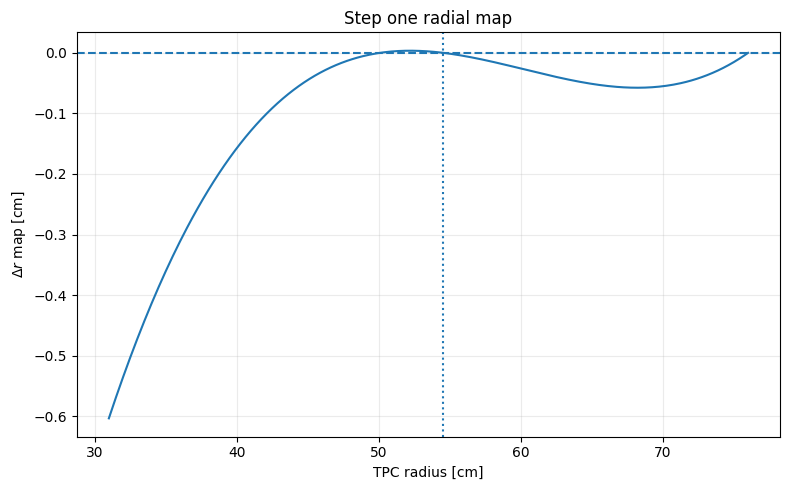

{
  "response": "global robust XY circle radius times effective abs(Bz)",
  "model": "smooth three-parameter radial polynomial after wide linear scan",
  "map_convention": "corrected_r = measured_r - delta_r",
  "pivot_r_cm": 54.5,
  "radial_scale_cm": 15.5,
  "coefficients_cm": [
    -0.043521948158741,
    -0.12273978441953659,
    0.1110486388206482
  ],
  "best_linear_scan_stretch_fraction": 0.0049999999999999906,
  "delta_r_at_39_cm": -0.1902664750814438,
  "delta_r_at_54p5_cm": 0.0,
  "delta_r_at_70_cm": -0.055213093757629395,
  "mean_abs_mass_error_before_mev": 1.5712634296492685,
  "mean_abs_mass_error_after_mev": 0.4338050138591269,
  "maximum_width_ratio": 1.1770301655318853,
  "median_circle_rms_ratio": 1.0069677829742432,
  "median_momentum_scale": 1.0089157819747925,
  "charge_mean_abs_ratio_error_before": 0.05242164433002472,
  "charge_mean_abs_ratio_error_after": 0.04628051444888115,
  "circle_rms_median_ratio_daughter1": 1.0067589282989502,
  "circle_rms_median_ratio_da

In [14]:
# ============================================================
# Save the step one radial calibration and compact summary
# ============================================================

radius = np.linspace(31.0, 76.0, 361).astype(np.float32)
with torch.no_grad():
    delta_r = step1_model(torch.from_numpy(radius)).numpy()

radial_map = pd.DataFrame({'r_cm': radius, 'delta_r_cm': delta_r})
radial_map.to_csv(work_dir / 'step1_radial_map.csv', index=False)

torch.save({
    'state_dict': step1_model.state_dict(),
    'coefficients_cm': step1_model.coefficients().detach().cpu().numpy(),
    'pivot_r_cm': step1_pivot_r_cm,
    'radial_scale_cm': step1_radial_scale_cm,
    'model': 'delta_r = a1*u + a2*u^2 + a3*u^3',
    'map_convention': 'corrected_r = measured_r - delta_r',
}, checkpoint_dir / 'step1_radial_circle_model.pt')

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(radius, delta_r)
ax.axhline(0.0, linestyle='--')
ax.axvline(step1_pivot_r_cm, linestyle=':')
ax.set_xlabel('TPC radius [cm]')
ax.set_ylabel(r'$\Delta r$ map [cm]')
ax.set_title('Step one radial map')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(work_dir / 'step1_radial_map.pdf')
plt.show()

mass_usable = step1_mass_table['neff'] >= pt_mass_scale_minimum_effective_entries
charge_before_active = charge_before['active'].to_numpy(bool)
charge_after_active = charge_after['active'].to_numpy(bool)
coefficients = step1_model.coefficients().detach().cpu().numpy()

summary = {
    'response': 'global robust XY circle radius times effective abs(Bz)',
    'model': 'smooth three-parameter radial polynomial after wide linear scan',
    'map_convention': 'corrected_r = measured_r - delta_r',
    'pivot_r_cm': step1_pivot_r_cm,
    'radial_scale_cm': step1_radial_scale_cm,
    'coefficients_cm': [float(x) for x in coefficients],
    'best_linear_scan_stretch_fraction': float(best_linear_stretch),
    'delta_r_at_39_cm': float(np.interp(39.0, radius, delta_r)),
    'delta_r_at_54p5_cm': float(np.interp(54.5, radius, delta_r)),
    'delta_r_at_70_cm': float(np.interp(70.0, radius, delta_r)),
    'mean_abs_mass_error_before_mev': float(np.nanmean(np.abs(step1_mass_table.loc[mass_usable, 'mean_error_before_mev']))),
    'mean_abs_mass_error_after_mev': float(np.nanmean(np.abs(step1_mass_table.loc[mass_usable, 'mean_error_after_mev']))),
    'maximum_width_ratio': float(np.nanmax(step1_mass_table.loc[mass_usable, 'width_ratio'])),
    'median_circle_rms_ratio': float(np.nanmedian(circle_rms_ratio)),
    'median_momentum_scale': float(np.nanmedian(momentum_scale)),
    'charge_mean_abs_ratio_error_before': float(np.nanmean(np.abs(charge_before.loc[charge_before_active, 'ratio'] - 1.0))),
    'charge_mean_abs_ratio_error_after': float(np.nanmean(np.abs(charge_after.loc[charge_after_active, 'ratio'] - 1.0))),
    'circle_rms_median_ratio_daughter1': float(step1_circle_fit_guard.loc[step1_circle_fit_guard['daughter'] == 1, 'median_corrected_over_raw_rms'].iloc[0]),
    'circle_rms_median_ratio_daughter2': float(step1_circle_fit_guard.loc[step1_circle_fit_guard['daughter'] == 2, 'median_corrected_over_raw_rms'].iloc[0]),
    'circle_rms_p90_ratio_daughter1': float(step1_circle_fit_guard.loc[step1_circle_fit_guard['daughter'] == 1, 'p90_corrected_over_raw_rms'].iloc[0]),
    'circle_rms_p90_ratio_daughter2': float(step1_circle_fit_guard.loc[step1_circle_fit_guard['daughter'] == 2, 'p90_corrected_over_raw_rms'].iloc[0]),
}
with open(work_dir / 'step1_summary.json', 'w') as output:
    json.dump(summary, output, indent=2)

print(json.dumps(summary, indent=2))
print('Step one complete. Do not add rDeltaPhi or z until these QA plots look physically sensible.')


## 8. Step two — freeze radial map, fit $r\Delta\phi$

Step one is now frozen. Step two starts from an exact identity relative to the Step-one
reconstruction and is allowed to change only:

1. a compact side-dependent $r\Delta\phi(r,\phi,z)$ field;
2. an optional small radial fine term, strongly anchored to zero.

The two main targets are K0S width and pi+/pi- charge balance. The Step-one mass-vs-pT
calibration is preserved with an explicit guard.


In [15]:
# ============================================================
# Step two reference: freeze the Step-one corrected trajectories
# ============================================================

for parameter in step1_model.parameters():
    parameter.requires_grad_(False)
step1_model.eval()


def fit_circle_xy_with_tangent(position, mask):
    x, y = position[..., 0], position[..., 1]
    weight = mask

    radius, center_x, center_y, residual = _circle_solve_xy(x, y, weight)
    robust_weight = 1.0 / torch.sqrt(1.0 + (residual / circle_robust_scale_cm) ** 2)
    radius, center_x, center_y, residual = _circle_solve_xy(x, y, weight * robust_weight)

    rms = torch.sqrt(torch.sum(weight * residual ** 2, dim=1) / torch.clamp(weight.sum(dim=1), min=1.0))
    number_of_points = weight.sum(dim=1)

    rxy = torch.sqrt(torch.clamp(x * x + y * y, min=1.0e-10))
    inner_index = torch.argmin(torch.where(weight > 0.5, rxy, torch.full_like(rxy, float('inf'))), dim=1)
    outer_index = torch.argmax(torch.where(weight > 0.5, rxy, torch.full_like(rxy, -float('inf'))), dim=1)

    gather = lambda values, index: torch.gather(values, 1, index[:, None]).squeeze(1)
    inner_x, inner_y = gather(x, inner_index), gather(y, inner_index)
    outer_x, outer_y = gather(x, outer_index), gather(y, outer_index)

    radial_x, radial_y = inner_x - center_x, inner_y - center_y
    tangent = torch.stack([-radial_y, radial_x], dim=1)
    tangent = tangent / torch.sqrt(torch.clamp(torch.sum(tangent * tangent, dim=1), min=1.0e-10))[:, None]
    chord = torch.stack([outer_x - inner_x, outer_y - inner_y], dim=1)
    sign = torch.where(torch.sum(tangent * chord, dim=1) >= 0.0, 1.0, -1.0)
    tangent = tangent * sign[:, None]
    tangent_phi = torch.atan2(tangent[:, 1], tangent[:, 0])

    valid = (
        (number_of_points >= circle_minimum_points)
        & torch.isfinite(radius)
        & torch.isfinite(rms)
        & torch.isfinite(tangent_phi)
        & (radius >= circle_minimum_radius_cm)
        & (radius <= circle_maximum_radius_cm)
    )
    return radius, rms, tangent_phi, valid


def attach_step1_track_reference(arrays, suffix, batch_size=step2_reference_batch_size):
    number = len(arrays['candidate_id'])
    outputs = {
        'radius': np.zeros(number, dtype=np.float32),
        'bz': np.zeros(number, dtype=np.float32),
        'rms': np.zeros(number, dtype=np.float32),
        'tangent_phi': np.zeros(number, dtype=np.float32),
        'pt': np.zeros(number, dtype=np.float32),
        'valid': np.zeros(number, dtype=np.uint8),
    }

    for start in range(0, number, batch_size):
        stop = min(start + batch_size, number)
        r = torch.from_numpy(arrays[f'r{suffix}'][start:stop])
        phi = torch.from_numpy(arrays[f'phi_cluster{suffix}'][start:stop])
        z = torch.from_numpy(arrays[f'z_cluster{suffix}'][start:stop])
        mask = torch.from_numpy(arrays[f'mask{suffix}'][start:stop])

        raw_field = torch.stack([
            torch.from_numpy(arrays[f'field_bx{suffix}'][start:stop]),
            torch.from_numpy(arrays[f'field_by{suffix}'][start:stop]),
            torch.from_numpy(arrays[f'field_bz{suffix}'][start:stop]),
        ], dim=-1)
        raw_gradient = torch.stack([
            torch.from_numpy(arrays[f'dbx_dx{suffix}'][start:stop]),
            torch.from_numpy(arrays[f'dbx_dy{suffix}'][start:stop]),
            torch.from_numpy(arrays[f'dbx_dz{suffix}'][start:stop]),
            torch.from_numpy(arrays[f'dby_dx{suffix}'][start:stop]),
            torch.from_numpy(arrays[f'dby_dy{suffix}'][start:stop]),
            torch.from_numpy(arrays[f'dby_dz{suffix}'][start:stop]),
            torch.from_numpy(arrays[f'dbz_dx{suffix}'][start:stop]),
            torch.from_numpy(arrays[f'dbz_dy{suffix}'][start:stop]),
            torch.from_numpy(arrays[f'dbz_dz{suffix}'][start:stop]),
        ], dim=-1).reshape(stop - start, r.shape[1], 3, 3)

        raw_position = raw_position_from_cylindrical(r, phi, z)

        with torch.no_grad():
            delta_r = step1_model(r)
            corrected_r = r - delta_r * mask
            corrected_position = raw_position_from_cylindrical(corrected_r, phi, z)
            corrected_field = corrected_field_from_raw(raw_position, corrected_position, raw_field, raw_gradient)

            radius, rms, tangent_phi, valid = fit_circle_xy_with_tangent(corrected_position, mask)
            bz = effective_abs_bz(corrected_position, corrected_field, mask)

            raw_radius = torch.from_numpy(arrays[f'raw_circle_radius{suffix}'][start:stop])
            raw_bz = torch.from_numpy(arrays[f'raw_effective_abs_bz{suffix}'][start:stop])
            raw_valid = torch.from_numpy(arrays[f'raw_circle_valid{suffix}'][start:stop]).to(torch.bool)

            scale = (radius * bz) / torch.clamp(raw_radius * raw_bz, min=1.0e-6)
            scale_valid = raw_valid & valid & torch.isfinite(scale)
            scale = torch.where(scale_valid, scale, torch.ones_like(scale))
            scale = torch.clamp(scale, min=minimum_refit_scale, max=maximum_refit_scale)

            original_pt = torch.from_numpy(arrays[f'pt{suffix}'][start:stop])
            pt = original_pt * scale

        outputs['radius'][start:stop] = radius.numpy().astype(np.float32)
        outputs['bz'][start:stop] = bz.numpy().astype(np.float32)
        outputs['rms'][start:stop] = rms.numpy().astype(np.float32)
        outputs['tangent_phi'][start:stop] = tangent_phi.numpy().astype(np.float32)
        outputs['pt'][start:stop] = pt.numpy().astype(np.float32)
        outputs['valid'][start:stop] = scale_valid.numpy().astype(np.uint8)

    arrays[f'step1_circle_radius{suffix}'] = outputs['radius']
    arrays[f'step1_effective_abs_bz{suffix}'] = outputs['bz']
    arrays[f'step1_circle_rms{suffix}'] = outputs['rms']
    arrays[f'step1_circle_tangent_phi{suffix}'] = outputs['tangent_phi']
    arrays[f'step1_pt{suffix}'] = outputs['pt']
    arrays[f'step1_circle_valid{suffix}'] = outputs['valid']


def invariant_mass_numpy(pt1, phi1, eta1, pt2, phi2, eta2, mass1=pion_mass, mass2=pion_mass):
    px1, py1, pz1 = pt1 * np.cos(phi1), pt1 * np.sin(phi1), pt1 * np.sinh(eta1)
    px2, py2, pz2 = pt2 * np.cos(phi2), pt2 * np.sin(phi2), pt2 * np.sinh(eta2)
    p21, p22 = px1 * px1 + py1 * py1 + pz1 * pz1, px2 * px2 + py2 * py2 + pz2 * pz2
    energy1, energy2 = np.sqrt(p21 + mass1 ** 2), np.sqrt(p22 + mass2 ** 2)
    total_p2 = (px1 + px2) ** 2 + (py1 + py2) ** 2 + (pz1 + pz2) ** 2
    return np.sqrt(np.maximum((energy1 + energy2) ** 2 - total_p2, 0.0)).astype(np.float32)


for suffix in ['1', '2']:
    print(f'Preparing frozen Step-one reference for daughter {suffix} ...')
    attach_step1_track_reference(kshort_arrays, suffix)

kshort_arrays['step1_mass'] = invariant_mass_numpy(
    kshort_arrays['step1_pt1'], kshort_arrays['phi1'], kshort_arrays['eta1'],
    kshort_arrays['step1_pt2'], kshort_arrays['phi2'], kshort_arrays['eta2'],
)
kshort_arrays['step1_pt_positive'] = np.where(kshort_arrays['charge1'] > 0, kshort_arrays['step1_pt1'], kshort_arrays['step1_pt2']).astype(np.float32)
kshort_arrays['step1_pt_negative'] = np.where(kshort_arrays['charge1'] < 0, kshort_arrays['step1_pt1'], kshort_arrays['step1_pt2']).astype(np.float32)

step2_reference_valid = kshort_arrays['step1_circle_valid1'].astype(bool) & kshort_arrays['step1_circle_valid2'].astype(bool)
print('Candidates with valid Step-one reference circles:', int(step2_reference_valid.sum()), '/', len(step2_reference_valid))
print('Max |stored Step-one mass - direct Step-one validation| will be checked again in the zero-map test below.')


Preparing frozen Step-one reference for daughter 1 ...
Preparing frozen Step-one reference for daughter 2 ...
Candidates with valid Step-one reference circles: 41643 / 41643
Max |stored Step-one mass - direct Step-one validation| will be checked again in the zero-map test below.


In [16]:
# ============================================================
# Compact Step-two rDeltaPhi model and incremental circle response
# ============================================================

step2_rphi_basis_names = [
    'u', 'u2', 'u3', 'u*v', 'u2*v',
    'u*sin(phi)', 'u*cos(phi)', 'u*sin(2phi)', 'u*cos(2phi)',
]


class StepTwoRPhiModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.raw_rphi_coefficients = nn.Parameter(torch.zeros(2, len(step2_rphi_basis_names), dtype=torch.float32))
        self.raw_radial_fine_coefficients = nn.Parameter(torch.zeros(3, dtype=torch.float32))
        self.register_buffer('radial_fine_bounds', torch.tensor(step2_radial_fine_coefficient_bounds_cm, dtype=torch.float32))

    def rphi_coefficients(self):
        return step2_rphi_coefficient_bound_cm * torch.tanh(self.raw_rphi_coefficients)

    def radial_fine_coefficients(self):
        if not step2_allow_radial_fine_tuning:
            return torch.zeros(3, dtype=self.raw_radial_fine_coefficients.dtype, device=self.raw_radial_fine_coefficients.device)
        return self.radial_fine_bounds * torch.tanh(self.raw_radial_fine_coefficients)

    def basis(self, r, phi, z):
        u = (r - step1_pivot_r_cm) / step1_radial_scale_cm
        v = z / 102.325
        return torch.stack([
            u, u ** 2, u ** 3, u * v, u ** 2 * v,
            u * torch.sin(phi), u * torch.cos(phi),
            u * torch.sin(2.0 * phi), u * torch.cos(2.0 * phi),
        ], dim=-1)

    def forward(self, r, phi, z, side):
        basis = self.basis(r, phi, z)
        coefficients = self.rphi_coefficients()[side.to(torch.long)]
        r_delta_phi = torch.sum(basis * coefficients[:, None, :], dim=-1)
        r_delta_phi = torch.clamp(r_delta_phi, -step2_max_abs_rdelta_phi_cm, step2_max_abs_rdelta_phi_cm)

        u = (r - step1_pivot_r_cm) / step1_radial_scale_cm
        a1, a2, a3 = self.radial_fine_coefficients()
        fine_delta_r = a1 * u + a2 * u ** 2 + a3 * u ** 3
        fine_delta_r = torch.clamp(fine_delta_r, -step2_max_abs_radial_fine_cm, step2_max_abs_radial_fine_cm)
        return fine_delta_r, r_delta_phi


def wrapped_delta_phi(phi_a, phi_b):
    return torch.atan2(torch.sin(phi_a - phi_b), torch.cos(phi_a - phi_b))


def refit_track_step2(
    model, r, phi, z, mask, side,
    original_phi, original_eta,
    raw_field, raw_gradient,
    step1_pt, step1_radius, step1_bz, step1_rms, step1_tangent_phi, step1_valid,
):
    raw_position = raw_position_from_cylindrical(r, phi, z)
    fine_delta_r, r_delta_phi = model(r, phi, z, side)

    with torch.no_grad():
        frozen_delta_r = step1_model(r)

    total_delta_r = frozen_delta_r + fine_delta_r
    corrected_r = r - total_delta_r * mask
    corrected_phi_cluster = phi - (r_delta_phi / torch.clamp(r, min=1.0e-6)) * mask
    corrected_position = raw_position_from_cylindrical(corrected_r, corrected_phi_cluster, z)
    corrected_field = corrected_field_from_raw(raw_position, corrected_position, raw_field, raw_gradient)

    corrected_radius, corrected_rms, corrected_tangent_phi, corrected_valid = fit_circle_xy_with_tangent(corrected_position, mask)
    corrected_bz = effective_abs_bz(corrected_position, corrected_field, mask)

    additional_scale = (corrected_radius * corrected_bz) / torch.clamp(step1_radius * step1_bz, min=1.0e-6)
    valid = step1_valid.to(torch.bool) & corrected_valid & torch.isfinite(additional_scale)
    additional_scale = torch.where(valid, additional_scale, torch.ones_like(additional_scale))
    additional_scale = torch.clamp(
        additional_scale,
        min=step2_minimum_additional_refit_scale,
        max=step2_maximum_additional_refit_scale,
    )

    tangent_delta = wrapped_delta_phi(corrected_tangent_phi, step1_tangent_phi)
    tangent_delta = torch.where(valid, tangent_delta, torch.zeros_like(tangent_delta))
    corrected_track_phi = original_phi + step2_direction_correction_strength * tangent_delta
    corrected_pt = step1_pt * additional_scale

    corrected_momentum = torch.stack([
        corrected_pt * torch.cos(corrected_track_phi),
        corrected_pt * torch.sin(corrected_track_phi),
        corrected_pt * torch.sinh(original_eta),
    ], dim=1)

    return {
        'momentum': corrected_momentum,
        'pt': corrected_pt,
        'track_phi': corrected_track_phi,
        'additional_momentum_scale': additional_scale,
        'tangent_delta': tangent_delta,
        'circle_valid': valid,
        'step1_circle_rms': step1_rms,
        'corrected_circle_rms': corrected_rms,
        'step1_circle_radius': step1_radius,
        'corrected_circle_radius': corrected_radius,
        'corrected_circle_tangent_phi': corrected_tangent_phi,
        'corrected_effective_abs_bz': corrected_bz,
        'fine_delta_r': fine_delta_r,
        'r_delta_phi': r_delta_phi,
    }


def correct_batch_step2(model, batch):
    field1, gradient1 = track_field_tensors(batch, '1')
    field2, gradient2 = track_field_tensors(batch, '2')

    first = refit_track_step2(
        model, batch['r1'], batch['phi_cluster1'], batch['z_cluster1'], batch['mask1'], batch['side1'],
        batch['phi1'], batch['eta1'], field1, gradient1,
        batch['step1_pt1'], batch['step1_circle_radius1'], batch['step1_effective_abs_bz1'],
        batch['step1_circle_rms1'], batch['step1_circle_tangent_phi1'], batch['step1_circle_valid1'],
    )
    second = refit_track_step2(
        model, batch['r2'], batch['phi_cluster2'], batch['z_cluster2'], batch['mask2'], batch['side2'],
        batch['phi2'], batch['eta2'], field2, gradient2,
        batch['step1_pt2'], batch['step1_circle_radius2'], batch['step1_effective_abs_bz2'],
        batch['step1_circle_rms2'], batch['step1_circle_tangent_phi2'], batch['step1_circle_valid2'],
    )

    corrected_mass = invariant_mass(first['momentum'], second['momentum'], pion_mass, pion_mass)
    return first, second, corrected_mass


In [17]:
# ============================================================
# Step-two width, charge-balance, mass-preservation and fit-quality losses
# ============================================================

def soft_histogram_counts_and_squares(values, weights, minimum, maximum, number_of_bins):
    edges = torch.linspace(minimum, maximum, number_of_bins + 1, dtype=values.dtype, device=values.device)
    centers = 0.5 * (edges[:-1] + edges[1:])
    bin_width = (maximum - minimum) / number_of_bins

    membership = torch.clamp(1.0 - torch.abs(values[:, None] - centers[None, :]) / bin_width, min=0.0)
    weighted = weights[:, None] * membership
    counts = weighted.sum(dim=0)
    sum_squares = (weighted ** 2).sum(dim=0)
    return centers, counts, sum_squares


def step2_charge_balance_loss(first, second, batch):
    weights = batch['pair_weight'] * batch['mass_core_weight']
    positive_pt = torch.where(batch['charge1'] > 0, first['pt'], second['pt'])
    negative_pt = torch.where(batch['charge1'] < 0, first['pt'], second['pt'])

    centers, plus, plus2 = soft_histogram_counts_and_squares(
        positive_pt, weights, charge_balance_pt_minimum_gev, charge_balance_pt_maximum_gev, charge_balance_number_of_bins
    )
    _, minus, minus2 = soft_histogram_counts_and_squares(
        negative_pt, weights, charge_balance_pt_minimum_gev, charge_balance_pt_maximum_gev, charge_balance_number_of_bins
    )

    neff_plus = plus ** 2 / torch.clamp(plus2, min=1.0e-12)
    neff_minus = minus ** 2 / torch.clamp(minus2, min=1.0e-12)
    active = (neff_plus >= step2_charge_minimum_bin_effective_entries) & (neff_minus >= step2_charge_minimum_bin_effective_entries)

    log_ratio = torch.log(torch.clamp(plus, min=1.0e-8) / torch.clamp(minus, min=1.0e-8))
    variance = 1.0 / torch.clamp(neff_plus, min=1.0) + 1.0 / torch.clamp(neff_minus, min=1.0)
    variance = variance + step2_charge_systematic_floor_fraction ** 2

    priority = torch.clamp(
        (centers / step2_charge_pt_priority_reference_gev) ** step2_charge_pt_priority_power,
        max=step2_charge_maximum_priority,
    )
    bin_weight = active.to(log_ratio.dtype) * priority / torch.clamp(variance, min=1.0e-8)
    loss = torch.sum(bin_weight * log_ratio ** 2) / torch.clamp(bin_weight.sum(), min=1.0)
    return loss


def step2_mass_width_terms(corrected_mass, batch):
    weights_all = batch['pair_weight'] * batch['mass_core_weight']
    mass_errors, active_weights, width_losses = [], [], []

    for lower, upper in zip(pt_mass_scale_bin_edges[:-1], pt_mass_scale_bin_edges[1:]):
        selected = (batch['pair_pt'] >= float(lower)) & (batch['pair_pt'] < float(upper))
        weights = weights_all * selected.to(weights_all.dtype)

        corrected_mean, corrected_variance, neff = torch_weighted_mean_variance(corrected_mass, weights)
        _, step1_variance, _ = torch_weighted_mean_variance(batch['step1_mass'], weights)

        active = (neff >= pt_mass_scale_minimum_effective_entries).to(corrected_mass.dtype)
        mass_error = (corrected_mean - pdg_kshort_mass) / step2_mass_scale_gev
        width_ratio = torch.sqrt(torch.clamp(corrected_variance / torch.clamp(step1_variance, min=1.0e-8), min=0.0))

        mass_errors.append(mass_error)
        active_weights.append(active)
        width_losses.append(width_ratio ** 2)

    mass_errors = torch.stack(mass_errors)
    active_weights = torch.stack(active_weights)
    width_losses = torch.stack(width_losses)
    normalization = torch.clamp(active_weights.sum(), min=1.0)

    pt_mass = torch.sum(active_weights * mass_errors ** 2) / normalization
    mean_error = torch.sum(active_weights * mass_errors) / normalization
    flatness = torch.sum(active_weights * (mass_errors - mean_error) ** 2) / normalization
    width = torch.sum(active_weights * width_losses) / normalization

    inclusive_mean, _, _ = torch_weighted_mean_variance(corrected_mass, weights_all)
    inclusive_mass = ((inclusive_mean - pdg_kshort_mass) / step2_mass_scale_gev) ** 2
    return pt_mass, flatness, inclusive_mass, width


def step2_circle_rms_terms(first, second):
    ratios = []
    guards = []

    for track in [first, second]:
        ratio = track['corrected_circle_rms'] / torch.clamp(track['step1_circle_rms'], min=1.0e-6)
        valid = track['circle_valid'].to(ratio.dtype)
        normalization = torch.clamp(valid.sum(), min=1.0)

        ratios.append(torch.sum(valid * ratio ** 2) / normalization)
        excess = torch.relu(ratio - step2_max_preferred_circle_rms_ratio) / 0.08
        guards.append(torch.sum(valid * excess ** 2) / normalization)

    return 0.5 * (ratios[0] + ratios[1]), 0.5 * (guards[0] + guards[1])


def step2_map_regularization(model):
    rphi_coefficients = model.rphi_coefficients()
    radial_coefficients = model.radial_fine_coefficients()

    rphi_regularization = torch.mean((rphi_coefficients / 0.12) ** 2)
    radial_anchor = torch.mean((radial_coefficients / 0.05) ** 2)
    return rphi_regularization, radial_anchor


def step2_batch_loss(model, batch):
    first, second, corrected_mass = correct_batch_step2(model, batch)
    pt_mass, flatness, inclusive_mass, width = step2_mass_width_terms(corrected_mass, batch)
    charge = step2_charge_balance_loss(first, second, batch)
    circle_rms, circle_guard = step2_circle_rms_terms(first, second)
    rphi_regularization, radial_anchor = step2_map_regularization(model)

    total = (
        step2_width_weight * width
        + step2_charge_balance_weight * charge
        + step2_pt_mass_weight * pt_mass
        + step2_flatness_weight * flatness
        + step2_inclusive_mass_weight * inclusive_mass
        + step2_circle_rms_weight * circle_rms
        + step2_circle_rms_guard_weight * circle_guard
        + step2_rphi_regularization_weight * rphi_regularization
        + step2_radial_anchor_weight * radial_anchor
    )

    terms = {
        'width': width,
        'charge': charge,
        'pt_mass': pt_mass,
        'flatness': flatness,
        'inclusive_mass': inclusive_mass,
        'circle_rms': circle_rms,
        'circle_guard': circle_guard,
        'rphi_regularization': rphi_regularization,
        'radial_anchor': radial_anchor,
    }
    return total, terms


In [18]:
# ============================================================
# Step-two split, explicit batch sizes, and zero-map identity check
# ============================================================

step2_training_indices = np.flatnonzero(
    (kshort_arrays['event_parity'].astype(np.int64) == training_parity) & step2_reference_valid
)
step2_validation_indices = np.flatnonzero(
    (kshort_arrays['event_parity'].astype(np.int64) == validation_parity) & step2_reference_valid
)

step2_fit_indices = stratified_indices_by_pt(
    step2_training_indices, kshort_arrays['pair_pt'], pt_mass_scale_bin_edges,
    step2_fit_candidates_per_pt_bin, seed + 2100,
)
step2_validation_fit_indices = stratified_indices_by_pt(
    step2_validation_indices, kshort_arrays['pair_pt'], pt_mass_scale_bin_edges,
    step2_validation_candidates_per_pt_bin, seed + 2200,
)

print('Step-two training candidates:', len(step2_training_indices))
print('Step-two held-out candidates:', len(step2_validation_indices))
print('Step-two balanced fit candidates:', len(step2_fit_indices))
print('Step-two balanced validation candidates:', len(step2_validation_fit_indices))
print('Step-two fit batch size:', step2_batch_size)
print('Step-two validation batch size:', step2_validation_batch_size)
display(pt_bin_counts(step2_fit_indices, kshort_arrays['pair_pt'], pt_mass_scale_bin_edges))


def evaluate_step2(model, arrays, indices, batch_size=None):
    batch_size = batch_size or step2_validation_batch_size
    loader = DataLoader(
        CandidateDataset(arrays, indices),
        batch_size=min(batch_size, len(indices)),
        shuffle=False,
        num_workers=0,
    )

    keys = [
        'mass_input', 'mass_step1', 'mass_step2', 'pair_pt', 'pair_weight', 'mass_core_weight',
        'pt_positive_input', 'pt_negative_input', 'pt_positive_step1', 'pt_negative_step1',
        'pt_positive_step2', 'pt_negative_step2',
        'additional_scale1', 'additional_scale2', 'tangent_delta1', 'tangent_delta2',
        'circle_rms_ratio1', 'circle_rms_ratio2',
    ]
    collected = {key: [] for key in keys}

    model.eval()
    with torch.no_grad():
        for batch in loader:
            first, second, mass_step2 = correct_batch_step2(model, batch)

            positive_input = torch.where(batch['charge1'] > 0, batch['pt1'], batch['pt2'])
            negative_input = torch.where(batch['charge1'] < 0, batch['pt1'], batch['pt2'])
            positive_step2 = torch.where(batch['charge1'] > 0, first['pt'], second['pt'])
            negative_step2 = torch.where(batch['charge1'] < 0, first['pt'], second['pt'])

            values = {
                'mass_input': batch['baseline_mass'],
                'mass_step1': batch['step1_mass'],
                'mass_step2': mass_step2,
                'pair_pt': batch['pair_pt'],
                'pair_weight': batch['pair_weight'],
                'mass_core_weight': batch['mass_core_weight'],
                'pt_positive_input': positive_input,
                'pt_negative_input': negative_input,
                'pt_positive_step1': batch['step1_pt_positive'],
                'pt_negative_step1': batch['step1_pt_negative'],
                'pt_positive_step2': positive_step2,
                'pt_negative_step2': negative_step2,
                'additional_scale1': first['additional_momentum_scale'],
                'additional_scale2': second['additional_momentum_scale'],
                'tangent_delta1': first['tangent_delta'],
                'tangent_delta2': second['tangent_delta'],
                'circle_rms_ratio1': first['corrected_circle_rms'] / torch.clamp(first['step1_circle_rms'], min=1.0e-6),
                'circle_rms_ratio2': second['corrected_circle_rms'] / torch.clamp(second['step1_circle_rms'], min=1.0e-6),
            }
            for key, value in values.items():
                collected[key].append(value.detach().cpu().numpy())

    return {key: np.concatenate(value) for key, value in collected.items()}


step2_model = StepTwoRPhiModel()

zero_indices = step2_validation_fit_indices[: min(2500, len(step2_validation_fit_indices))]
zero_prediction = evaluate_step2(step2_model, kshort_arrays, zero_indices)
zero_mass_difference = float(np.max(np.abs(zero_prediction['mass_step2'] - zero_prediction['mass_step1'])))
zero_scale_difference = max(
    float(np.max(np.abs(zero_prediction['additional_scale1'] - 1.0))),
    float(np.max(np.abs(zero_prediction['additional_scale2'] - 1.0))),
)
zero_tangent_difference = max(
    float(np.max(np.abs(zero_prediction['tangent_delta1']))),
    float(np.max(np.abs(zero_prediction['tangent_delta2']))),
)

print('Step-two zero-map max |mass_step2-mass_step1|:', zero_mass_difference)
print('Step-two zero-map max |additional scale-1|:', zero_scale_difference)
print('Step-two zero-map max |tangent delta|:', zero_tangent_difference)

if zero_mass_difference > 3.0e-5 or zero_scale_difference > 3.0e-5 or zero_tangent_difference > 3.0e-5:
    raise RuntimeError('Step-two response fails the exact Step-one identity check.')


Step-two training candidates: 20767
Step-two held-out candidates: 20876
Step-two balanced fit candidates: 10800
Step-two balanced validation candidates: 6000
Step-two fit batch size: 12000
Step-two validation batch size: 8000


,pt_low,pt_high,candidates
0,0.5,0.8,1800
1,0.8,1.1,1800
2,1.1,1.4,1800
3,1.4,1.8,1800
4,1.8,2.2,1800
5,2.2,3.0,1800


Step-two zero-map max |mass_step2-mass_step1|: 3.6954879760742188e-06
Step-two zero-map max |additional scale-1|: 0.0
Step-two zero-map max |tangent delta|: 0.0


/tmp/ipykernel_7061/2781211661.py:64: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  rphi_rms = float(torch.sqrt(torch.mean(step2_model.rphi_coefficients() ** 2)))


epoch 00: validation=1.5910 width=0.9893 charge=0.0107 mass=0.6097 coef_rms(rphi)=0.0010 cm coef_rms(dr-fine)=0.0004 cm
epoch 02: validation=1.5287 width=0.9975 charge=0.0106 mass=0.5279 coef_rms(rphi)=0.0030 cm coef_rms(dr-fine)=0.0012 cm
epoch 04: validation=1.5028 width=1.0153 charge=0.0110 mass=0.4749 coef_rms(rphi)=0.0045 cm coef_rms(dr-fine)=0.0020 cm
epoch 06: validation=1.4749 width=1.0130 charge=0.0116 mass=0.4440 coef_rms(rphi)=0.0055 cm coef_rms(dr-fine)=0.0027 cm
epoch 08: validation=1.4480 width=1.0033 charge=0.0123 mass=0.4240 coef_rms(rphi)=0.0063 cm coef_rms(dr-fine)=0.0033 cm
epoch 10: validation=1.4258 width=0.9964 charge=0.0127 mass=0.4069 coef_rms(rphi)=0.0073 cm coef_rms(dr-fine)=0.0037 cm
epoch 12: validation=1.4038 width=0.9938 charge=0.0123 mass=0.3855 coef_rms(rphi)=0.0084 cm coef_rms(dr-fine)=0.0040 cm
epoch 14: validation=1.3777 width=0.9937 charge=0.0114 mass=0.3569 coef_rms(rphi)=0.0096 cm coef_rms(dr-fine)=0.0041 cm
epoch 16: validation=1.3525 width=0.9953

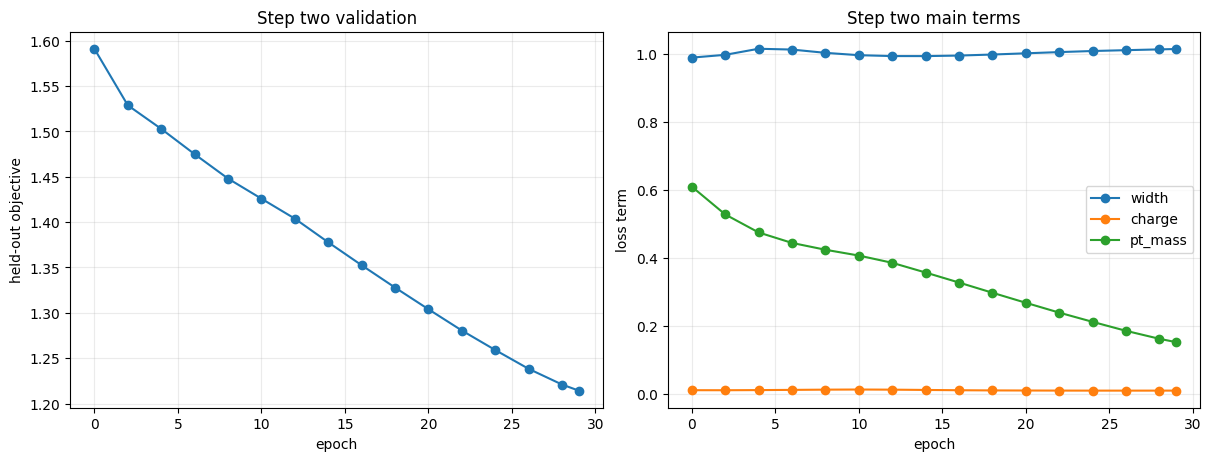

Best Step-two epoch: 29
Best Step-two validation score: 1.2142517566680908
Step-two rDeltaPhi coefficients [cm]:


,u,u2,u3,u*v,u2*v,u*sin(phi),u*cos(phi),u*sin(2phi),u*cos(2phi)
side0,0.005728,0.014364,0.029614,0.024059,-0.005662,0.023129,0.002411,0.027715,-0.014640
side1,-0.001081,0.009306,0.020539,0.020898,0.018352,-0.001722,-0.025354,0.027368,0.026932


Step-two radial fine coefficients [cm]: [-0.00679697 -0.00628819 -0.00642419]


In [19]:
# ============================================================
# Step-two fit: width + charge balance, with Step-one mass protected
# ============================================================

fit_dataset_step2 = CandidateDataset(kshort_arrays, step2_fit_indices)
validation_dataset_step2 = CandidateDataset(kshort_arrays, step2_validation_fit_indices)

if step2_batch_size < len(fit_dataset_step2):
    raise ValueError(
        f'step2_batch_size={step2_batch_size} is smaller than the balanced fit sample '
        f'({len(fit_dataset_step2)}). Increase it so charge balance is evaluated globally.'
    )
if step2_validation_batch_size < len(validation_dataset_step2):
    raise ValueError(
        f'step2_validation_batch_size={step2_validation_batch_size} is smaller than the balanced validation sample '
        f'({len(validation_dataset_step2)}). Increase it so validation charge balance is global.'
    )

fit_loader_step2 = DataLoader(
    fit_dataset_step2,
    batch_size=min(step2_batch_size, len(fit_dataset_step2)),
    shuffle=False,
    num_workers=0,
)
validation_loader_step2 = DataLoader(
    validation_dataset_step2,
    batch_size=min(step2_validation_batch_size, len(validation_dataset_step2)),
    shuffle=False,
    num_workers=0,
)
fit_batch_step2 = next(iter(fit_loader_step2))
validation_batch_step2 = next(iter(validation_loader_step2))

step2_history = []
best_step2_score = np.inf
best_step2_state = copy.deepcopy(step2_model.state_dict())
best_step2_epoch = -1
stale_step2_checks = 0

if run_step_two:
    optimizer = torch.optim.Adam(step2_model.parameters(), lr=step2_learning_rate)

    for epoch in range(step2_fit_epochs):
        step2_model.train()
        optimizer.zero_grad(set_to_none=True)
        total, terms = step2_batch_loss(step2_model, fit_batch_step2)
        total.backward()
        torch.nn.utils.clip_grad_norm_(step2_model.parameters(), step2_gradient_clip_norm)
        optimizer.step()

        row = {'epoch': epoch, 'training_total': float(total.detach())}
        row.update({key: float(value.detach()) for key, value in terms.items()})

        do_validation = (epoch % step2_validation_interval == 0) or (epoch == step2_fit_epochs - 1)
        if do_validation:
            step2_model.eval()
            with torch.no_grad():
                validation_total, validation_terms = step2_batch_loss(step2_model, validation_batch_step2)

            validation_score = float(validation_total)
            row['validation_score'] = validation_score
            row.update({f'validation_{key}': float(value) for key, value in validation_terms.items()})

            rphi_rms = float(torch.sqrt(torch.mean(step2_model.rphi_coefficients() ** 2)))
            radial_rms = float(torch.sqrt(torch.mean(step2_model.radial_fine_coefficients() ** 2)))
            print(
                f'epoch {epoch:02d}: validation={validation_score:.4f} '
                f'width={float(validation_terms["width"]):.4f} '
                f'charge={float(validation_terms["charge"]):.4f} '
                f'mass={float(validation_terms["pt_mass"]):.4f} '
                f'coef_rms(rphi)={rphi_rms:.4f} cm '
                f'coef_rms(dr-fine)={radial_rms:.4f} cm'
            )

            if validation_score < best_step2_score - step2_minimum_improvement:
                best_step2_score = validation_score
                best_step2_state = copy.deepcopy(step2_model.state_dict())
                best_step2_epoch = epoch
                stale_step2_checks = 0
            else:
                stale_step2_checks += 1
                if stale_step2_checks >= step2_patience:
                    step2_history.append(row)
                    print('Early stop: held-out Step-two objective stopped improving.')
                    break
        else:
            row['validation_score'] = np.nan

        step2_history.append(row)

    step2_model.load_state_dict(best_step2_state)

step2_history = pd.DataFrame(step2_history)
if not step2_history.empty:
    step2_history.to_csv(work_dir / 'step2_training_history.csv', index=False)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
    valid = step2_history[np.isfinite(step2_history['validation_score'])]
    axes[0].plot(valid['epoch'], valid['validation_score'], marker='o')
    axes[0].set_xlabel('epoch')
    axes[0].set_ylabel('held-out objective')
    axes[0].set_title('Step two validation')
    axes[0].grid(alpha=0.25)

    for name in ['validation_width', 'validation_charge', 'validation_pt_mass']:
        if name in valid:
            axes[1].plot(valid['epoch'], valid[name], marker='o', label=name.replace('validation_', ''))
    axes[1].set_xlabel('epoch')
    axes[1].set_ylabel('loss term')
    axes[1].set_title('Step two main terms')
    axes[1].grid(alpha=0.25)
    axes[1].legend()
    plt.show()

print('Best Step-two epoch:', best_step2_epoch)
print('Best Step-two validation score:', best_step2_score)
print('Step-two rDeltaPhi coefficients [cm]:')
display(pd.DataFrame(step2_model.rphi_coefficients().detach().numpy(), index=['side0', 'side1'], columns=step2_rphi_basis_names))
print('Step-two radial fine coefficients [cm]:', step2_model.radial_fine_coefficients().detach().numpy())


,pt_low,pt_high,entries,neff,mean_input,mean_step1,mean_step2,mean_error_input_mev,mean_error_step1_mev,mean_error_step2_mev,width_input_mev,width_step1_mev,width_step2_mev,width_ratio_step2_over_step1,width_ratio_step2_over_input
0,0.5,0.8,1863,1469.024650,0.494213,0.496882,0.497419,-3.397851,-0.729476,-0.191650,4.772690,5.142928,5.172762,1.005801,1.083825
1,0.8,1.1,2527,2026.508144,0.495487,0.497233,0.497610,-2.124401,-0.378023,-0.000634,5.190659,6.026670,6.052885,1.004350,1.166111
2,1.1,1.4,3244,2501.473364,0.496174,0.497375,0.497638,-1.436974,-0.236429,0.027265,5.581441,6.569515,6.673461,1.015822,1.195652
3,1.4,1.8,5140,3901.665566,0.496212,0.497240,0.497295,-1.398696,-0.371136,-0.316427,6.886876,7.834634,7.893055,1.007457,1.146101
4,1.8,2.2,4199,3155.119679,0.497102,0.497853,0.497714,-0.508709,0.241630,0.102674,8.673571,9.588912,9.708961,1.012520,1.119373
5,2.2,3.0,3138,2265.513568,0.498172,0.498257,0.497782,0.560950,0.646122,0.171061,9.221663,10.199250,10.474969,1.027033,1.135909


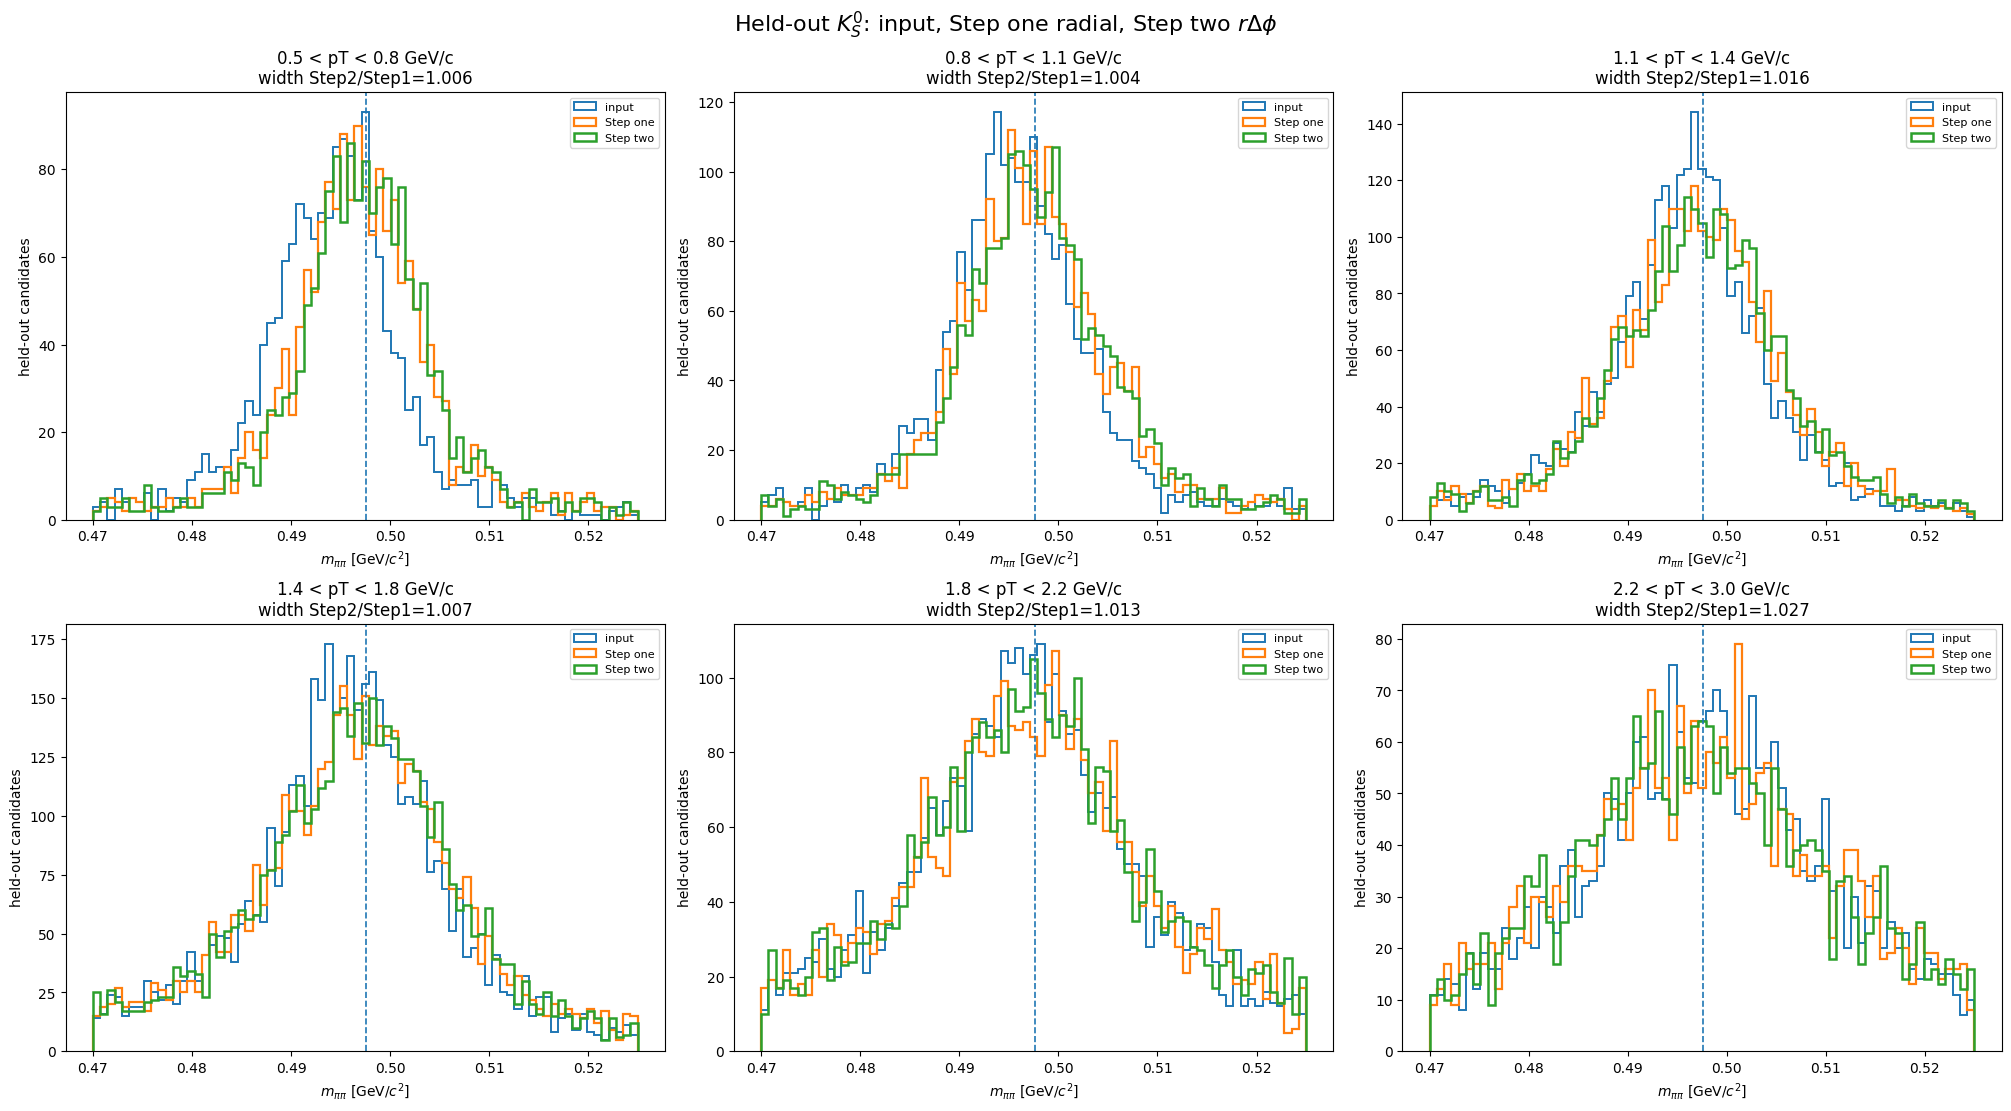

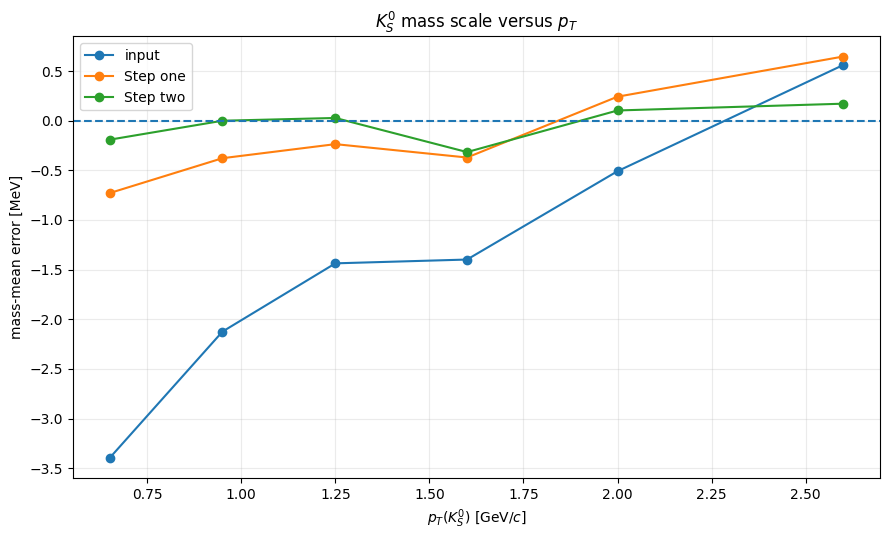

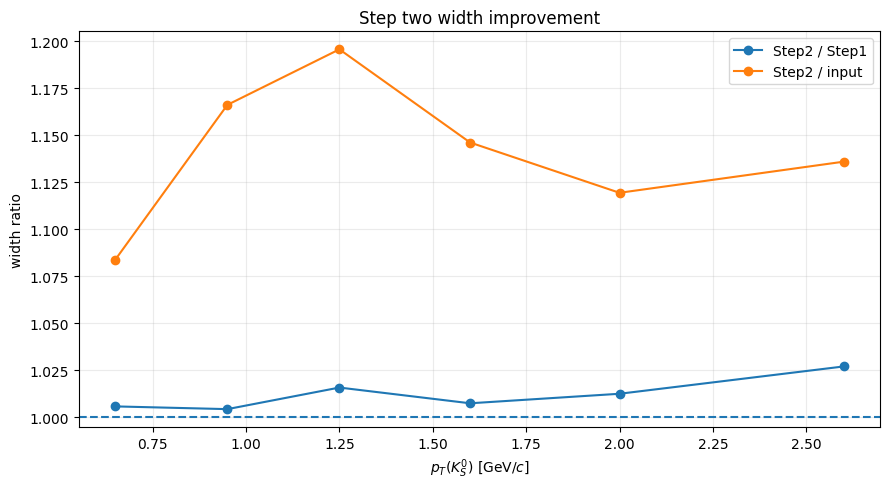

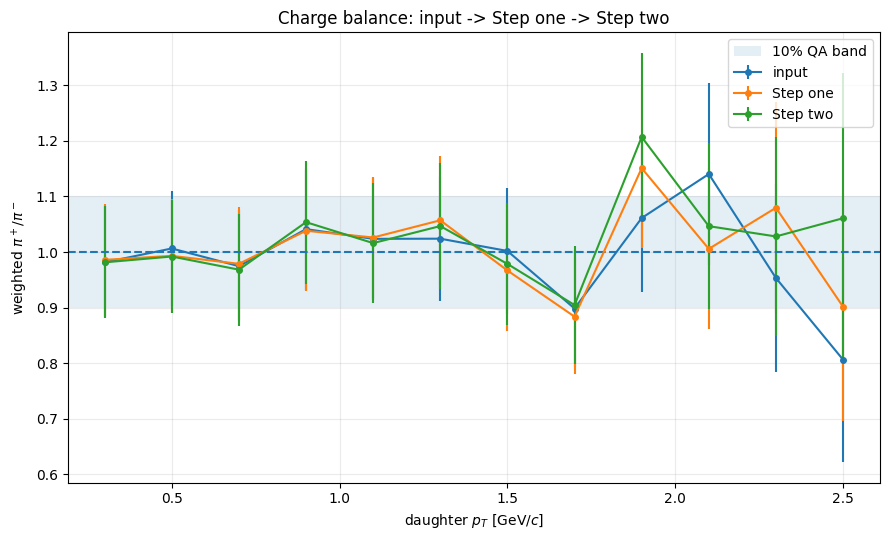

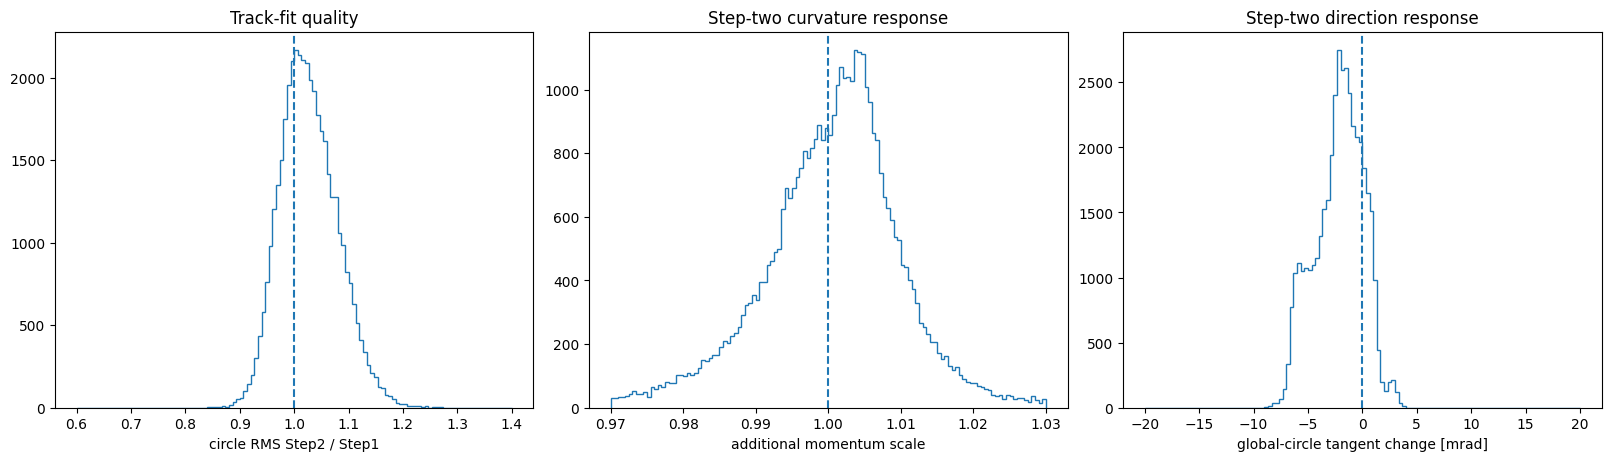

In [20]:
# ============================================================
# Held-out Step-two QA: input -> Step one -> Step two
# ============================================================

step2_validation = evaluate_step2(step2_model, kshort_arrays, step2_validation_indices)
weights = step2_validation['pair_weight'] * step2_validation['mass_core_weight']

rows = []
for lower, upper in zip(pt_mass_scale_bin_edges[:-1], pt_mass_scale_bin_edges[1:]):
    selected = (step2_validation['pair_pt'] >= lower) & (step2_validation['pair_pt'] < upper)
    input_peak = peak_metrics(step2_validation['mass_input'][selected], weights[selected])
    step1_peak = peak_metrics(step2_validation['mass_step1'][selected], weights[selected])
    step2_peak = peak_metrics(step2_validation['mass_step2'][selected], weights[selected])

    rows.append({
        'pt_low': float(lower),
        'pt_high': float(upper),
        'entries': int(selected.sum()),
        'neff': step2_peak['neff'],
        'mean_input': input_peak['mean'],
        'mean_step1': step1_peak['mean'],
        'mean_step2': step2_peak['mean'],
        'mean_error_input_mev': 1000.0 * (input_peak['mean'] - pdg_kshort_mass),
        'mean_error_step1_mev': 1000.0 * (step1_peak['mean'] - pdg_kshort_mass),
        'mean_error_step2_mev': 1000.0 * (step2_peak['mean'] - pdg_kshort_mass),
        'width_input_mev': 1000.0 * input_peak['width'],
        'width_step1_mev': 1000.0 * step1_peak['width'],
        'width_step2_mev': 1000.0 * step2_peak['width'],
        'width_ratio_step2_over_step1': step2_peak['width'] / max(step1_peak['width'], 1.0e-12),
        'width_ratio_step2_over_input': step2_peak['width'] / max(input_peak['width'], 1.0e-12),
    })

step2_mass_table = pd.DataFrame(rows)
step2_mass_table.to_csv(work_dir / 'step2_kshort_mass_vs_pt.csv', index=False)
display(step2_mass_table)

figure, axes = plt.subplots(2, 3, figsize=(20, 11), constrained_layout=True)
axes = axes.ravel()
for axis, row in zip(axes, step2_mass_table.itertuples(index=False)):
    selected = (step2_validation['pair_pt'] >= row.pt_low) & (step2_validation['pair_pt'] < row.pt_high)
    axis.hist(step2_validation['mass_input'][selected], bins=75, range=(0.47, 0.525), histtype='step', linewidth=1.4, label='input')
    axis.hist(step2_validation['mass_step1'][selected], bins=75, range=(0.47, 0.525), histtype='step', linewidth=1.6, label='Step one')
    axis.hist(step2_validation['mass_step2'][selected], bins=75, range=(0.47, 0.525), histtype='step', linewidth=1.8, label='Step two')
    axis.axvline(pdg_kshort_mass, linestyle='--', linewidth=1.2)
    axis.set_title(
        f'{row.pt_low:.1f} < pT < {row.pt_high:.1f} GeV/c\n'
        f'width Step2/Step1={row.width_ratio_step2_over_step1:.3f}'
    )
    axis.set_xlabel(r'$m_{\pi\pi}$ [GeV/$c^2$]')
    axis.set_ylabel('held-out candidates')
    axis.legend(fontsize=8)

figure.suptitle(r'Held-out $K_S^0$: input, Step one radial, Step two $r\Delta\phi$', fontsize=16)
plt.savefig(work_dir / 'step2_kshort_mass_shapes.pdf')
plt.show()

pt_center = 0.5 * (step2_mass_table['pt_low'].to_numpy() + step2_mass_table['pt_high'].to_numpy())

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(pt_center, step2_mass_table['mean_error_input_mev'], marker='o', label='input')
ax.plot(pt_center, step2_mass_table['mean_error_step1_mev'], marker='o', label='Step one')
ax.plot(pt_center, step2_mass_table['mean_error_step2_mev'], marker='o', label='Step two')
ax.axhline(0.0, linestyle='--')
ax.set_xlabel(r'$p_T(K_S^0)$ [GeV/$c$]')
ax.set_ylabel('mass-mean error [MeV]')
ax.set_title(r'$K_S^0$ mass scale versus $p_T$')
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.savefig(work_dir / 'step2_mass_scale_vs_pt.pdf')
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(pt_center, step2_mass_table['width_ratio_step2_over_step1'], marker='o', label='Step2 / Step1')
ax.plot(pt_center, step2_mass_table['width_ratio_step2_over_input'], marker='o', label='Step2 / input')
ax.axhline(1.0, linestyle='--')
ax.set_xlabel(r'$p_T(K_S^0)$ [GeV/$c$]')
ax.set_ylabel('width ratio')
ax.set_title('Step two width improvement')
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.savefig(work_dir / 'step2_width_vs_pt.pdf')
plt.show()

charge_weight = weights
charge_input = charge_balance_table(step2_validation['pt_positive_input'], step2_validation['pt_negative_input'], charge_weight)
charge_step1 = charge_balance_table(step2_validation['pt_positive_step1'], step2_validation['pt_negative_step1'], charge_weight)
charge_step2 = charge_balance_table(step2_validation['pt_positive_step2'], step2_validation['pt_negative_step2'], charge_weight)

for table, state in [(charge_input, 'input'), (charge_step1, 'step1'), (charge_step2, 'step2')]:
    table['state'] = state
pd.concat([charge_input, charge_step1, charge_step2], ignore_index=True).to_csv(work_dir / 'step2_charge_balance.csv', index=False)

fig, ax = plt.subplots(figsize=(9, 5.5))
for table, label in [(charge_input, 'input'), (charge_step1, 'Step one'), (charge_step2, 'Step two')]:
    active = table['active'].to_numpy(bool)
    ax.errorbar(table.loc[active, 'pt'], table.loc[active, 'ratio'], yerr=table.loc[active, 'sigma_ratio'], fmt='o-', ms=4, label=label)

ax.axhline(1.0, linestyle='--')
ax.axhspan(0.90, 1.10, alpha=0.12, label='10% QA band')
ax.set_xlabel(r'daughter $p_T$ [GeV/$c$]')
ax.set_ylabel(r'weighted $\pi^+/\pi^-$')
ax.set_title('Charge balance: input -> Step one -> Step two')
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.savefig(work_dir / 'step2_charge_balance.pdf')
plt.show()

circle_ratio = np.concatenate([step2_validation['circle_rms_ratio1'], step2_validation['circle_rms_ratio2']])
additional_scale = np.concatenate([step2_validation['additional_scale1'], step2_validation['additional_scale2']])
tangent_delta_mrad = 1000.0 * np.concatenate([step2_validation['tangent_delta1'], step2_validation['tangent_delta2']])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
axes[0].hist(circle_ratio[np.isfinite(circle_ratio)], bins=120, range=(0.6, 1.4), histtype='step')
axes[0].axvline(1.0, linestyle='--')
axes[0].set_xlabel('circle RMS Step2 / Step1')
axes[0].set_title('Track-fit quality')

axes[1].hist(additional_scale[np.isfinite(additional_scale)], bins=120, range=(0.97, 1.03), histtype='step')
axes[1].axvline(1.0, linestyle='--')
axes[1].set_xlabel('additional momentum scale')
axes[1].set_title('Step-two curvature response')

axes[2].hist(tangent_delta_mrad[np.isfinite(tangent_delta_mrad)], bins=120, range=(-20, 20), histtype='step')
axes[2].axvline(0.0, linestyle='--')
axes[2].set_xlabel('global-circle tangent change [mrad]')
axes[2].set_title('Step-two direction response')

plt.savefig(work_dir / 'step2_circle_response_qa.pdf')
plt.show()


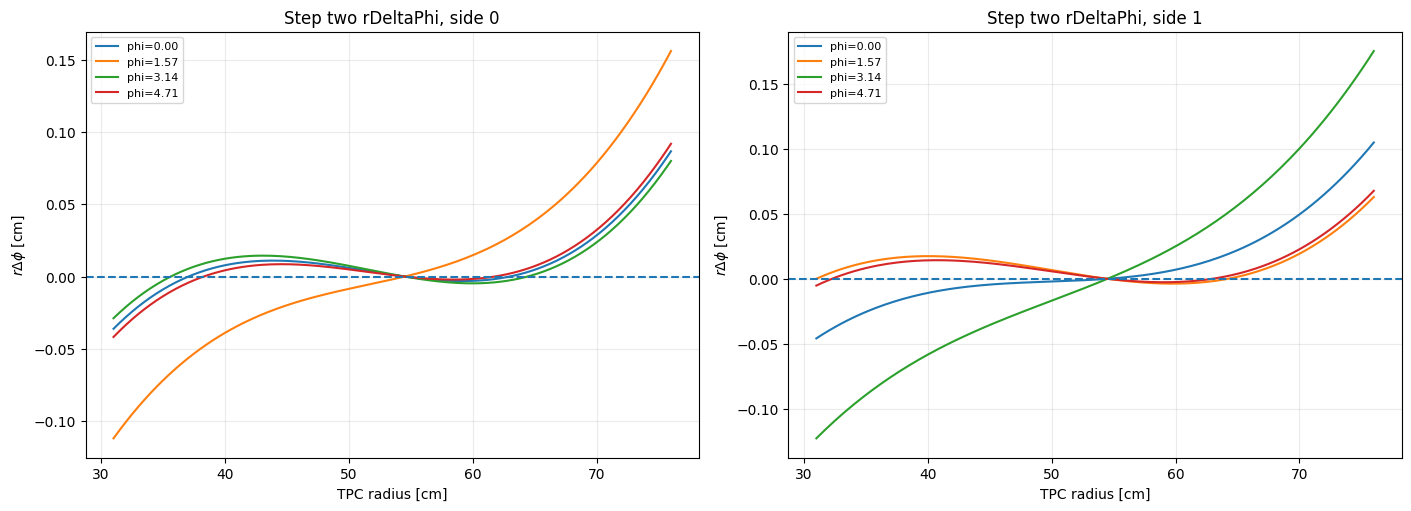

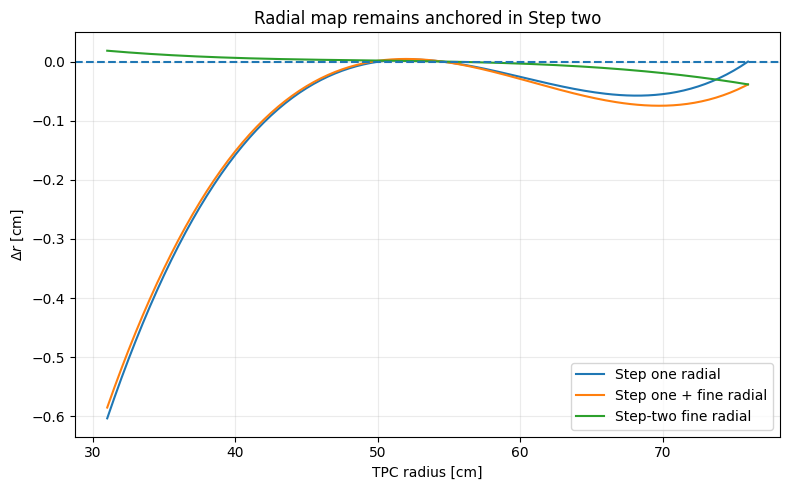

{
  "best_step2_epoch": 29,
  "best_step2_validation_score": 1.2142517566680908,
  "mean_abs_mass_error_step1_mev": 0.4338024827279241,
  "mean_abs_mass_error_step2_mev": 0.1349518642688082,
  "mean_width_ratio_step2_over_step1": 1.0121637911159125,
  "maximum_width_ratio_step2_over_step1": 1.0270332568619371,
  "charge_mean_abs_ratio_error_step1": 0.053973689675331116,
  "charge_mean_abs_ratio_error_step2": 0.052819039672613144,
  "median_circle_rms_ratio_step2_over_step1": 1.0229558944702148,
  "median_additional_momentum_scale": 1.0012333393096924,
  "median_abs_tangent_delta_mrad": 2.041429281234741,
  "maximum_abs_rdelta_phi_cm_on_profile_grid": 0.1751626431941986,
  "maximum_abs_radial_fine_cm_on_profile_grid": 0.0386718213558197,
  "rphi_coefficients_cm": [
    [
      0.005728186573833227,
      0.014363998547196388,
      0.029613852500915527,
      0.024059049785137177,
      -0.005661794450134039,
      0.023129135370254517,
      0.002411228371784091,
      0.02771534025669

In [21]:
# ============================================================
# Step-two map profiles, checkpoint, and compact summary
# ============================================================

radius_grid = np.linspace(31.0, 76.0, 181).astype(np.float32)
phi_profiles = np.array([0.0, 0.5 * np.pi, np.pi, 1.5 * np.pi], dtype=np.float32)
rows = []

step2_model.eval()
with torch.no_grad():
    for side in [0, 1]:
        z_value = -50.0 if side == 0 else 50.0
        for phi_value in phi_profiles:
            r = torch.from_numpy(radius_grid)
            phi = torch.full_like(r, float(phi_value))
            z = torch.full_like(r, z_value)
            side_tensor = torch.full((len(r),), side, dtype=torch.long)
            fine_delta_r, r_delta_phi = step2_model(r[:, None], phi[:, None], z[:, None], side_tensor)
            frozen_delta_r = step1_model(r)

            for rr, dr0, drfine, rdphi in zip(radius_grid, frozen_delta_r.numpy(), fine_delta_r[:, 0].numpy(), r_delta_phi[:, 0].numpy()):
                rows.append({
                    'side': side,
                    'z_cm': z_value,
                    'phi': float(phi_value),
                    'r_cm': float(rr),
                    'step1_delta_r_cm': float(dr0),
                    'step2_fine_delta_r_cm': float(drfine),
                    'total_delta_r_cm': float(dr0 + drfine),
                    'r_delta_phi_cm': float(rdphi),
                })

step2_map_table = pd.DataFrame(rows)
step2_map_table.to_csv(work_dir / 'step2_map_profiles.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
for side, axis in enumerate(axes):
    frame_side = step2_map_table[step2_map_table['side'] == side]
    for phi_value in phi_profiles:
        frame = frame_side[np.isclose(frame_side['phi'], phi_value)]
        axis.plot(frame['r_cm'], frame['r_delta_phi_cm'], label=f'phi={phi_value:.2f}')
    axis.axhline(0.0, linestyle='--')
    axis.set_xlabel('TPC radius [cm]')
    axis.set_ylabel(r'$r\Delta\phi$ [cm]')
    axis.set_title(f'Step two rDeltaPhi, side {side}')
    axis.grid(alpha=0.25)
    axis.legend(fontsize=8)
plt.savefig(work_dir / 'step2_rdelta_phi_profiles.pdf')
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
frame = step2_map_table[(step2_map_table['side'] == 0) & np.isclose(step2_map_table['phi'], 0.0)]
ax.plot(frame['r_cm'], frame['step1_delta_r_cm'], label='Step one radial')
ax.plot(frame['r_cm'], frame['total_delta_r_cm'], label='Step one + fine radial')
ax.plot(frame['r_cm'], frame['step2_fine_delta_r_cm'], label='Step-two fine radial')
ax.axhline(0.0, linestyle='--')
ax.set_xlabel('TPC radius [cm]')
ax.set_ylabel(r'$\Delta r$ [cm]')
ax.set_title('Radial map remains anchored in Step two')
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.savefig(work_dir / 'step2_radial_fine_map.pdf')
plt.show()

torch.save({
    'step1_state_dict': step1_model.state_dict(),
    'step2_state_dict': step2_model.state_dict(),
    'step1_model': 'Delta r = a1*u + a2*u^2 + a3*u^3',
    'step2_basis_names': step2_rphi_basis_names,
    'map_convention': 'corrected_r = measured_r - Delta r; corrected_phi = measured_phi - (rDeltaPhi)/r',
    'step2_direction_correction_strength': step2_direction_correction_strength,
    'step2_allow_radial_fine_tuning': step2_allow_radial_fine_tuning,
}, checkpoint_dir / 'step1_step2_transverse_calibration.pt')

usable = step2_mass_table['neff'] >= pt_mass_scale_minimum_effective_entries

def mean_abs_charge_error(table):
    active = table['active'].to_numpy(bool)
    return float(np.nanmean(np.abs(table.loc[active, 'ratio'] - 1.0)))

summary_step2 = {
    'best_step2_epoch': int(best_step2_epoch),
    'best_step2_validation_score': float(best_step2_score),
    'mean_abs_mass_error_step1_mev': float(np.nanmean(np.abs(step2_mass_table.loc[usable, 'mean_error_step1_mev']))),
    'mean_abs_mass_error_step2_mev': float(np.nanmean(np.abs(step2_mass_table.loc[usable, 'mean_error_step2_mev']))),
    'mean_width_ratio_step2_over_step1': float(np.nanmean(step2_mass_table.loc[usable, 'width_ratio_step2_over_step1'])),
    'maximum_width_ratio_step2_over_step1': float(np.nanmax(step2_mass_table.loc[usable, 'width_ratio_step2_over_step1'])),
    'charge_mean_abs_ratio_error_step1': mean_abs_charge_error(charge_step1),
    'charge_mean_abs_ratio_error_step2': mean_abs_charge_error(charge_step2),
    'median_circle_rms_ratio_step2_over_step1': float(np.nanmedian(circle_ratio)),
    'median_additional_momentum_scale': float(np.nanmedian(additional_scale)),
    'median_abs_tangent_delta_mrad': float(np.nanmedian(np.abs(tangent_delta_mrad))),
    'maximum_abs_rdelta_phi_cm_on_profile_grid': float(np.nanmax(np.abs(step2_map_table['r_delta_phi_cm']))),
    'maximum_abs_radial_fine_cm_on_profile_grid': float(np.nanmax(np.abs(step2_map_table['step2_fine_delta_r_cm']))),
    'rphi_coefficients_cm': step2_model.rphi_coefficients().detach().numpy().tolist(),
    'radial_fine_coefficients_cm': step2_model.radial_fine_coefficients().detach().numpy().tolist(),
}
with open(work_dir / 'step2_summary.json', 'w') as output:
    json.dump(summary_step2, output, indent=2)

print(json.dumps(summary_step2, indent=2))
print('Step one + Step two complete. Delta z remains off.')


## Step two B — width-focused local transverse correction

Step one and Step two A are now frozen. Step two B can only add a local, Fourier-based $r\Delta\phi$ field. It is deliberately unable to repair the width by changing the successful radial calibration.


In [22]:
# ============================================================
# Freeze Step one + Step two A and cache the Step-two-A track reference
# ============================================================

step1_model.eval()
step2_model.eval()
for parameter in step1_model.parameters():
    parameter.requires_grad_(False)
for parameter in step2_model.parameters():
    parameter.requires_grad_(False)

number_of_candidates = len(kshort_arrays['candidate_id'])
all_indices_step2b_reference = np.arange(number_of_candidates, dtype=np.int64)
reference_loader_step2b = DataLoader(
    CandidateDataset(kshort_arrays, all_indices_step2b_reference),
    batch_size=min(step2b_reference_batch_size, number_of_candidates),
    shuffle=False,
    num_workers=0,
)

reference_keys_step2b = [
    'step2a_pt1', 'step2a_pt2',
    'step2a_track_phi1', 'step2a_track_phi2',
    'step2a_circle_radius1', 'step2a_circle_radius2',
    'step2a_effective_abs_bz1', 'step2a_effective_abs_bz2',
    'step2a_circle_rms1', 'step2a_circle_rms2',
    'step2a_circle_tangent_phi1', 'step2a_circle_tangent_phi2',
    'step2a_circle_valid1', 'step2a_circle_valid2',
    'step2a_mass', 'step2a_pt_positive', 'step2a_pt_negative',
]
reference_parts_step2b = {key: [] for key in reference_keys_step2b}

with torch.no_grad():
    for batch in reference_loader_step2b:
        first, second, mass_step2a = correct_batch_step2(step2_model, batch)
        positive_pt = torch.where(batch['charge1'] > 0, first['pt'], second['pt'])
        negative_pt = torch.where(batch['charge1'] < 0, first['pt'], second['pt'])

        values = {
            'step2a_pt1': first['pt'],
            'step2a_pt2': second['pt'],
            'step2a_track_phi1': first['track_phi'],
            'step2a_track_phi2': second['track_phi'],
            'step2a_circle_radius1': first['corrected_circle_radius'],
            'step2a_circle_radius2': second['corrected_circle_radius'],
            'step2a_effective_abs_bz1': first['corrected_effective_abs_bz'],
            'step2a_effective_abs_bz2': second['corrected_effective_abs_bz'],
            'step2a_circle_rms1': first['corrected_circle_rms'],
            'step2a_circle_rms2': second['corrected_circle_rms'],
            'step2a_circle_tangent_phi1': first['corrected_circle_tangent_phi'],
            'step2a_circle_tangent_phi2': second['corrected_circle_tangent_phi'],
            'step2a_circle_valid1': first['circle_valid'],
            'step2a_circle_valid2': second['circle_valid'],
            'step2a_mass': mass_step2a,
            'step2a_pt_positive': positive_pt,
            'step2a_pt_negative': negative_pt,
        }
        for key, value in values.items():
            reference_parts_step2b[key].append(value.detach().cpu().numpy())

for key in reference_keys_step2b:
    kshort_arrays[key] = np.concatenate(reference_parts_step2b[key])

step2b_reference_valid = kshort_arrays['step2a_circle_valid1'].astype(bool) & kshort_arrays['step2a_circle_valid2'].astype(bool)
print('Candidates with valid frozen Step-two-A reference circles:', int(step2b_reference_valid.sum()), '/', len(step2b_reference_valid))
print('Step-two-A mean mass:', float(np.nanmean(kshort_arrays['step2a_mass'])))


Candidates with valid frozen Step-two-A reference circles: 41643 / 41643
Step-two-A mean mass: 0.4966442883014679


In [23]:
# ============================================================
# Step-two-B local zero-mean rDeltaPhi model
# ============================================================

step2b_basis_names = []
step2b_basis_orders = []
for harmonic in step2b_harmonic_orders:
    for prefix in ['', 'u*', 'v*']:
        step2b_basis_names.extend([f'{prefix}sin({harmonic}phi)', f'{prefix}cos({harmonic}phi)'])
        step2b_basis_orders.extend([harmonic, harmonic])
step2b_basis_orders = np.asarray(step2b_basis_orders, dtype=np.float32)


class StepTwoBLocalRPhiModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.raw_coefficients = nn.Parameter(torch.zeros(2, len(step2b_basis_names), dtype=torch.float32))
        self.register_buffer('basis_orders', torch.tensor(step2b_basis_orders, dtype=torch.float32))

    def coefficients(self):
        return step2b_rphi_coefficient_bound_cm * torch.tanh(self.raw_coefficients)

    def basis(self, r, phi, z):
        u = (r - step1_pivot_r_cm) / step1_radial_scale_cm
        v = z / 102.325
        pieces = []
        for harmonic in step2b_harmonic_orders:
            sin_n = torch.sin(float(harmonic) * phi)
            cos_n = torch.cos(float(harmonic) * phi)
            pieces.extend([sin_n, cos_n, u * sin_n, u * cos_n, v * sin_n, v * cos_n])
        return torch.stack(pieces, dim=-1)

    def forward(self, r, phi, z, side):
        basis = self.basis(r, phi, z)
        coefficients = self.coefficients()[side.to(torch.long)]
        extra_r_delta_phi = torch.sum(basis * coefficients[:, None, :], dim=-1)
        return torch.clamp(
            extra_r_delta_phi,
            -step2b_max_abs_extra_rdelta_phi_cm,
            step2b_max_abs_extra_rdelta_phi_cm,
        )


def refit_track_step2b(
    model, r, phi, z, mask, side,
    original_eta, raw_field, raw_gradient,
    step2a_pt, step2a_track_phi, step2a_radius, step2a_bz,
    step2a_rms, step2a_tangent_phi, step2a_valid,
):
    raw_position = raw_position_from_cylindrical(r, phi, z)

    with torch.no_grad():
        frozen_step1_delta_r = step1_model(r)
        frozen_step2a_fine_delta_r, frozen_step2a_r_delta_phi = step2_model(r, phi, z, side)

    extra_r_delta_phi = model(r, phi, z, side)
    total_delta_r = frozen_step1_delta_r + frozen_step2a_fine_delta_r
    total_r_delta_phi = frozen_step2a_r_delta_phi + extra_r_delta_phi

    corrected_r = r - total_delta_r * mask
    corrected_phi_cluster = phi - (total_r_delta_phi / torch.clamp(r, min=1.0e-6)) * mask
    corrected_position = raw_position_from_cylindrical(corrected_r, corrected_phi_cluster, z)
    corrected_field = corrected_field_from_raw(raw_position, corrected_position, raw_field, raw_gradient)

    corrected_radius, corrected_rms, corrected_tangent_phi, corrected_valid = fit_circle_xy_with_tangent(corrected_position, mask)
    corrected_bz = effective_abs_bz(corrected_position, corrected_field, mask)

    additional_scale = (corrected_radius * corrected_bz) / torch.clamp(step2a_radius * step2a_bz, min=1.0e-6)
    valid = step2a_valid.to(torch.bool) & corrected_valid & torch.isfinite(additional_scale)
    additional_scale = torch.where(valid, additional_scale, torch.ones_like(additional_scale))
    additional_scale = torch.clamp(
        additional_scale,
        min=step2b_minimum_additional_refit_scale,
        max=step2b_maximum_additional_refit_scale,
    )

    tangent_delta = wrapped_delta_phi(corrected_tangent_phi, step2a_tangent_phi)
    tangent_delta = torch.where(valid, tangent_delta, torch.zeros_like(tangent_delta))
    corrected_track_phi = step2a_track_phi + step2b_direction_correction_strength * tangent_delta
    corrected_pt = step2a_pt * additional_scale

    corrected_momentum = torch.stack([
        corrected_pt * torch.cos(corrected_track_phi),
        corrected_pt * torch.sin(corrected_track_phi),
        corrected_pt * torch.sinh(original_eta),
    ], dim=1)

    return {
        'momentum': corrected_momentum,
        'pt': corrected_pt,
        'track_phi': corrected_track_phi,
        'additional_momentum_scale': additional_scale,
        'tangent_delta': tangent_delta,
        'circle_valid': valid,
        'step2a_circle_rms': step2a_rms,
        'corrected_circle_rms': corrected_rms,
        'step2a_circle_radius': step2a_radius,
        'corrected_circle_radius': corrected_radius,
        'extra_r_delta_phi': extra_r_delta_phi,
        'total_r_delta_phi': total_r_delta_phi,
        'total_delta_r': total_delta_r,
    }


def correct_batch_step2b(model, batch):
    field1, gradient1 = track_field_tensors(batch, '1')
    field2, gradient2 = track_field_tensors(batch, '2')

    first = refit_track_step2b(
        model, batch['r1'], batch['phi_cluster1'], batch['z_cluster1'], batch['mask1'], batch['side1'],
        batch['eta1'], field1, gradient1,
        batch['step2a_pt1'], batch['step2a_track_phi1'], batch['step2a_circle_radius1'], batch['step2a_effective_abs_bz1'],
        batch['step2a_circle_rms1'], batch['step2a_circle_tangent_phi1'], batch['step2a_circle_valid1'],
    )
    second = refit_track_step2b(
        model, batch['r2'], batch['phi_cluster2'], batch['z_cluster2'], batch['mask2'], batch['side2'],
        batch['eta2'], field2, gradient2,
        batch['step2a_pt2'], batch['step2a_track_phi2'], batch['step2a_circle_radius2'], batch['step2a_effective_abs_bz2'],
        batch['step2a_circle_rms2'], batch['step2a_circle_tangent_phi2'], batch['step2a_circle_valid2'],
    )
    corrected_mass = invariant_mass(first['momentum'], second['momentum'], pion_mass, pion_mass)
    return first, second, corrected_mass


step2b_model = StepTwoBLocalRPhiModel()
print('Step-two-B trainable coefficients:', step2b_model.raw_coefficients.numel())


Step-two-B trainable coefficients: 144


In [24]:
# ============================================================
# Step-two-B robust width objective and protection guards
# ============================================================

def step2b_fixed_core_weights(batch):
    gaussian_core = torch.exp(-0.5 * ((batch['step2a_mass'] - pdg_kshort_mass) / step2b_core_sigma_gev) ** 2)
    return batch['pair_weight'] * batch['mass_core_weight'] * gaussian_core.detach()


def step2b_charge_balance_loss(first, second, batch):
    weights = step2b_fixed_core_weights(batch)
    positive_pt = torch.where(batch['charge1'] > 0, first['pt'], second['pt'])
    negative_pt = torch.where(batch['charge1'] < 0, first['pt'], second['pt'])

    centers, plus, plus2 = soft_histogram_counts_and_squares(
        positive_pt, weights, charge_balance_pt_minimum_gev, charge_balance_pt_maximum_gev, charge_balance_number_of_bins
    )
    _, minus, minus2 = soft_histogram_counts_and_squares(
        negative_pt, weights, charge_balance_pt_minimum_gev, charge_balance_pt_maximum_gev, charge_balance_number_of_bins
    )

    neff_plus = plus ** 2 / torch.clamp(plus2, min=1.0e-12)
    neff_minus = minus ** 2 / torch.clamp(minus2, min=1.0e-12)
    active = (neff_plus >= step2_charge_minimum_bin_effective_entries) & (neff_minus >= step2_charge_minimum_bin_effective_entries)

    log_ratio = torch.log(torch.clamp(plus, min=1.0e-8) / torch.clamp(minus, min=1.0e-8))
    variance = 1.0 / torch.clamp(neff_plus, min=1.0) + 1.0 / torch.clamp(neff_minus, min=1.0)
    variance = variance + step2_charge_systematic_floor_fraction ** 2

    priority = torch.clamp(
        (centers / step2_charge_pt_priority_reference_gev) ** step2_charge_pt_priority_power,
        max=step2_charge_maximum_priority,
    )
    bin_weight = active.to(log_ratio.dtype) * priority / torch.clamp(variance, min=1.0e-8)
    return torch.sum(bin_weight * log_ratio ** 2) / torch.clamp(bin_weight.sum(), min=1.0)


def step2b_mass_width_terms(corrected_mass, batch):
    weights_all = step2b_fixed_core_weights(batch)
    width_losses, shift_guards, absolute_guards, active_weights, corrected_errors = [], [], [], [], []

    for lower, upper in zip(pt_mass_scale_bin_edges[:-1], pt_mass_scale_bin_edges[1:]):
        selected = (batch['pair_pt'] >= float(lower)) & (batch['pair_pt'] < float(upper))
        weights = weights_all * selected.to(weights_all.dtype)

        corrected_mean, corrected_variance, neff = torch_weighted_mean_variance(corrected_mass, weights)
        step2a_mean, step2a_variance, _ = torch_weighted_mean_variance(batch['step2a_mass'], weights)
        active = (neff >= pt_mass_scale_minimum_effective_entries).to(corrected_mass.dtype)

        width_ratio2 = corrected_variance / torch.clamp(step2a_variance, min=1.0e-8)
        mean_shift = torch.abs(corrected_mean - step2a_mean)
        absolute_error = torch.abs(corrected_mean - pdg_kshort_mass)

        shift_guard = (
            torch.relu(mean_shift - step2b_mass_shift_tolerance_gev)
            / step2b_mass_guard_scale_gev
        ) ** 2
        absolute_guard = (
            torch.relu(absolute_error - step2b_mass_absolute_tolerance_gev)
            / step2b_mass_guard_scale_gev
        ) ** 2

        width_losses.append(width_ratio2)
        shift_guards.append(shift_guard)
        absolute_guards.append(absolute_guard)
        active_weights.append(active)
        corrected_errors.append(corrected_mean - pdg_kshort_mass)

    width_losses = torch.stack(width_losses)
    shift_guards = torch.stack(shift_guards)
    absolute_guards = torch.stack(absolute_guards)
    active_weights = torch.stack(active_weights)
    corrected_errors = torch.stack(corrected_errors)
    normalization = torch.clamp(active_weights.sum(), min=1.0)

    width = torch.sum(active_weights * width_losses) / normalization
    mass_guard = torch.sum(active_weights * (shift_guards + absolute_guards)) / normalization

    mean_error = torch.sum(active_weights * corrected_errors) / normalization
    flatness_rms = torch.sqrt(
        torch.sum(active_weights * (corrected_errors - mean_error) ** 2) / normalization
        + 1.0e-12
    )
    flatness_guard = (
        torch.relu(flatness_rms - step2b_flatness_tolerance_gev)
        / step2b_mass_guard_scale_gev
    ) ** 2

    inclusive_mean, _, _ = torch_weighted_mean_variance(corrected_mass, weights_all)
    step2a_inclusive_mean, _, _ = torch_weighted_mean_variance(batch['step2a_mass'], weights_all)
    inclusive_shift = torch.abs(inclusive_mean - step2a_inclusive_mean)
    inclusive_guard = (
        torch.relu(inclusive_shift - step2b_inclusive_mass_tolerance_gev)
        / step2b_mass_guard_scale_gev
    ) ** 2
    return width, mass_guard, flatness_guard, inclusive_guard


def step2b_circle_guard(first, second):
    guards = []
    for track in [first, second]:
        ratio = track['corrected_circle_rms'] / torch.clamp(track['step2a_circle_rms'], min=1.0e-6)
        valid = track['circle_valid'].to(ratio.dtype)
        excess = torch.relu(ratio - step2b_max_preferred_circle_rms_ratio) / 0.05
        guards.append(torch.sum(valid * excess ** 2) / torch.clamp(valid.sum(), min=1.0))
    return 0.5 * (guards[0] + guards[1])


def step2b_map_regularization(model):
    coefficients = model.coefficients()
    amplitude = torch.mean((coefficients / 0.08) ** 2)
    harmonic_weight = (model.basis_orders / float(max(step2b_harmonic_orders))) ** 2
    harmonic_weight = harmonic_weight[None, :]
    high_harmonic = torch.mean((coefficients / 0.08) ** 2 * harmonic_weight)
    return amplitude, high_harmonic


def step2b_batch_loss(model, batch):
    first, second, corrected_mass = correct_batch_step2b(model, batch)
    width, mass_guard, flatness_guard, inclusive_guard = step2b_mass_width_terms(corrected_mass, batch)
    charge = step2b_charge_balance_loss(first, second, batch)
    circle_guard = step2b_circle_guard(first, second)
    amplitude, high_harmonic = step2b_map_regularization(model)

    total = (
        step2b_width_weight * width
        + step2b_charge_balance_weight * charge
        + step2b_mass_guard_weight * mass_guard
        + step2b_flatness_guard_weight * flatness_guard
        + step2b_inclusive_mass_guard_weight * inclusive_guard
        + step2b_circle_guard_weight * circle_guard
        + step2b_amplitude_regularization_weight * amplitude
        + step2b_high_harmonic_regularization_weight * high_harmonic
    )
    terms = {
        'width': width,
        'charge': charge,
        'mass_guard': mass_guard,
        'flatness_guard': flatness_guard,
        'inclusive_guard': inclusive_guard,
        'circle_guard': circle_guard,
        'amplitude': amplitude,
        'high_harmonic': high_harmonic,
    }
    return total, terms


Step-two-B balanced fit candidates: 10800
Step-two-B balanced validation candidates: 6000


,pt_low,pt_high,candidates
0,0.5,0.8,1800
1,0.8,1.1,1800
2,1.1,1.4,1800
3,1.4,1.8,1800
4,1.8,2.2,1800
5,2.2,3.0,1800


Step-two-B zero-map max |mass-Step2A mass|: 0.0
Step-two-B zero-map max |additional scale-1|: 0.0
Step-two-B zero-map max |tangent delta|: 0.0
epoch 00: validation=10.1174 width=0.9971 mass_guard=0.1439 charge=0.0082 coef_rms=0.0004 cm
epoch 02: validation=10.0881 width=0.9928 mass_guard=0.1574 charge=0.0083 coef_rms=0.0011 cm
epoch 04: validation=10.0616 width=0.9893 mass_guard=0.1660 charge=0.0084 coef_rms=0.0018 cm
epoch 06: validation=10.0288 width=0.9862 mass_guard=0.1642 charge=0.0084 coef_rms=0.0025 cm
epoch 08: validation=10.0046 width=0.9836 mass_guard=0.1662 charge=0.0084 coef_rms=0.0031 cm
epoch 10: validation=9.9783 width=0.9810 mass_guard=0.1654 charge=0.0085 coef_rms=0.0037 cm
epoch 12: validation=9.9566 width=0.9792 mass_guard=0.1618 charge=0.0085 coef_rms=0.0043 cm
epoch 14: validation=9.9357 width=0.9778 mass_guard=0.1554 charge=0.0085 coef_rms=0.0048 cm
epoch 16: validation=9.9191 width=0.9766 mass_guard=0.1503 charge=0.0086 coef_rms=0.0053 cm
epoch 18: validation=9.9

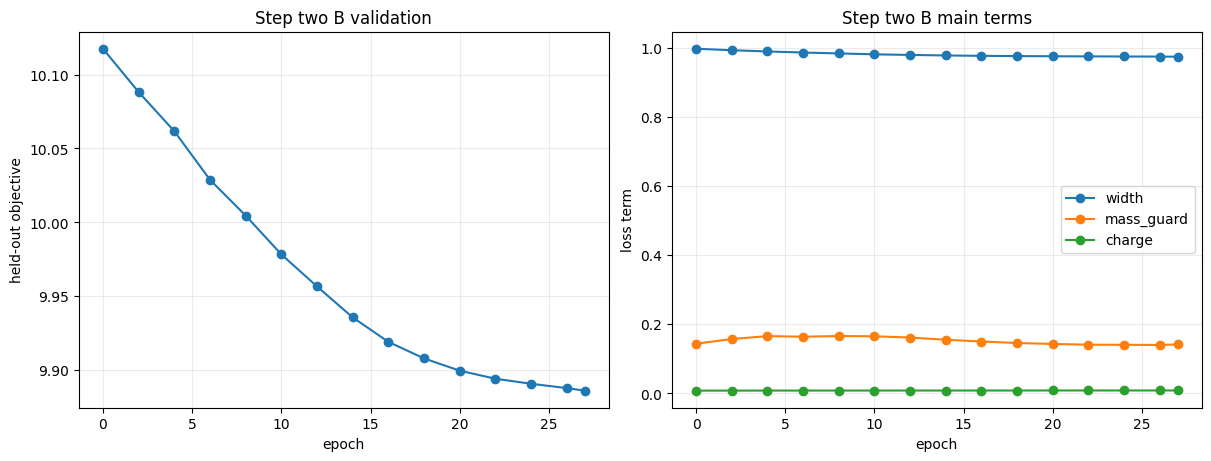

Best Step-two-B epoch: 27
Best Step-two-B validation score: 9.886157035827637


In [25]:
# ============================================================
# Step-two-B balanced split, zero-map identity, and fit
# ============================================================

step2b_training_indices = np.flatnonzero(
    (kshort_arrays['event_parity'].astype(np.int64) == training_parity) & step2b_reference_valid
)
step2b_validation_indices = np.flatnonzero(
    (kshort_arrays['event_parity'].astype(np.int64) == validation_parity) & step2b_reference_valid
)
step2b_fit_indices = stratified_indices_by_pt(
    step2b_training_indices, kshort_arrays['pair_pt'], pt_mass_scale_bin_edges,
    step2b_fit_candidates_per_pt_bin, seed + 3100,
)
step2b_validation_fit_indices = stratified_indices_by_pt(
    step2b_validation_indices, kshort_arrays['pair_pt'], pt_mass_scale_bin_edges,
    step2b_validation_candidates_per_pt_bin, seed + 3200,
)

print('Step-two-B balanced fit candidates:', len(step2b_fit_indices))
print('Step-two-B balanced validation candidates:', len(step2b_validation_fit_indices))
display(pt_bin_counts(step2b_fit_indices, kshort_arrays['pair_pt'], pt_mass_scale_bin_edges))

fit_dataset_step2b = CandidateDataset(kshort_arrays, step2b_fit_indices)
validation_dataset_step2b = CandidateDataset(kshort_arrays, step2b_validation_fit_indices)
if step2b_batch_size < len(fit_dataset_step2b):
    raise ValueError(f'step2b_batch_size={step2b_batch_size} < balanced fit sample {len(fit_dataset_step2b)}')
if step2b_validation_batch_size < len(validation_dataset_step2b):
    raise ValueError(f'step2b_validation_batch_size={step2b_validation_batch_size} < balanced validation sample {len(validation_dataset_step2b)}')

fit_batch_step2b = next(iter(DataLoader(
    fit_dataset_step2b, batch_size=len(fit_dataset_step2b), shuffle=False, num_workers=0
)))
validation_batch_step2b = next(iter(DataLoader(
    validation_dataset_step2b, batch_size=len(validation_dataset_step2b), shuffle=False, num_workers=0
)))

step2b_model.eval()
with torch.no_grad():
    first_zero, second_zero, mass_zero = correct_batch_step2b(step2b_model, validation_batch_step2b)
zero_mass_difference = float(torch.max(torch.abs(mass_zero - validation_batch_step2b['step2a_mass'])))
zero_scale_difference = max(
    float(torch.max(torch.abs(first_zero['additional_momentum_scale'] - 1.0))),
    float(torch.max(torch.abs(second_zero['additional_momentum_scale'] - 1.0))),
)
zero_tangent_difference = max(
    float(torch.max(torch.abs(first_zero['tangent_delta']))),
    float(torch.max(torch.abs(second_zero['tangent_delta']))),
)
print('Step-two-B zero-map max |mass-Step2A mass|:', zero_mass_difference)
print('Step-two-B zero-map max |additional scale-1|:', zero_scale_difference)
print('Step-two-B zero-map max |tangent delta|:', zero_tangent_difference)
if zero_mass_difference > 3.0e-5 or zero_scale_difference > 3.0e-5 or zero_tangent_difference > 3.0e-5:
    raise RuntimeError('Step-two-B response fails the exact Step-two-A identity check.')

step2b_history = []
best_step2b_score = np.inf
best_step2b_state = copy.deepcopy(step2b_model.state_dict())
best_step2b_epoch = -1
stale_step2b_checks = 0

if run_step_two_b:
    optimizer = torch.optim.Adam(step2b_model.parameters(), lr=step2b_learning_rate)

    for epoch in range(step2b_fit_epochs):
        step2b_model.train()
        optimizer.zero_grad(set_to_none=True)
        total, terms = step2b_batch_loss(step2b_model, fit_batch_step2b)
        total.backward()
        torch.nn.utils.clip_grad_norm_(step2b_model.parameters(), step2b_gradient_clip_norm)
        optimizer.step()

        row = {'epoch': epoch, 'training_total': float(total.detach())}
        row.update({key: float(value.detach()) for key, value in terms.items()})

        do_validation = (epoch % step2b_validation_interval == 0) or (epoch == step2b_fit_epochs - 1)
        if do_validation:
            step2b_model.eval()
            with torch.no_grad():
                validation_total, validation_terms = step2b_batch_loss(step2b_model, validation_batch_step2b)

            validation_score = float(validation_total)
            row['validation_score'] = validation_score
            row.update({f'validation_{key}': float(value) for key, value in validation_terms.items()})
            coefficient_rms = float(torch.sqrt(torch.mean(step2b_model.coefficients() ** 2)))

            print(
                f'epoch {epoch:02d}: validation={validation_score:.4f} '
                f'width={float(validation_terms["width"]):.4f} '
                f'mass_guard={float(validation_terms["mass_guard"]):.4f} '
                f'charge={float(validation_terms["charge"]):.4f} '
                f'coef_rms={coefficient_rms:.4f} cm'
            )

            if validation_score < best_step2b_score - step2b_minimum_improvement:
                best_step2b_score = validation_score
                best_step2b_state = copy.deepcopy(step2b_model.state_dict())
                best_step2b_epoch = epoch
                stale_step2b_checks = 0
            else:
                stale_step2b_checks += 1
                if stale_step2b_checks >= step2b_patience:
                    step2b_history.append(row)
                    print('Early stop: held-out Step-two-B objective stopped improving.')
                    break
        else:
            row['validation_score'] = np.nan

        step2b_history.append(row)

    step2b_model.load_state_dict(best_step2b_state)

step2b_history = pd.DataFrame(step2b_history)
if not step2b_history.empty:
    step2b_history.to_csv(work_dir / 'step2b_training_history.csv', index=False)
    valid = step2b_history[np.isfinite(step2b_history['validation_score'])]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
    axes[0].plot(valid['epoch'], valid['validation_score'], marker='o')
    axes[0].set_xlabel('epoch')
    axes[0].set_ylabel('held-out objective')
    axes[0].set_title('Step two B validation')
    axes[0].grid(alpha=0.25)

    for name in ['validation_width', 'validation_mass_guard', 'validation_charge']:
        if name in valid:
            axes[1].plot(valid['epoch'], valid[name], marker='o', label=name.replace('validation_', ''))
    axes[1].set_xlabel('epoch')
    axes[1].set_ylabel('loss term')
    axes[1].set_title('Step two B main terms')
    axes[1].grid(alpha=0.25)
    axes[1].legend()
    plt.show()

print('Best Step-two-B epoch:', best_step2b_epoch)
print('Best Step-two-B validation score:', best_step2b_score)


,pt_low,pt_high,entries,neff,mean_error_step2a_mev,mean_error_step2b_mev,width_step1_mev,width_step2a_mev,width_step2b_mev,width_ratio_step2b_over_step2a,robust_width_step2a_mev,robust_width_step2b_mev,robust_width_ratio_step2b_over_step2a
0,0.5,0.8,1863,1469.024650,-0.191650,-0.320977,5.142928,5.172762,5.071489,0.980422,4.158128,4.099822,0.985978
1,0.8,1.1,2527,2026.508144,-0.000634,-0.071740,6.026670,6.052884,5.921177,0.978240,4.541623,4.460397,0.982115
2,1.1,1.4,3244,2501.473364,0.027265,0.059323,6.569515,6.673461,6.497975,0.973704,4.879316,4.781804,0.980015
3,1.4,1.8,5140,3901.665566,-0.316427,-0.311594,7.834634,7.893055,7.735122,0.979991,5.261377,5.196506,0.987670
4,1.8,2.2,4199,3155.119679,0.102674,0.092068,9.588912,9.708960,9.561192,0.984780,5.609910,5.572741,0.993374
5,2.2,3.0,3138,2265.513568,0.171063,0.230171,10.199250,10.474970,10.366895,0.989683,5.890601,5.888722,0.999681


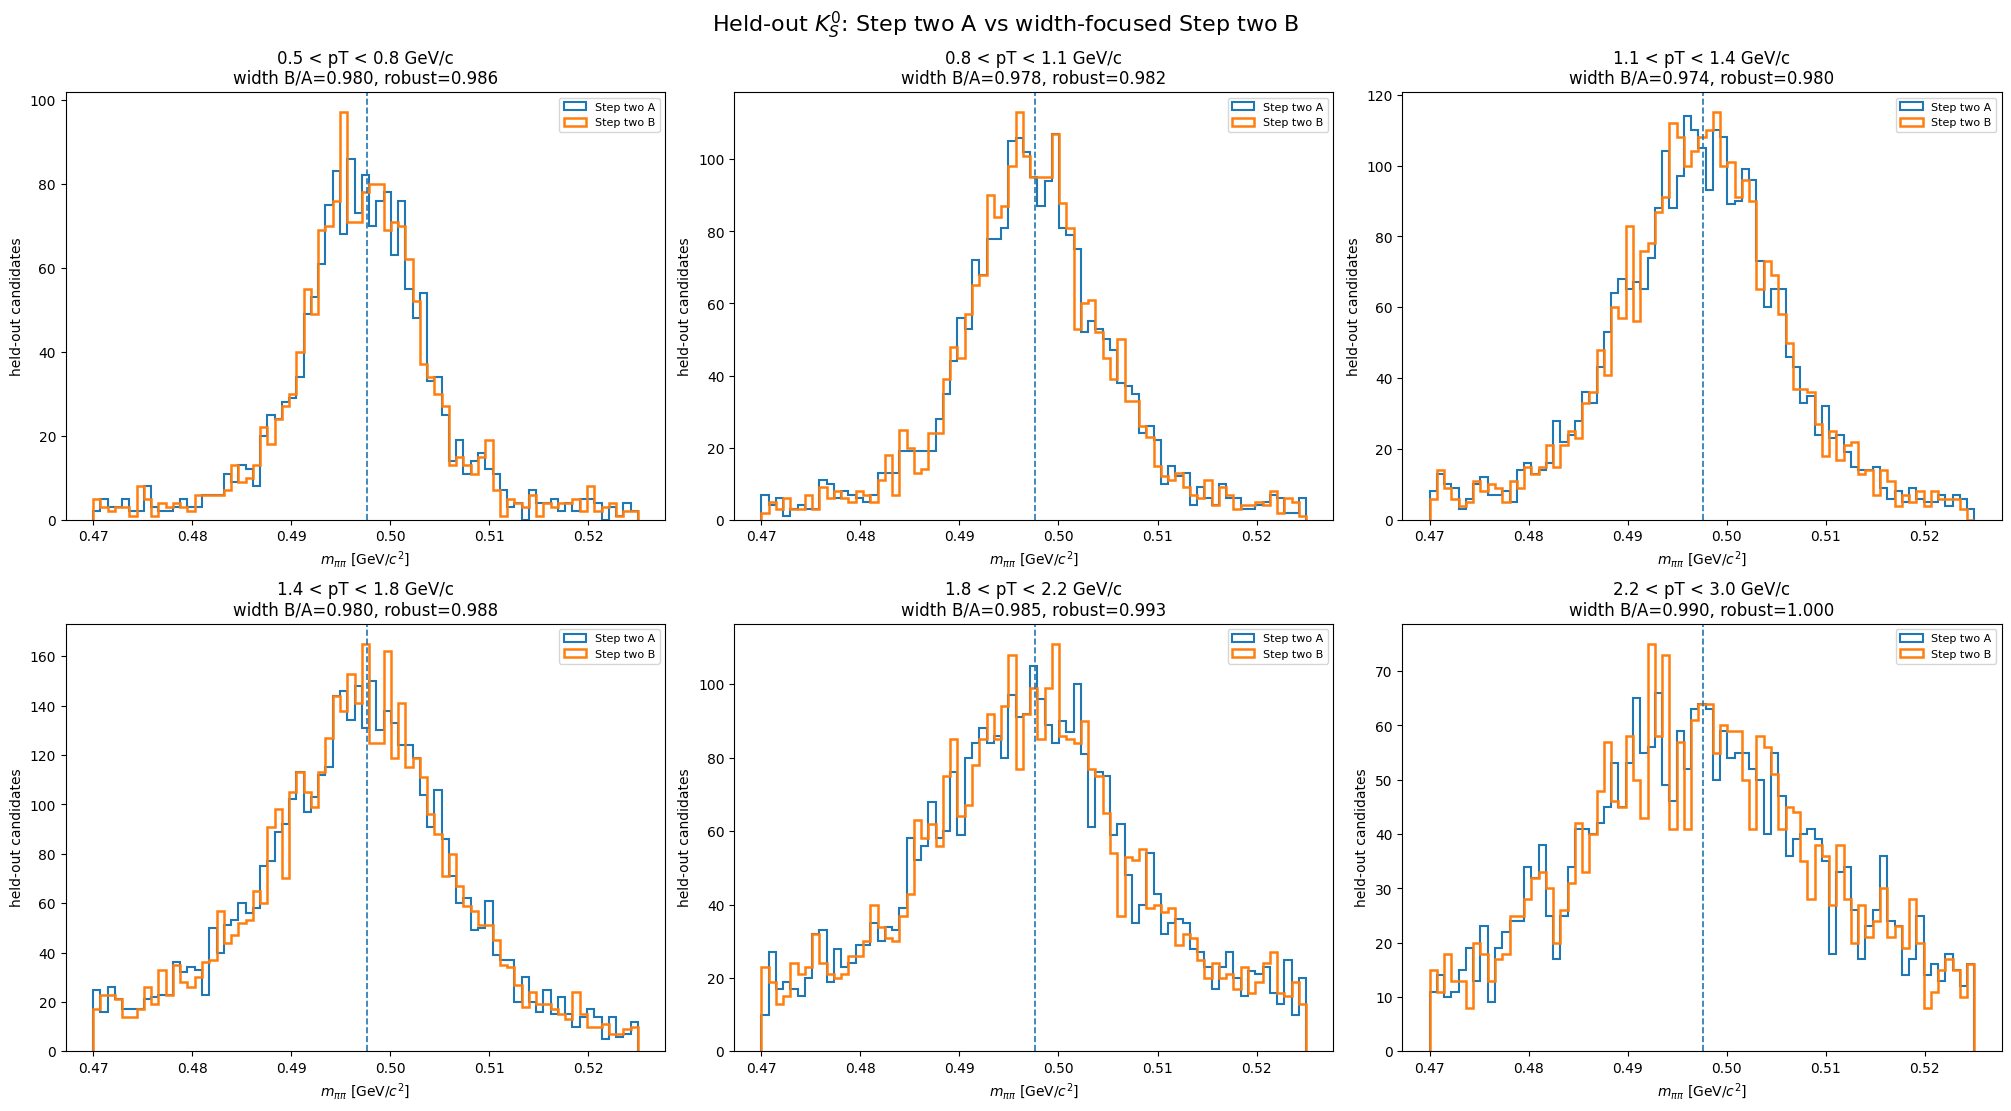

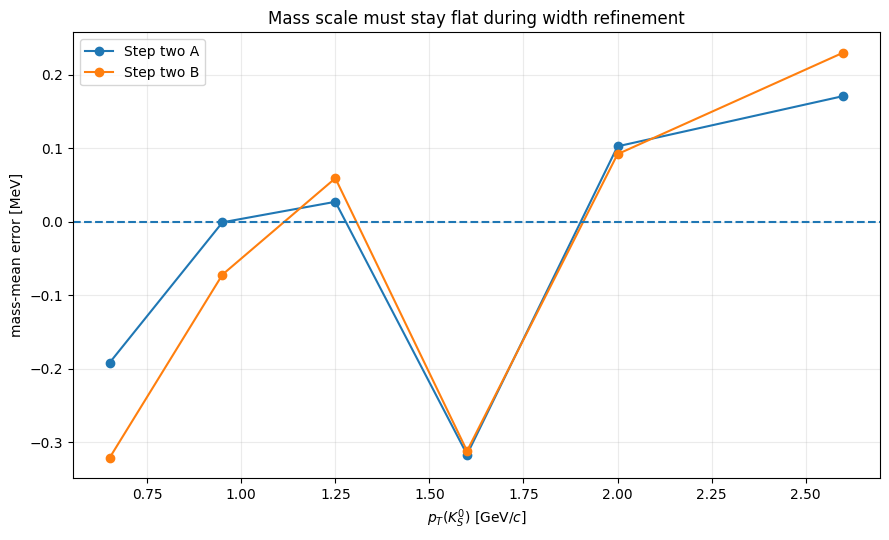

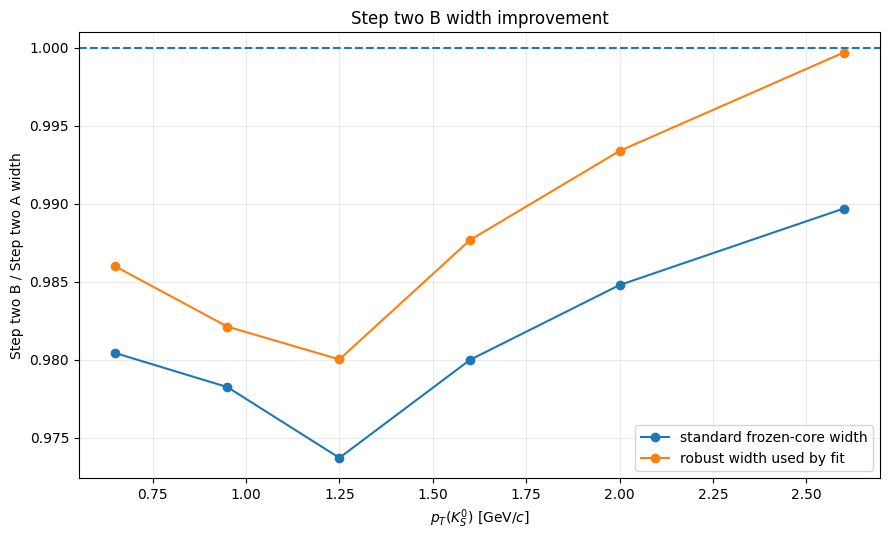

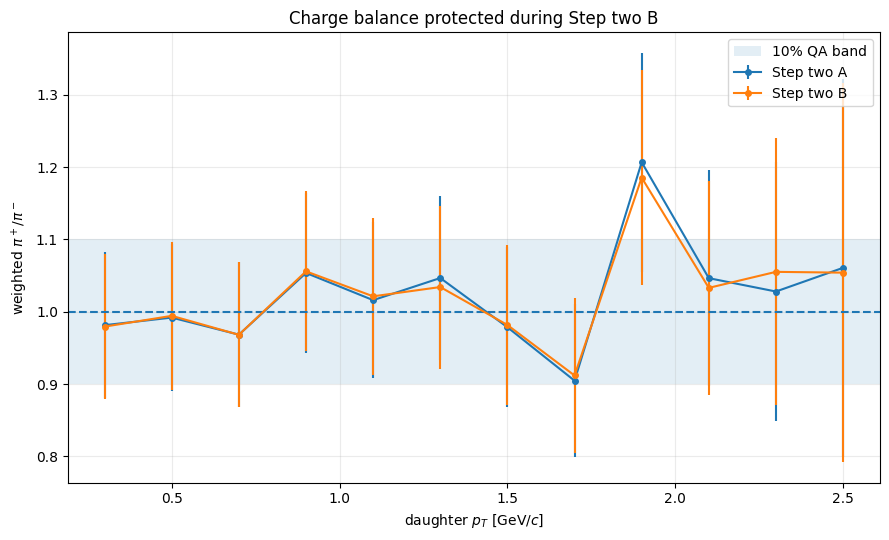

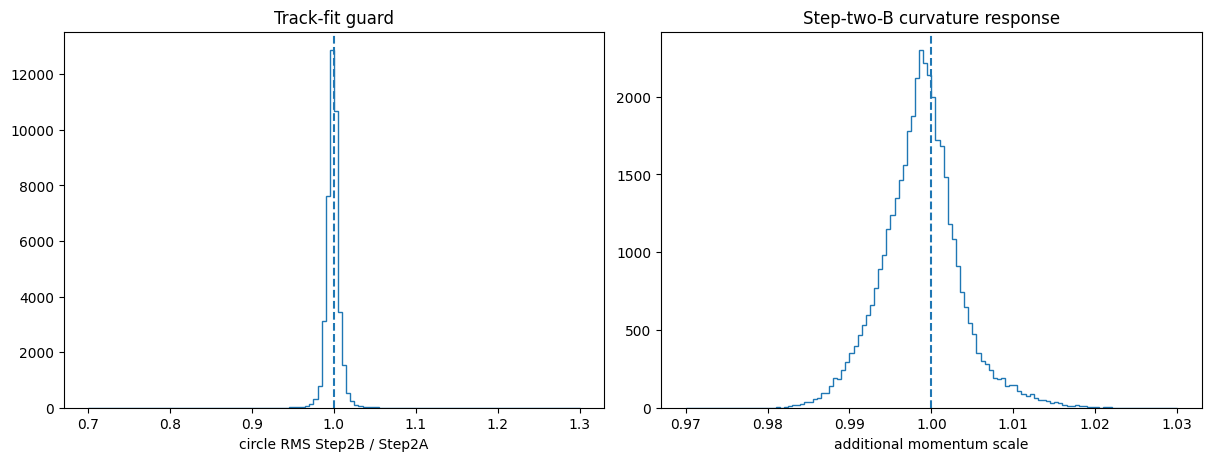

In [26]:
# ============================================================
# Held-out Step-two-B QA: input -> Step one -> Step two A -> Step two B
# ============================================================

def evaluate_step2b(model, arrays, indices, batch_size=None):
    batch_size = batch_size or step2b_validation_batch_size
    loader = DataLoader(
        CandidateDataset(arrays, indices),
        batch_size=min(batch_size, len(indices)),
        shuffle=False,
        num_workers=0,
    )
    keys = [
        'mass_input', 'mass_step1', 'mass_step2a', 'mass_step2b',
        'pair_pt', 'pair_weight', 'mass_core_weight',
        'pt_positive_step2a', 'pt_negative_step2a', 'pt_positive_step2b', 'pt_negative_step2b',
        'additional_scale1', 'additional_scale2', 'circle_rms_ratio1', 'circle_rms_ratio2',
    ]
    collected = {key: [] for key in keys}

    model.eval()
    with torch.no_grad():
        for batch in loader:
            first, second, mass_step2b = correct_batch_step2b(model, batch)
            positive_step2b = torch.where(batch['charge1'] > 0, first['pt'], second['pt'])
            negative_step2b = torch.where(batch['charge1'] < 0, first['pt'], second['pt'])

            values = {
                'mass_input': batch['baseline_mass'],
                'mass_step1': batch['step1_mass'],
                'mass_step2a': batch['step2a_mass'],
                'mass_step2b': mass_step2b,
                'pair_pt': batch['pair_pt'],
                'pair_weight': batch['pair_weight'],
                'mass_core_weight': batch['mass_core_weight'],
                'pt_positive_step2a': batch['step2a_pt_positive'],
                'pt_negative_step2a': batch['step2a_pt_negative'],
                'pt_positive_step2b': positive_step2b,
                'pt_negative_step2b': negative_step2b,
                'additional_scale1': first['additional_momentum_scale'],
                'additional_scale2': second['additional_momentum_scale'],
                'circle_rms_ratio1': first['corrected_circle_rms'] / torch.clamp(first['step2a_circle_rms'], min=1.0e-6),
                'circle_rms_ratio2': second['corrected_circle_rms'] / torch.clamp(second['step2a_circle_rms'], min=1.0e-6),
            }
            for key, value in values.items():
                collected[key].append(value.detach().cpu().numpy())
    return {key: np.concatenate(parts) for key, parts in collected.items()}


step2b_validation = evaluate_step2b(step2b_model, kshort_arrays, step2b_validation_indices)
standard_weights = step2b_validation['pair_weight'] * step2b_validation['mass_core_weight']
robust_weights = standard_weights * np.exp(
    -0.5 * ((step2b_validation['mass_step2a'] - pdg_kshort_mass) / step2b_core_sigma_gev) ** 2
)

rows = []
for lower, upper in zip(pt_mass_scale_bin_edges[:-1], pt_mass_scale_bin_edges[1:]):
    selected = (step2b_validation['pair_pt'] >= lower) & (step2b_validation['pair_pt'] < upper)

    input_peak = peak_metrics(step2b_validation['mass_input'][selected], standard_weights[selected])
    step1_peak = peak_metrics(step2b_validation['mass_step1'][selected], standard_weights[selected])
    step2a_peak = peak_metrics(step2b_validation['mass_step2a'][selected], standard_weights[selected])
    step2b_peak = peak_metrics(step2b_validation['mass_step2b'][selected], standard_weights[selected])
    step2a_core = peak_metrics(step2b_validation['mass_step2a'][selected], robust_weights[selected])
    step2b_core = peak_metrics(step2b_validation['mass_step2b'][selected], robust_weights[selected])

    rows.append({
        'pt_low': float(lower),
        'pt_high': float(upper),
        'entries': int(selected.sum()),
        'neff': step2b_peak['neff'],
        'mean_error_step2a_mev': 1000.0 * (step2a_peak['mean'] - pdg_kshort_mass),
        'mean_error_step2b_mev': 1000.0 * (step2b_peak['mean'] - pdg_kshort_mass),
        'width_step1_mev': 1000.0 * step1_peak['width'],
        'width_step2a_mev': 1000.0 * step2a_peak['width'],
        'width_step2b_mev': 1000.0 * step2b_peak['width'],
        'width_ratio_step2b_over_step2a': step2b_peak['width'] / max(step2a_peak['width'], 1.0e-12),
        'robust_width_step2a_mev': 1000.0 * step2a_core['width'],
        'robust_width_step2b_mev': 1000.0 * step2b_core['width'],
        'robust_width_ratio_step2b_over_step2a': step2b_core['width'] / max(step2a_core['width'], 1.0e-12),
    })

step2b_mass_table = pd.DataFrame(rows)
step2b_mass_table.to_csv(work_dir / 'step2b_kshort_mass_vs_pt.csv', index=False)
display(step2b_mass_table)

figure, axes = plt.subplots(2, 3, figsize=(20, 11), constrained_layout=True)
for axis, row in zip(axes.ravel(), step2b_mass_table.itertuples(index=False)):
    selected = (step2b_validation['pair_pt'] >= row.pt_low) & (step2b_validation['pair_pt'] < row.pt_high)
    axis.hist(step2b_validation['mass_step2a'][selected], bins=75, range=(0.47, 0.525), histtype='step', linewidth=1.5, label='Step two A')
    axis.hist(step2b_validation['mass_step2b'][selected], bins=75, range=(0.47, 0.525), histtype='step', linewidth=1.8, label='Step two B')
    axis.axvline(pdg_kshort_mass, linestyle='--', linewidth=1.2)
    axis.set_title(
        f'{row.pt_low:.1f} < pT < {row.pt_high:.1f} GeV/c\n'
        f'width B/A={row.width_ratio_step2b_over_step2a:.3f}, '
        f'robust={row.robust_width_ratio_step2b_over_step2a:.3f}'
    )
    axis.set_xlabel(r'$m_{\pi\pi}$ [GeV/$c^2$]')
    axis.set_ylabel('held-out candidates')
    axis.legend(fontsize=8)
figure.suptitle(r'Held-out $K_S^0$: Step two A vs width-focused Step two B', fontsize=16)
plt.savefig(work_dir / 'step2b_kshort_mass_shapes.pdf')
plt.show()

pt_center = 0.5 * (step2b_mass_table['pt_low'].to_numpy() + step2b_mass_table['pt_high'].to_numpy())

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(pt_center, step2b_mass_table['mean_error_step2a_mev'], marker='o', label='Step two A')
ax.plot(pt_center, step2b_mass_table['mean_error_step2b_mev'], marker='o', label='Step two B')
ax.axhline(0.0, linestyle='--')
ax.set_xlabel(r'$p_T(K_S^0)$ [GeV/$c$]')
ax.set_ylabel('mass-mean error [MeV]')
ax.set_title('Mass scale must stay flat during width refinement')
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.savefig(work_dir / 'step2b_mass_scale_vs_pt.pdf')
plt.show()

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(pt_center, step2b_mass_table['width_ratio_step2b_over_step2a'], marker='o', label='standard frozen-core width')
ax.plot(pt_center, step2b_mass_table['robust_width_ratio_step2b_over_step2a'], marker='o', label='robust width used by fit')
ax.axhline(1.0, linestyle='--')
ax.set_xlabel(r'$p_T(K_S^0)$ [GeV/$c$]')
ax.set_ylabel('Step two B / Step two A width')
ax.set_title('Step two B width improvement')
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.savefig(work_dir / 'step2b_width_vs_pt.pdf')
plt.show()

charge_step2a_b = charge_balance_table(
    step2b_validation['pt_positive_step2a'], step2b_validation['pt_negative_step2a'], standard_weights
)
charge_step2b = charge_balance_table(
    step2b_validation['pt_positive_step2b'], step2b_validation['pt_negative_step2b'], standard_weights
)
charge_step2a_b['state'] = 'step2a'
charge_step2b['state'] = 'step2b'
pd.concat([charge_step2a_b, charge_step2b], ignore_index=True).to_csv(work_dir / 'step2b_charge_balance.csv', index=False)

fig, ax = plt.subplots(figsize=(9, 5.5))
for table, label in [(charge_step2a_b, 'Step two A'), (charge_step2b, 'Step two B')]:
    active = table['active'].to_numpy(bool)
    ax.errorbar(table.loc[active, 'pt'], table.loc[active, 'ratio'], yerr=table.loc[active, 'sigma_ratio'], fmt='o-', ms=4, label=label)
ax.axhline(1.0, linestyle='--')
ax.axhspan(0.90, 1.10, alpha=0.12, label='10% QA band')
ax.set_xlabel(r'daughter $p_T$ [GeV/$c$]')
ax.set_ylabel(r'weighted $\pi^+/\pi^-$')
ax.set_title('Charge balance protected during Step two B')
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.savefig(work_dir / 'step2b_charge_balance.pdf')
plt.show()

circle_ratio_step2b = np.concatenate([step2b_validation['circle_rms_ratio1'], step2b_validation['circle_rms_ratio2']])
additional_scale_step2b = np.concatenate([step2b_validation['additional_scale1'], step2b_validation['additional_scale2']])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
axes[0].hist(circle_ratio_step2b[np.isfinite(circle_ratio_step2b)], bins=120, range=(0.7, 1.3), histtype='step')
axes[0].axvline(1.0, linestyle='--')
axes[0].set_xlabel('circle RMS Step2B / Step2A')
axes[0].set_title('Track-fit guard')

axes[1].hist(additional_scale_step2b[np.isfinite(additional_scale_step2b)], bins=120, range=(0.97, 1.03), histtype='step')
axes[1].axvline(1.0, linestyle='--')
axes[1].set_xlabel('additional momentum scale')
axes[1].set_title('Step-two-B curvature response')
plt.savefig(work_dir / 'step2b_circle_response_qa.pdf')
plt.show()


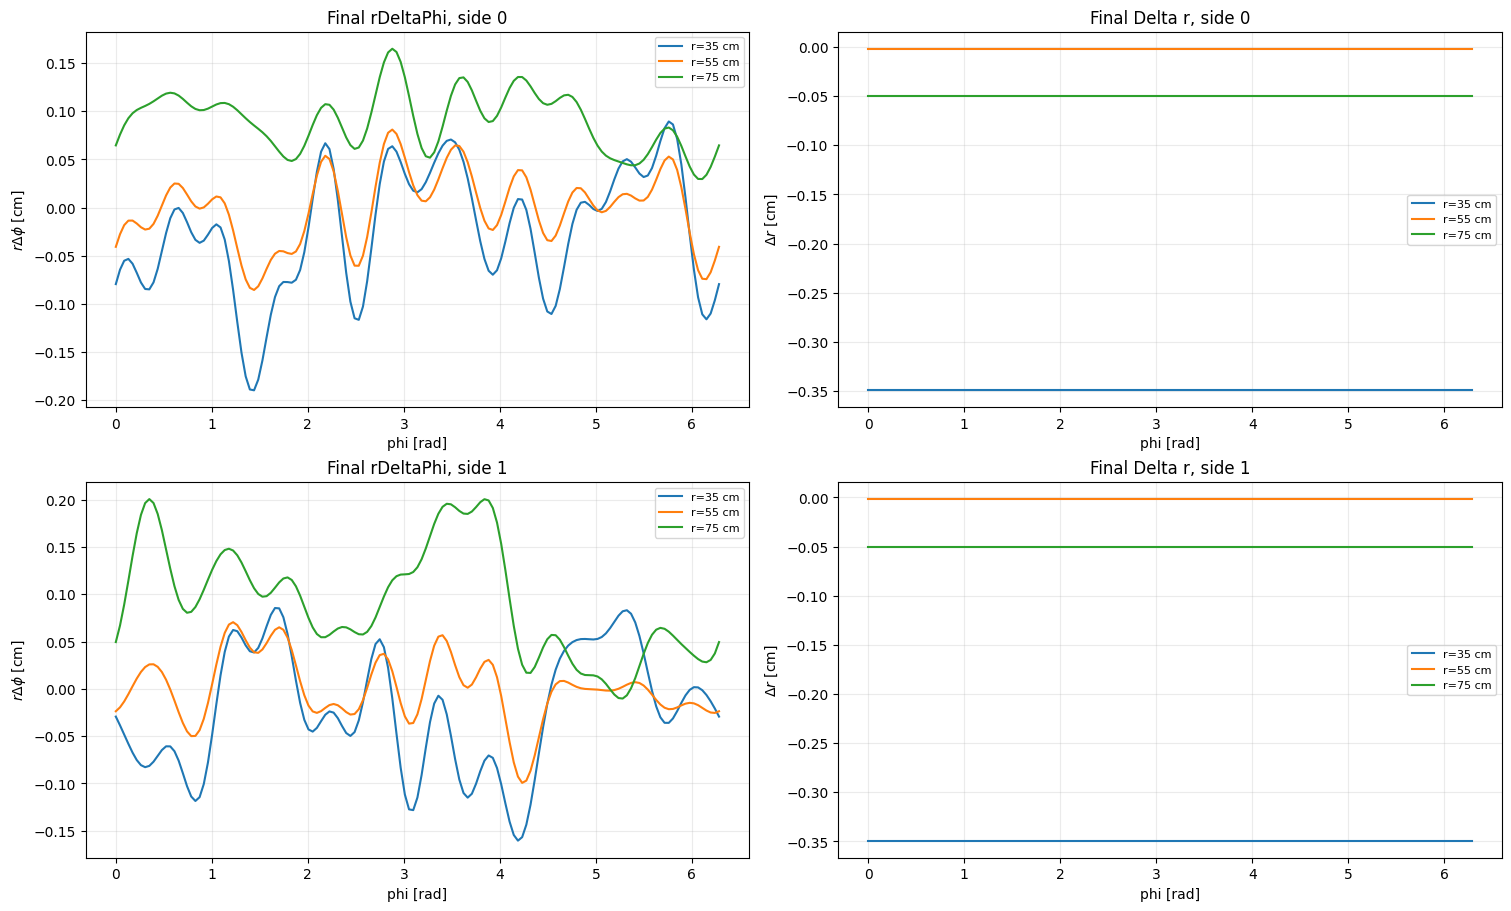

Welcome to JupyROOT 6.30/06
Wrote re-reco ROOT map: output/v0_spatial_calibration_v15_step1_step2b_short/v0_ml_transverse_distortion_map.root


In [27]:
# ============================================================
# Final combined transverse map and standard ROOT export for re-reconstruction
# ============================================================

def final_transverse_map_torch(r, phi, z, side):
    """Return final (Delta r [cm], rDeltaPhi [cm], Delta z [cm])."""
    with torch.no_grad():
        step1_delta_r = step1_model(r)
        step2a_fine_delta_r, step2a_r_delta_phi = step2_model(r, phi, z, side)
        step2b_extra_r_delta_phi = step2b_model(r, phi, z, side)
    total_delta_r = step1_delta_r + step2a_fine_delta_r
    total_r_delta_phi = step2a_r_delta_phi + step2b_extra_r_delta_phi
    return total_delta_r, total_r_delta_phi, torch.zeros_like(total_delta_r)


# Compact profile QA before writing the dense ROOT map.
profile_r = np.linspace(31.0, 76.0, 181).astype(np.float32)
profile_phi = np.linspace(0.0, 2.0 * np.pi, 145, endpoint=True).astype(np.float32)
profile_rows = []

step2b_model.eval()
with torch.no_grad():
    for side in [0, 1]:
        for z_value in ([-80.0, -50.0, -20.0] if side == 0 else [20.0, 50.0, 80.0]):
            for r_value in [35.0, 45.0, 55.0, 65.0, 75.0]:
                r = torch.full((len(profile_phi), 1), float(r_value), dtype=torch.float32)
                phi = torch.from_numpy(profile_phi[:, None])
                z = torch.full_like(r, float(z_value))
                side_tensor = torch.full((len(r),), side, dtype=torch.long)
                delta_r, r_delta_phi, _ = final_transverse_map_torch(r, phi, z, side_tensor)

                for pp, dr, rdphi in zip(profile_phi, delta_r[:, 0].numpy(), r_delta_phi[:, 0].numpy()):
                    profile_rows.append({
                        'side': side,
                        'z_cm': z_value,
                        'r_cm': r_value,
                        'phi': float(pp),
                        'delta_r_cm': float(dr),
                        'r_delta_phi_cm': float(rdphi),
                        'delta_phi_rad': float(rdphi / r_value),
                    })

final_map_profiles = pd.DataFrame(profile_rows)
final_map_profiles.to_csv(work_dir / 'v0_ml_transverse_distortion_map_profiles.csv', index=False)

fig, axes = plt.subplots(2, 2, figsize=(15, 9), constrained_layout=True)
for side in [0, 1]:
    frame = final_map_profiles[(final_map_profiles['side'] == side) & np.isclose(final_map_profiles['z_cm'], -50.0 if side == 0 else 50.0)]
    for r_value in [35.0, 55.0, 75.0]:
        selected = frame[np.isclose(frame['r_cm'], r_value)]
        axes[side, 0].plot(selected['phi'], selected['r_delta_phi_cm'], label=f'r={r_value:.0f} cm')
        axes[side, 1].plot(selected['phi'], selected['delta_r_cm'], label=f'r={r_value:.0f} cm')
    axes[side, 0].set_title(f'Final rDeltaPhi, side {side}')
    axes[side, 0].set_xlabel('phi [rad]')
    axes[side, 0].set_ylabel(r'$r\Delta\phi$ [cm]')
    axes[side, 1].set_title(f'Final Delta r, side {side}')
    axes[side, 1].set_xlabel('phi [rad]')
    axes[side, 1].set_ylabel(r'$\Delta r$ [cm]')
    for axis in axes[side]:
        axis.grid(alpha=0.25)
        axis.legend(fontsize=8)
plt.savefig(work_dir / 'v0_ml_transverse_distortion_map_profiles.pdf')
plt.show()


def write_rereco_root_map(output_path):
    try:
        import ROOT as root
    except ImportError as exc:
        print('PyROOT is unavailable; ROOT map was not written:', exc)
        return False

    root.gROOT.SetBatch(True)
    output_path = str(output_path)

    dphi = 2.0 * np.pi / rereco_map_phi_bins
    dr = (rereco_map_r_max_cm - rereco_map_r_min_cm) / rereco_map_r_bins
    dz = rereco_map_z_max_cm / rereco_map_z_bins_per_side

    nphi = rereco_map_phi_bins + 2
    nr = rereco_map_r_bins + 2
    nz = rereco_map_z_bins_per_side + 2
    phi_min, phi_max = -dphi, 2.0 * np.pi + dphi
    r_min, r_max = rereco_map_r_min_cm - dr, rereco_map_r_max_cm + dr

    output = root.TFile(output_path, 'RECREATE')
    if not output or output.IsZombie():
        raise OSError(f'Could not create ROOT map: {output_path}')

    histograms = {}
    for side, suffix in [(0, '_negz'), (1, '_posz')]:
        if side == 0:
            z_min, z_max = -rereco_map_z_max_cm - dz, dz
        else:
            z_min, z_max = -dz, rereco_map_z_max_cm + dz

        h_r = root.TH3F(
            f'hIntDistortionR{suffix}', f'hIntDistortionR{suffix};phi;r [cm];z [cm]',
            nphi, phi_min, phi_max, nr, r_min, r_max, nz, z_min, z_max,
        )
        h_p = root.TH3F(
            f'hIntDistortionP{suffix}', f'hIntDistortionP{suffix};phi;r [cm];z [cm]',
            nphi, phi_min, phi_max, nr, r_min, r_max, nz, z_min, z_max,
        )
        h_z = root.TH3F(
            f'hIntDistortionZ{suffix}', f'hIntDistortionZ{suffix};phi;r [cm];z [cm]',
            nphi, phi_min, phi_max, nr, r_min, r_max, nz, z_min, z_max,
        )
        h_entries = root.TH3I(
            f'hEntries{suffix}', f'hEntries{suffix};phi;r [cm];z [cm]',
            nphi, phi_min, phi_max, nr, r_min, r_max, nz, z_min, z_max,
        )

        # Fill one z slice at a time. Guard-bin centers are evaluated with phi wrapped
        # and r/z clamped to the physical map range, so TH3 interpolation is valid
        # all the way to the TPC boundaries.
        phi_centers = np.array([h_r.GetXaxis().GetBinCenter(i) for i in range(1, nphi + 1)], dtype=np.float32)
        r_centers = np.array([h_r.GetYaxis().GetBinCenter(i) for i in range(1, nr + 1)], dtype=np.float32)
        phi_mesh, r_mesh = np.meshgrid(phi_centers, r_centers, indexing='ij')
        phi_eval = np.mod(phi_mesh.reshape(-1), 2.0 * np.pi).astype(np.float32)
        r_eval = np.clip(r_mesh.reshape(-1), rereco_map_r_min_cm, rereco_map_r_max_cm).astype(np.float32)

        for iz in range(1, nz + 1):
            z_center = float(h_r.GetZaxis().GetBinCenter(iz))
            if side == 0:
                z_eval_value = float(np.clip(z_center, -rereco_map_z_max_cm, 0.0))
            else:
                z_eval_value = float(np.clip(z_center, 0.0, rereco_map_z_max_cm))

            r_tensor = torch.from_numpy(r_eval[:, None])
            phi_tensor = torch.from_numpy(phi_eval[:, None])
            z_tensor = torch.full_like(r_tensor, z_eval_value)
            side_tensor = torch.full((len(r_tensor),), side, dtype=torch.long)

            delta_r, r_delta_phi, _ = final_transverse_map_torch(r_tensor, phi_tensor, z_tensor, side_tensor)
            delta_r = delta_r[:, 0].detach().cpu().numpy()
            r_delta_phi = r_delta_phi[:, 0].detach().cpu().numpy()
            delta_phi = r_delta_phi / np.maximum(r_eval, 1.0e-6)

            index = 0
            for ix in range(1, nphi + 1):
                for iy in range(1, nr + 1):
                    h_r.SetBinContent(ix, iy, iz, float(delta_r[index]))
                    h_p.SetBinContent(ix, iy, iz, float(delta_phi[index]))
                    h_entries.SetBinContent(ix, iy, iz, 1)
                    index += 1

        histograms[side] = (h_r, h_p, h_z, h_entries)

    output.cd()
    for side in [0, 1]:
        for histogram in histograms[side]:
            histogram.Write()

    root.TNamed(
        'V0MLMapConvention',
        'corrected_r = measured_r - hR; corrected_phi = measured_phi - hP; hP stored in radians; Delta z = 0',
    ).Write()
    root.TNamed(
        'V0MLMapComposition',
        'Delta r = Step one + frozen Step-two-A radial fine; Delta phi = (Step-two-A rDeltaPhi + Step-two-B rDeltaPhi)/r',
    ).Write()
    output.Close()
    print('Wrote re-reco ROOT map:', output_path)
    return True


root_map_written = write_rereco_root_map(rereco_map_root_file) if export_rereco_root_map else False


In [28]:
# ============================================================
# ROOT-map interpolation sanity check and final checkpoint
# ============================================================

map_check = {'root_map_written': bool(root_map_written)}

if root_map_written:
    import ROOT as root

    check_file = root.TFile.Open(str(rereco_map_root_file), 'READ')
    rng = np.random.default_rng(seed + 9000)
    max_abs_dr_difference = 0.0
    max_abs_dphi_difference = 0.0

    for side, suffix in [(0, '_negz'), (1, '_posz')]:
        h_r = check_file.Get(f'hIntDistortionR{suffix}')
        h_p = check_file.Get(f'hIntDistortionP{suffix}')
        if not h_r or not h_p:
            raise RuntimeError(f'Missing required map histograms for side {side}')

        r_values = rng.uniform(31.0, 76.0, 100).astype(np.float32)
        phi_values = rng.uniform(0.05, 2.0 * np.pi - 0.05, 100).astype(np.float32)
        if side == 0:
            z_values = rng.uniform(-100.0, -5.0, 100).astype(np.float32)
        else:
            z_values = rng.uniform(5.0, 100.0, 100).astype(np.float32)

        r_tensor = torch.from_numpy(r_values[:, None])
        phi_tensor = torch.from_numpy(phi_values[:, None])
        z_tensor = torch.from_numpy(z_values[:, None])
        side_tensor = torch.full((len(r_values),), side, dtype=torch.long)
        delta_r, r_delta_phi, _ = final_transverse_map_torch(r_tensor, phi_tensor, z_tensor, side_tensor)
        delta_r = delta_r[:, 0].numpy()
        delta_phi = r_delta_phi[:, 0].numpy() / r_values

        for rr, pp, zz, dr_expected, dp_expected in zip(r_values, phi_values, z_values, delta_r, delta_phi):
            dr_map = h_r.Interpolate(float(pp), float(rr), float(zz))
            dp_map = h_p.Interpolate(float(pp), float(rr), float(zz))
            max_abs_dr_difference = max(max_abs_dr_difference, abs(dr_map - float(dr_expected)))
            max_abs_dphi_difference = max(max_abs_dphi_difference, abs(dp_map - float(dp_expected)))

    check_file.Close()
    map_check['max_abs_delta_r_interpolation_difference_cm'] = float(max_abs_dr_difference)
    map_check['max_abs_delta_phi_interpolation_difference_rad'] = float(max_abs_dphi_difference)

    print('ROOT map interpolation max |Delta r difference| [cm]:', max_abs_dr_difference)
    print('ROOT map interpolation max |Delta phi difference| [rad]:', max_abs_dphi_difference)

torch.save({
    'step1_state_dict': step1_model.state_dict(),
    'step2a_state_dict': step2_model.state_dict(),
    'step2b_state_dict': step2b_model.state_dict(),
    'step2a_basis_names': step2_rphi_basis_names,
    'step2b_basis_names': step2b_basis_names,
    'step2b_harmonic_orders': step2b_harmonic_orders,
    'map_convention': 'corrected_r = measured_r - Delta r; corrected_phi = measured_phi - DeltaPhi',
    'root_phi_hist_units': 'radians',
}, checkpoint_dir / 'step1_step2a_step2b_transverse_calibration.pt')

usable = step2b_mass_table['neff'] >= pt_mass_scale_minimum_effective_entries
summary_step2b = {
    'best_step2b_epoch': int(best_step2b_epoch),
    'best_step2b_validation_score': float(best_step2b_score),
    'mean_abs_mass_error_step2a_mev': float(np.nanmean(np.abs(step2b_mass_table.loc[usable, 'mean_error_step2a_mev']))),
    'mean_abs_mass_error_step2b_mev': float(np.nanmean(np.abs(step2b_mass_table.loc[usable, 'mean_error_step2b_mev']))),
    'mean_standard_width_ratio_step2b_over_step2a': float(np.nanmean(step2b_mass_table.loc[usable, 'width_ratio_step2b_over_step2a'])),
    'mean_robust_width_ratio_step2b_over_step2a': float(np.nanmean(step2b_mass_table.loc[usable, 'robust_width_ratio_step2b_over_step2a'])),
    'maximum_abs_step2b_rdelta_phi_cm_on_profile_grid': float(
        np.nanmax(np.abs(final_map_profiles['r_delta_phi_cm']))
    ),
    'root_map_file': str(rereco_map_root_file),
    'root_map_check': map_check,
    'step2b_coefficients_cm': step2b_model.coefficients().detach().cpu().numpy().tolist(),
}
with open(work_dir / 'step2b_summary.json', 'w') as output:
    json.dump(summary_step2b, output, indent=2)

print(json.dumps(summary_step2b, indent=2))
print('Final transverse map ready. Delta z remains exactly zero.')


ROOT map interpolation max |Delta r difference| [cm]: 0.00016465656895892078
ROOT map interpolation max |Delta phi difference| [rad]: 4.513219979911283e-05
{
  "best_step2b_epoch": 27,
  "best_step2b_validation_score": 9.886157035827637,
  "mean_abs_mass_error_step2a_mev": 0.13495211629139617,
  "mean_abs_mass_error_step2b_mev": 0.18097885777792108,
  "mean_standard_width_ratio_step2b_over_step2a": 0.9811366620343723,
  "mean_robust_width_ratio_step2b_over_step2a": 0.9881390052235868,
  "maximum_abs_step2b_rdelta_phi_cm_on_profile_grid": 0.23003855347633362,
  "root_map_file": "output/v0_spatial_calibration_v15_step1_step2b_short/v0_ml_transverse_distortion_map.root",
  "root_map_check": {
    "root_map_written": true,
    "max_abs_delta_r_interpolation_difference_cm": 0.00016465656895892078,
    "max_abs_delta_phi_interpolation_difference_rad": 4.513219979911283e-05
  },
  "step2b_coefficients_cm": [
    [
      -0.010510874912142754,
      -0.010558160953223705,
      -0.010719560086

## Re-reconstruction test

Primary output:

- `v0_ml_transverse_distortion_map.root`

It contains the standard distortion-map histogram names:

- `hIntDistortionR_negz`, `hIntDistortionR_posz`
- `hIntDistortionP_negz`, `hIntDistortionP_posz`
- `hIntDistortionZ_negz`, `hIntDistortionZ_posz`

The ROOT map is 3D with axes `(phi, r, z)`. The phi histograms store **Delta phi in radians**. The notebook convention is exactly

\[
r_{\rm corrected}=r-\Delta r,\qquad
\phi_{\rm corrected}=\phi-\Delta\phi,\qquad
z_{\rm corrected}=z.
\]

Use this file as an **additional/custom transverse TPC correction map** in the real re-reconstruction, then rerun the identical V0/cascade chain. Compare at minimum:

- K0S mass mean and width versus mother pT;
- Lambda and anti-Lambda masses;
- Xi/Omega mass and topology QA;
- daughter charge balance;
- track/circle residual QA.

The most important closure test is whether the real re-reconstruction reproduces the Step-one mass flattening and whether Step two B gives an actual K0S-width improvement outside the fast circle-response approximation.
